1. Check Duplicate Datetime Values  
2. Check missing Date-Time values → Check time difference
3. Boxplot
4. Lowest anomaly demand – 487 MW on 29-May-2003
5. Handling Lowest value – Clean dataset creation
6. Low Demand Analysis (<2890 MW)
7. High Demand Analysis
8. Upper bound capping decision – Why 9000 MW?
9. Autocorrelation Analysis → Lag 1, 24 and 16 hours
10. Yearly Analysis → 2013 vs 2014 → Check Trend and Seasonality
11. Business Hypothesis
    Population ↑ + Migration ↑ + Industrial Activity ↑ → Electricity Demand ↑
12. Seasonal, Monthly, Weekly & Hourly Analysis
13. Holiday Analysis
14. Rolling Mean And Rolling Standard Deviation → Check data is stationary
15. Overall Findings


In [2]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# LOAD DATASET

df = pd.read_excel("C:/Users/Admin/OneDrive/Documents/P705_Forecasting_Power_Supply_Demand/dataset/PJMW_MW_Hourly.xlsx")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [4]:
# CREATE RAW BACKUP

df_raw = df.copy()

print("Raw dataset backup created.")

Raw dataset backup created.


df_raw

In [6]:
# DATASET SHAPE

rows, columns = df.shape

print("Number of rows    :", rows)
print("Number of columns :", columns)

Number of rows    : 143206
Number of columns : 2


In [7]:
# DESCRIPTIVE STATISTICS

display(df["PJMW_MW"].describe())

count    143206.000000
mean       5602.375089
std         979.142872
min         487.000000
25%        4907.000000
50%        5530.000000
75%        6252.000000
max        9594.000000
Name: PJMW_MW, dtype: float64

### Dataset Information and Datype conversion 

In [9]:
# DATASET INFORMATION

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143206 entries, 0 to 143205
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  143206 non-null  datetime64[ns]
 1   PJMW_MW   143206 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.2 MB


In [10]:
# CONVERT DATETIME to datatype - Datetime

df["Datetime"] = pd.to_datetime(
    df["Datetime"],
    errors="coerce"
)

print(df.dtypes)

Datetime    datetime64[ns]
PJMW_MW              int64
dtype: object


errors="coerce" => it wil convert INVALID_DATE => Convert this to datetime, and if something cannot be converted, don't crash—turn it into NaT.

NaT means Not a Time, similar to how NaN represents a missing numerical value.

___

### CHECK DUPLICATE DATETIME VALUES

In [14]:
# CHECK DUPLICATE DATETIME VALUES

duplicate_datetime_count = df["Datetime"].duplicated().sum()

print("Duplicate timestamps:", duplicate_datetime_count)

Duplicate timestamps: 4


In [15]:
duplicate_datetime_rows = df[
    df["Datetime"].duplicated(keep=False)
].sort_values("Datetime")

display(duplicate_datetime_rows)

,Datetime,PJMW_MW
104424,2014-11-02 02:00:00,4613
104425,2014-11-02 02:00:00,4571
113208,2015-11-01 02:00:00,3927
113209,2015-11-01 02:00:00,3832
121848,2016-11-06 02:00:00,4114
121849,2016-11-06 02:00:00,4089
130656,2017-11-05 02:00:00,4042
130657,2017-11-05 02:00:00,3984


## Duplicate Timestamp Analysis

- These repeated timestamps occur around **U.S. Daylight Saving Time (DST) transitions**.
- During DST, the clock moves back by one hour, so a local time can occur twice.
- All identified duplicate timestamps occur in **November**, which is consistent with the U.S. transition from Daylight Saving Time back to standard time.


01:00 \
02:00 \
02:00  ← repeated local hour\
03:00


* These are **not exact duplicate rows** because the `PJMW_MW` values are different.
* Therefore, these rows should **not be blindly deleted**.

___

### SORT DATA CHRONOLOGICALLY

In [18]:
# SORT DATA CHRONOLOGICALLY

df = df.sort_values("Datetime").reset_index(drop=True)

print("Dataset sorted chronologically.")

Dataset sorted chronologically.


Before sorting 

Datetime	PJMW_MW\
2002-12-31 1:00:00	5077\
2002-12-31 2:00:00	4939\
2002-12-31 3:00:00	4885


After sorting start from 

2002-04-01 1:00:00	4374\
2002-04-01 2:00:00	4306\
2002-04-01 3:00:00	4322
____

### Check missing Date-Time values => Check time difference  

In [21]:
# CHECK TIME DIFFERENCES

df["Time_Difference"] = df["Datetime"].diff()

print(
    df["Time_Difference"]
    .value_counts()
    .head(20)
)

Time_Difference
0 days 01:00:00    143171
0 days 02:00:00        30
0 days 00:00:00         4
Name: count, dtype: int64


- 2 hours -> 30 such enteries 
- 0 hours → 4 => This means there are 4 cases where consecutive rows have exactly the same timestamp. DTS 

Identify places where time difference > 1 hr.

In [24]:
# Find rows where the gap is greater than 1 hour
gap_indices = df.index[
    df["Time_Difference"] > pd.Timedelta(hours=1)
]

# Display the row before and the row where the gap occurs
for idx in gap_indices:
    display(
        df.loc[
            max(0, idx - 1):idx,
            ["Datetime", "PJMW_MW", "Time_Difference"]
        ]
    )

,Datetime,PJMW_MW,Time_Difference
145,2002-04-07 02:00:00,4858,0 days 01:00:00
146,2002-04-07 04:00:00,4871,0 days 02:00:00


,Datetime,PJMW_MW,Time_Difference
5015,2002-10-27 01:00:00,4304,0 days 01:00:00
5016,2002-10-27 03:00:00,4014,0 days 02:00:00


,Datetime,PJMW_MW,Time_Difference
8879,2003-04-06 02:00:00,4365,0 days 01:00:00
8880,2003-04-06 04:00:00,4376,0 days 02:00:00


,Datetime,PJMW_MW,Time_Difference
13749,2003-10-26 01:00:00,4321,0 days 01:00:00
13750,2003-10-26 03:00:00,4027,0 days 02:00:00


,Datetime,PJMW_MW,Time_Difference
17613,2004-04-04 02:00:00,4724,0 days 01:00:00
17614,2004-04-04 04:00:00,4691,0 days 02:00:00


...

,Datetime,PJMW_MW,Time_Difference
104616,2014-03-09 02:00:00,4812,0 days 01:00:00
104617,2014-03-09 04:00:00,4840,0 days 02:00:00


,Datetime,PJMW_MW,Time_Difference
113352,2015-03-08 02:00:00,5412,0 days 01:00:00
113353,2015-03-08 04:00:00,5365,0 days 02:00:00


,Datetime,PJMW_MW,Time_Difference
122256,2016-03-13 02:00:00,3900,0 days 01:00:00
122257,2016-03-13 04:00:00,3790,0 days 02:00:00


,Datetime,PJMW_MW,Time_Difference
130992,2017-03-12 02:00:00,5913,0 days 01:00:00
130993,2017-03-12 04:00:00,5904,0 days 02:00:00


,Datetime,PJMW_MW,Time_Difference
139728,2018-03-11 02:00:00,5533,0 days 01:00:00
139729,2018-03-11 04:00:00,5610,0 days 02:00:00


### Analysis of 2-Hour Time Gaps

- A total of **30 intervals with a 2-hour difference** were identified in the dataset.

- The 2-hour gaps occur consistently around dates such as:
  - March 2007–2018
  - October/November 2002–2013
  - November 2014–2017

- These dates correspond to the **U.S. Daylight Saving Time (DST) transitions**.

- During the **spring DST transition**, the clock moves forward by one hour. Therefore, one local hour is skipped, resulting in a **2-hour difference** between consecutive recorded timestamps.

- During the **autumn DST transition**, the clock moves backward by one hour. This can also affect the recorded local-time sequence.

- The repeated pattern across multiple years indicates that these gaps are **systematic and related to DST**, rather than random missing data.


- There is **one unusual 2-hour gap on `2010-12-10 01:00:00`**, which does not fall around the usual DST transition period. This should be treated separately.

**Not taking any action for this**

### Insert the missing for for the 10-Dec-2010 12 am 

In [27]:
missing_time = pd.Timestamp("2010-12-10 00:00:00")

# Insert the missing timestamp
df.loc[len(df), "Datetime"] = missing_time

# Sort again
df = df.sort_values("Datetime").reset_index(drop=True)

Interpolate the missing demand value

Because 00:00 is between:

23:00 → 6972 MW \
01:00 → 6280 MW

linear interpolation gives:


(6972+6280)/2  = 6626 MW

In [30]:
df["PJMW_MW"] = df["PJMW_MW"].interpolate(method="linear")

Verify using .loc

In [32]:
df.loc[
    df["Datetime"] == "2010-12-10 00:00:00"
]

,Datetime,PJMW_MW,Time_Difference
76181,2010-12-10,6626.0,NaT


Verify the surrounding timestamps

In [34]:
df.loc[
    (df["Datetime"] >= "2010-12-09 22:00:00") &
    (df["Datetime"] <= "2010-12-10 02:00:00"),
    ["Datetime", "PJMW_MW"]
]

,Datetime,PJMW_MW
76179,2010-12-09 22:00:00,7354.0
76180,2010-12-09 23:00:00,6972.0
76181,2010-12-10 00:00:00,6626.0
76182,2010-12-10 01:00:00,6280.0
76183,2010-12-10 02:00:00,6117.0


In [35]:
df.shape

(143207, 3)

___

## Demand Distribution

Skewness of Power Demand:  0.3348366998807953
Kurtosis of Power Demand:  -0.22148039243145767


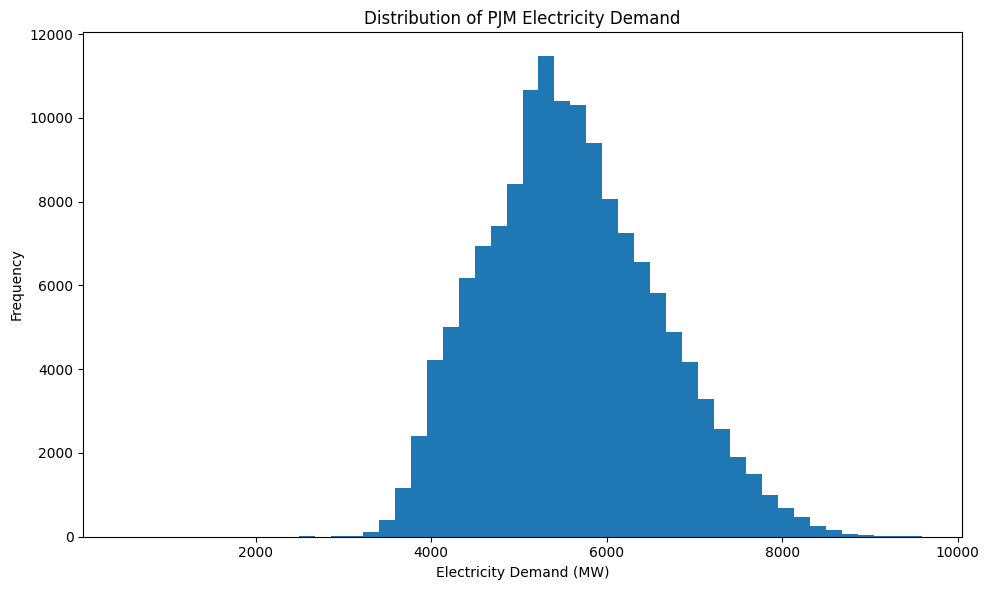

In [38]:
# DEMAND DISTRIBUTION

print('Skewness of Power Demand: ', df["PJMW_MW"].skew())
print('Kurtosis of Power Demand: ', df["PJMW_MW"].kurt())

plt.figure(figsize=(10, 6))

plt.hist(
    df["PJMW_MW"],
    bins=50
)

plt.title(
    "Distribution of PJM Electricity Demand"
)

plt.xlabel("Electricity Demand (MW)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

#### Observation - 
-0.2215 means your PJMW_MW distribution is slightly platykurtic compared with a normal distribution.


The PJMW_MW variable has an excess kurtosis of -0.221, indicating a slightly platykurtic distribution. This suggests that the distribution has somewhat lighter tails and fewer extreme observations compared with a normal distribution. However, the value is close to zero, so the deviation from a normal distribution is relatively small.


Overall => 

**Relatively close to a symmetric/normal-like distribution, but not exactly normal**

____

### CREATE TIME FEATURES

In [42]:
# CREATE TIME FEATURES

df["Year"] = df["Datetime"].dt.year
df["Month"] = df["Datetime"].dt.month
df["Month_Name"] = df["Datetime"].dt.month_name()

df["Day"] = df["Datetime"].dt.day
df["DayOfWeek"] = df["Datetime"].dt.dayofweek
df["Day_Name"] = df["Datetime"].dt.day_name()

df["Hour"] = df["Datetime"].dt.hour

df["WeekOfYear"] = df["Datetime"].dt.isocalendar().week
df["Quarter"] = df["Datetime"].dt.quarter

df["DayOfYear"] = df["Datetime"].dt.dayofyear

_____

## Boxplot

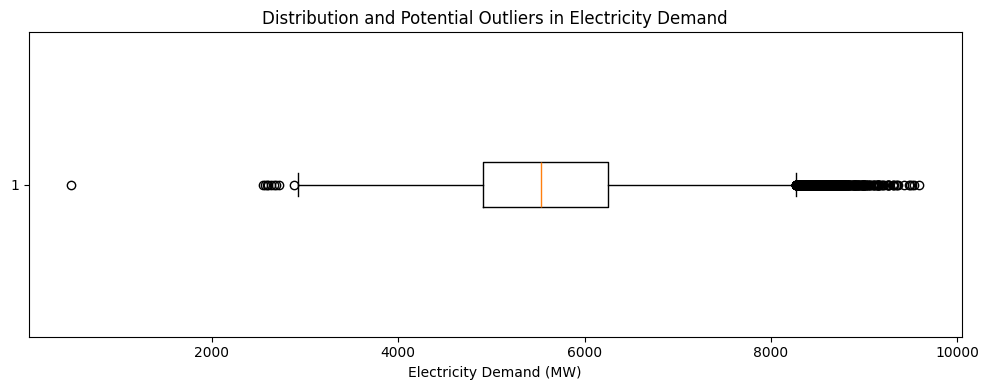

In [45]:
# BOXPLOT OF DEMAND

plt.figure(figsize=(10, 4))

plt.boxplot(
    df["PJMW_MW"],
    vert=False
)

plt.title(
    "Distribution and Potential Outliers in Electricity Demand"
)

plt.xlabel("Electricity Demand (MW)")

plt.tight_layout()
plt.show()

### INVESTIGATE VERY LOWEST DEMAND VALUE

In [47]:
# INVESTIGATE VERY LOW DEMAND VALUES

very_low = df[
    df["PJMW_MW"] < 1000
].sort_values("PJMW_MW")

print("Observations below 1000 MW:")
display(very_low)

Observations below 1000 MW:


,Datetime,PJMW_MW,Time_Difference,Year,Month,Month_Name,Day,DayOfWeek,Day_Name,Hour,WeekOfYear,Quarter,DayOfYear
10148,2003-05-29,487.0,0 days 01:00:00,2003,5,May,29,3,Thursday,0,22,2,149


### Create cleaned demand column

For the specific 487 MW point, after inspecting the neighboring values, we can create a cleaned version.

In [49]:
# ============================================================
# 24. INVESTIGATE SUSPICIOUS OBSERVATION - finding out 3 values above & below 
# ============================================================

suspicious_index = df["PJMW_MW"].idxmin()

display(
    df.loc[
        suspicious_index - 3:
        suspicious_index + 3
    ]
)

,Datetime,PJMW_MW,Time_Difference,Year,Month,Month_Name,Day,DayOfWeek,Day_Name,Hour,WeekOfYear,Quarter,DayOfYear
10145,2003-05-28 21:00:00,5631.0,0 days 01:00:00,2003,5,May,28,2,Wednesday,21,22,2,148
10146,2003-05-28 22:00:00,5746.0,0 days 01:00:00,2003,5,May,28,2,Wednesday,22,22,2,148
10147,2003-05-28 23:00:00,5317.0,0 days 01:00:00,2003,5,May,28,2,Wednesday,23,22,2,148
10148,2003-05-29 00:00:00,487.0,0 days 01:00:00,2003,5,May,29,3,Thursday,0,22,2,149
10149,2003-05-29 01:00:00,4560.0,0 days 01:00:00,2003,5,May,29,3,Thursday,1,22,2,149
10150,2003-05-29 02:00:00,4424.0,0 days 01:00:00,2003,5,May,29,3,Thursday,2,22,2,149
10151,2003-05-29 03:00:00,4351.0,0 days 01:00:00,2003,5,May,29,3,Thursday,3,22,2,149


**Interplotaion** 

### Calculation

2003-05-29 00:00:00\
Original PJMW_MW       = 487 MW \
Interpolated Clean     = (5317+4560)/2 = 4938.5 MW

### Why is it the average?

Because the missing point is exactly **one hour between** the two known observations:

```text
23:00             00:00              01:00
5317 MW             ?                 4560 MW
   └────────────────┴──────────────────┘
          equal 1-hour intervals

In [51]:
# CREATE CLEANED DEMAND COLUMN

df["PJMW_MW_Clean"] = df["PJMW_MW"]

# Replace the identified suspicious observation
# with NaN first
df.loc[
    df["PJMW_MW"] < 1000,
    "PJMW_MW_Clean"
] = np.nan

In [52]:
# INTERPOLATE FLAGGED VALUE

df["PJMW_MW_Clean"] = (
    df["PJMW_MW_Clean"]
    .interpolate(method="linear")
)

In [53]:
# FLAG EXTREME OBSERVATIONS -> Consumption < 1000 MW

df["Possible_Anomaly"] = False

df.loc[
    df["PJMW_MW"] < 1000,
    "Possible_Anomaly"
] = True

display(
    df[df["Possible_Anomaly"]]
)

,Datetime,PJMW_MW,Time_Difference,Year,Month,Month_Name,Day,DayOfWeek,Day_Name,Hour,WeekOfYear,Quarter,DayOfYear,PJMW_MW_Clean,Possible_Anomaly
10148,2003-05-29,487.0,0 days 01:00:00,2003,5,May,29,3,Thursday,0,22,2,149,4938.5,True


In [54]:
# COMPARE ORIGINAL AND CLEANED VALUES

comparison = df[
    df["Possible_Anomaly"]
][
    [
        "Datetime",
        "PJMW_MW",
        "PJMW_MW_Clean"
    ]
]

display(comparison)

,Datetime,PJMW_MW,PJMW_MW_Clean
10148,2003-05-29,487.0,4938.5


In [55]:
# Calculate Q1, Q3 and IQR
Q1 = df["PJMW_MW_Clean"].quantile(0.25)
Q3 = df["PJMW_MW_Clean"].quantile(0.75)

IQR = Q3 - Q1

# Calculate lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find potential outliers
outliers = df[
    (df["PJMW_MW_Clean"] < lower_bound) | 
    (df["PJMW_MW_Clean"] > upper_bound)
]

# Print results
print("Q1:", Q1)
print("Median:", df["PJMW_MW_Clean"].median())
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Potential Outliers:", len(outliers))

Q1: 4907.0
Median: 5530.0
Q3: 6252.0
IQR: 1345.0
Lower Bound: 2889.5
Upper Bound: 8269.5
Number of Potential Outliers: 702


#### Low Demand Analysis (<2890 MW)

In [57]:
### Low Demand Analysis (<2890 MW)

low_demand = (
    df[df["PJMW_MW"] < 2890]
    .sort_values("PJMW_MW", ascending=False)
)

print("Number of observations below 2890 MW:", len(low_demand))

display(low_demand)

Number of observations below 2890 MW: 10


,Datetime,PJMW_MW,Time_Difference,Year,Month,Month_Name,Day,DayOfWeek,Day_Name,Hour,WeekOfYear,Quarter,DayOfYear,PJMW_MW_Clean,Possible_Anomaly
87663,2012-04-01 13:00:00,2878.0,0 days 01:00:00,2012,4,April,1,6,Sunday,13,13,2,92,2878.0,False
87664,2012-04-01 14:00:00,2721.0,0 days 01:00:00,2012,4,April,1,6,Sunday,14,13,2,92,2721.0,False
87673,2012-04-01 23:00:00,2690.0,0 days 01:00:00,2012,4,April,1,6,Sunday,23,13,2,92,2690.0,False
87665,2012-04-01 15:00:00,2663.0,0 days 01:00:00,2012,4,April,1,6,Sunday,15,13,2,92,2663.0,False
87669,2012-04-01 19:00:00,2630.0,0 days 01:00:00,2012,4,April,1,6,Sunday,19,13,2,92,2630.0,False
87668,2012-04-01 18:00:00,2600.0,0 days 01:00:00,2012,4,April,1,6,Sunday,18,13,2,92,2600.0,False
87667,2012-04-01 17:00:00,2586.0,0 days 01:00:00,2012,4,April,1,6,Sunday,17,13,2,92,2586.0,False
87666,2012-04-01 16:00:00,2574.0,0 days 01:00:00,2012,4,April,1,6,Sunday,16,13,2,92,2574.0,False
87674,2012-04-02 00:00:00,2553.0,0 days 01:00:00,2012,4,April,2,0,Monday,0,14,2,93,2553.0,False
10148,2003-05-29 00:00:00,487.0,0 days 01:00:00,2003,5,May,29,3,Thursday,0,22,2,149,4938.5,True


#### Low Demand Analysis (<2890 MW) Observation 

- There are **10 observations** 
- **9 observations** occur during **April 1–2, 2012**, mainly on **Sunday, April 1**.
- The low-demand values occur across several consecutive hours, indicating a **sustained low-demand period** rather than isolated abnormal values.
- The lowest value in this period is **2553 MW** at **April 2, 2012 00:00**.
- Most of these observations occur during the **weekend**, which may be associated with lower electricity demand.
- Therefore, low-demand observations should **not automatically be removed**; the April 2012 period may represent genuine low demand

In [59]:
# ============================================================
# LOWER-TAIL THRESHOLD ANALYSIS
# ============================================================

lower_thresholds = [2500, 2750, 2890, 3000, 3250, 3500]

for threshold in lower_thresholds:
    count = (
        (df["PJMW_MW"] >= 1000) &
        (df["PJMW_MW"] < threshold)
    ).sum()

    percentage = count / len(df) * 100

    print(
        f"Threshold: {threshold} MW | "
        f"Observations affected: {count} | "
        f"Percentage: {percentage:.4f}%"
    )

Threshold: 2500 MW | Observations affected: 0 | Percentage: 0.0000%
Threshold: 2750 MW | Observations affected: 8 | Percentage: 0.0056%
Threshold: 2890 MW | Observations affected: 9 | Percentage: 0.0063%
Threshold: 3000 MW | Observations affected: 15 | Percentage: 0.0105%
Threshold: 3250 MW | Observations affected: 28 | Percentage: 0.0196%
Threshold: 3500 MW | Observations affected: 250 | Percentage: 0.1746%


In [60]:
# # ============================================================
# # LOWER-TAIL OBSERVATIONS AFTER EXCLUDING 487 MW
# # ============================================================

# lower_tail = (
#     df[
#         (df["PJMW_MW"] >= 1000) &
#         (df["PJMW_MW"] < 3300)
#     ]
#     .sort_values("PJMW_MW")
# )

# display(
#     lower_tail[
#         [
#             "Datetime",
#             "PJMW_MW",
#             "PJMW_MW_Clean",
#             "Day_Name",
#             "Hour",
#             "Season",
#             "Is_Holiday"
#         ]
#     ]
# )

## Lower-Tail Capping Summary

* **IQR Lower Bound:** 2,889.5 MW → rounded to **2,890 MW**.

* **487 MW anomaly:**

  * Treated separately as an extreme anomaly.
  * Replaced with `NaN` and linearly interpolated.
  * Interpolated value = **4,938.5 MW**.
  * Therefore, it is **excluded from lower-tail capping**.

* **Observations below 2,890 MW:**

  * Total = **10 observations** initially.
  * After excluding 487 MW → **9 observations** remain.
  * Values range from **2,553 to 2,878 MW**.

* **Threshold sensitivity:**

  * 2,750 MW → 8 observations
  * **2,890 MW → 9 observations**
  * 3,000 MW → 15 observations
  * 3,250 MW → 28 observations
  * 3,500 MW → 250 observations

* The nine observations are concentrated around **April 1–2, 2012**, mainly on Sunday, suggesting a coherent low-demand period rather than random errors.

* **Decision:** Use **2,890 MW as the lower cap** because it is the IQR-derived boundary and affects only 9 observations after the separate treatment of the 487 MW anomaly.

* **Final cleaning:** Cap those **9 observations at 2,890 MW**, while keeping index **10148 = 4,938.5 MW**.


### Capping the Lower bound values 

In [63]:
# # ============================================================
# # CAP LOWER-BOUND OBSERVATIONS EXCLUDING THE ALREADY-CLEANED 487 MW
# # ============================================================

# LOWER_CAP = 2890

# # Identify observations that are below the lower cap
# # using the ORIGINAL PJMW_MW column, but exclude the
# # already-cleaned 487 MW observation (< 1000 MW).
# lower_outliers_to_cap = (
#     (df["PJMW_MW"] >= 1000) &
#     (df["PJMW_MW"] < LOWER_CAP)
# )

# # Create the final cleaned demand column
# df["PJMW_MW_Clean"] = df["PJMW_MW_Clean"]

# # Cap only the remaining 9 lower-bound observations
# df.loc[
#     lower_outliers_to_cap,
#     "PJMW_MW_Clean"
# ] = LOWER_CAP


# # ============================================================
# # VERIFICATION
# # ============================================================

# # Show all original observations below 2890 MW
# verification = df.loc[
#     df["PJMW_MW"] < LOWER_CAP,
#     [
#         "Datetime",
#         "PJMW_MW",
#         "PJMW_MW_Clean",
#         "Possible_Anomaly"
#     ]
# ].copy()

# display(verification)

# print(
#     "Number of observations capped:",
#     lower_outliers_to_cap.sum()
# )

# print(
#     "Value at index 10148:",
#     df.loc[10148, "PJMW_MW_Clean"]
# )

# print(
#     "Original value at index 10148:",
#     df.loc[10148, "PJMW_MW"]
# )

In [64]:
df.loc[10148, ["PJMW_MW", "PJMW_MW_Clean", "Possible_Anomaly"]]

PJMW_MW              487.0
PJMW_MW_Clean       4938.5
Possible_Anomaly      True
Name: 10148, dtype: object

#### High Demand Analysis

In [66]:
high_demand = (
    df[df["PJMW_MW"] > 8270]
    .sort_values("PJMW_MW", ascending=False)
)

print("Number of observations above 8270 MW:", len(high_demand))

# display(high_demand)

Number of observations above 8270 MW: 690


In [67]:
# ============================================================
# OUTLIER FREQUENCY ANALYSIS BY YEAR AND VALUE
# ============================================================

# Upper IQR outliers only
upper_outliers = df[
    df["PJMW_MW_Clean"] > upper_bound
].copy()

# Extract year
upper_outliers["Year"] = upper_outliers["Datetime"].dt.year


# ------------------------------------------------------------
# Count each distinct outlier value within each year
# ------------------------------------------------------------

outlier_value_year_table = (
    upper_outliers
    .groupby(["Year", "PJMW_MW_Clean"])
    .size()
    .reset_index(name="Count")
    .sort_values(["Year", "PJMW_MW_Clean"])
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Total number of upper-IQR outliers in each year
# ------------------------------------------------------------

year_totals = (
    upper_outliers
    .groupby("Year")
    .size()
    .rename("Total_Upper_Outliers_In_Year")
)


# ------------------------------------------------------------
# Add yearly total to the table
# ------------------------------------------------------------

outlier_value_year_table = outlier_value_year_table.merge(
    year_totals,
    on="Year",
    how="left"
)


# Rename column
outlier_value_year_table = outlier_value_year_table.rename(
    columns={
        "PJMW_MW_Clean": "Outlier_Value_MW"
    }
)


# Display
display(outlier_value_year_table)

,Year,Outlier_Value_MW,Count,Total_Upper_Outliers_In_Year
0,2002,8270.0,1,2
1,2002,8300.0,1,2
2,2003,8296.0,1,4
3,2003,8333.0,1,4
4,2003,8431.0,1,4
...,...,...,...,...
636,2018,9252.0,1,107
637,2018,9265.0,1,107
638,2018,9310.0,1,107
639,2018,9325.0,1,107


In [68]:
# YEAR-WISE OUTLIER SUMMARY

# Upper IQR outliers only
upper_outliers = df[
    df["PJMW_MW_Clean"] > upper_bound
].copy()

year_outlier_summary = (
    upper_outliers
    .groupby("Year")
    .agg(
        Upper_Outlier_Count=("PJMW_MW_Clean", "size"),
        Lowest_Upper_Outlier=("PJMW_MW_Clean", "min"),
        Highest_Upper_Outlier=("PJMW_MW_Clean", "max"),
        Distinct_Outlier_Values=("PJMW_MW_Clean", "nunique")
    )
    .reset_index()
)

display(year_outlier_summary)

,Year,Upper_Outlier_Count,Lowest_Upper_Outlier,Highest_Upper_Outlier,Distinct_Outlier_Values
0,2002,2,8270.0,8300.0,2
1,2003,4,8296.0,8437.0,4
2,2004,9,8289.0,8598.0,9
3,2005,111,8274.0,8823.0,93
4,2006,33,8285.0,8734.0,32
5,2007,23,8273.0,8664.0,22
6,2008,5,8276.0,8426.0,5
7,2009,12,8272.0,8541.0,11
8,2010,29,8270.0,8620.0,28
9,2011,29,8282.0,8998.0,29


In [69]:
# Compare different candidate upper limits

thresholds = [8500, 8750, 9000, 9250, 9500]

for threshold in thresholds:
    count = (df["PJMW_MW_Clean"] > threshold).sum()
    percentage = count / len(df) * 100

    print(
        f"Threshold: {threshold} MW | "
        f"Observations affected: {count} | "
        f"Percentage: {percentage:.4f}%"
    )

Threshold: 8500 MW | Observations affected: 330 | Percentage: 0.2304%
Threshold: 8750 MW | Observations affected: 129 | Percentage: 0.0901%
Threshold: 9000 MW | Observations affected: 50 | Percentage: 0.0349%
Threshold: 9250 MW | Observations affected: 17 | Percentage: 0.0119%
Threshold: 9500 MW | Observations affected: 3 | Percentage: 0.0021%


## Final Upper bound capping decision 

- 1 — Statistical outlier = 8269.5 MW => This is your IQR threshold.

- 2 — Extreme but potentially genuine demand

Approximately:

8,500–9,000 MW

- Level 3 — Extreme tail

Approximately:

9,000+ MW

There are **only 50 observations above 9,000 MW**, compared with 693 upper-IQR observations.

In [71]:
# Insteresting finding about >9000 MW
high_demand = (
    df[df["PJMW_MW"] > 9000]
    .sort_values("PJMW_MW", ascending=False)
)

print("Number of observations above 9000 MW:", len(high_demand))

# display(high_demand)

Number of observations above 9000 MW: 50


#### Interesting finding about >9000 MW Observation 

- These high-demand observations are concentrated mainly in **January and February**, and all belong to the **Winter** season.
- Several high-demand observations occur consecutively, especially during **19–20 February 2015**, suggesting sustained periods of high electricity demand rather than isolated abnormal values.
- Many high-demand observations occur during **morning and evening hours**, particularly around **7–10 AM and 6–10 PM**.
- **Conlusion** These observations are better considered **extreme/high-demand periods** and should be retained for forecasting analysis.

# Upper-Outliars capping

In [74]:
# # ============================================================
# # FINAL UPPER-TAIL CAPPING
# # ============================================================

# UPPER_CAP = 9000

# # Check number of observations above the cap before capping
# print(
#     "Number of observations above 9000 MW before capping:",
#     (df["PJMW_MW_Clean"] > UPPER_CAP).sum()
# )

# # Apply upper cap directly to PJMW_MW_Clean
# df["PJMW_MW_Clean"] = df["PJMW_MW_Clean"].clip(
#     upper=UPPER_CAP
# )

# # ============================================================
# # VERIFICATION
# # ============================================================

# print("Maximum after capping:",
#       df["PJMW_MW_Clean"].max())

# print(
#     "Number of observations above 9000 MW after capping:",
#     (df["PJMW_MW_Clean"] > UPPER_CAP).sum()
# )

# print(
#     "Number of observations capped at 9000 MW:",
#     (df["PJMW_MW_Clean"] == UPPER_CAP).sum()
# )

In [75]:
# Just to verify capping is not done 

print("Original observations exactly equal to 9000:",
      (df["PJMW_MW_Clean"] == 9000).sum())

print("Original observations above 9000:",
      (df["PJMW_MW_Clean"] > 9000).sum())

Original observations exactly equal to 9000: 1
Original observations above 9000: 50


| Treatment               | Initial modeling dataset                                  |
| ----------------------- | --------------------------------------------------------- |
| 487 MW                  | **Interpolated**                                          |
| 9 April 2012 low values | **Retained**                                              |
| >8270 MW                | **Retained**                                              |
| >9000 MW                | **Retained**                                              |
| IQR threshold 8269.5    | **Used for investigation, not automatic capping**         |
| 9000 MW                 | **Candidate robustness threshold, not applied initially** |


### Create the separate capped column

In [78]:
# ============================================================
# CREATE OPTIONAL CAPPED DEMAND COLUMN
# ============================================================

LOWER_CAP = 2890
UPPER_CAP = 9000

# Start from the current cleaned demand
df["PJMW_MW_Capped"] = df["PJMW_MW_Clean"]

# Apply lower cap
df["PJMW_MW_Capped"] = df["PJMW_MW_Capped"].clip(
    lower=LOWER_CAP
)

# Apply upper cap
df["PJMW_MW_Capped"] = df["PJMW_MW_Capped"].clip(
    upper=UPPER_CAP
)

Verify Capped column details 

In [80]:
# ============================================================
# VERIFY CAPPED COLUMN
# ============================================================

print("Original/Cleaned minimum:",
      df["PJMW_MW_Clean"].min())

print("Capped minimum:",
      df["PJMW_MW_Capped"].min())

print("Original/Cleaned maximum:",
      df["PJMW_MW_Clean"].max())

print("Capped maximum:",
      df["PJMW_MW_Capped"].max())

print(
    "Values below lower cap in capped data:",
    (df["PJMW_MW_Capped"] < LOWER_CAP).sum()
)

print(
    "Values above upper cap in capped data:",
    (df["PJMW_MW_Capped"] > UPPER_CAP).sum()
)

Original/Cleaned minimum: 2553.0
Capped minimum: 2890.0
Original/Cleaned maximum: 9594.0
Capped maximum: 9000.0
Values below lower cap in capped data: 0
Values above upper cap in capped data: 0


### IDENTIFY OBSERVATIONS AFFECTED BY CAPPING

In [82]:
# ============================================================
# IDENTIFY OBSERVATIONS AFFECTED BY CAPPING
# ============================================================

capped_observations = df[
    df["PJMW_MW_Clean"] != df["PJMW_MW_Capped"]
][
    [
        "Datetime",
        "PJMW_MW",
        "PJMW_MW_Clean",
        "PJMW_MW_Capped"
    ]
].copy()

print(
    "Total observations affected by capping:",
    len(capped_observations)
)

display(capped_observations)

Total observations affected by capping: 59


,Datetime,PJMW_MW,PJMW_MW_Clean,PJMW_MW_Capped
87663,2012-04-01 13:00:00,2878.0,2878.0,2890.0
87664,2012-04-01 14:00:00,2721.0,2721.0,2890.0
87665,2012-04-01 15:00:00,2663.0,2663.0,2890.0
87666,2012-04-01 16:00:00,2574.0,2574.0,2890.0
87667,2012-04-01 17:00:00,2586.0,2586.0,2890.0
87668,2012-04-01 18:00:00,2600.0,2600.0,2890.0
87669,2012-04-01 19:00:00,2630.0,2630.0,2890.0
87673,2012-04-01 23:00:00,2690.0,2690.0,2890.0
87674,2012-04-02 00:00:00,2553.0,2553.0,2890.0
103159,2014-01-07 08:00:00,9218.0,9218.0,9000.0


____

### Creating all time features 

In [85]:
# # CREATE TIME FEATURES

# df["Year"] = df["Datetime"].dt.year
# df["Month"] = df["Datetime"].dt.month
# df["Month_Name"] = df["Datetime"].dt.month_name()

# df["Day"] = df["Datetime"].dt.day
# df["DayOfWeek"] = df["Datetime"].dt.dayofweek
# df["Day_Name"] = df["Datetime"].dt.day_name()

# df["Hour"] = df["Datetime"].dt.hour

# df["WeekOfYear"] = df["Datetime"].dt.isocalendar().week
# df["Quarter"] = df["Datetime"].dt.quarter

# df["DayOfYear"] = df["Datetime"].dt.dayofyear

In [86]:
# Detailed data set 
df

,Datetime,PJMW_MW,Time_Difference,Year,Month,Month_Name,Day,DayOfWeek,Day_Name,Hour,WeekOfYear,Quarter,DayOfYear,PJMW_MW_Clean,Possible_Anomaly,PJMW_MW_Capped
0,2002-04-01 01:00:00,4374.0,NaT,2002,4,April,1,0,Monday,1,14,2,91,4374.0,False,4374.0
1,2002-04-01 02:00:00,4306.0,0 days 01:00:00,2002,4,April,1,0,Monday,2,14,2,91,4306.0,False,4306.0
2,2002-04-01 03:00:00,4322.0,0 days 01:00:00,2002,4,April,1,0,Monday,3,14,2,91,4322.0,False,4322.0
3,2002-04-01 04:00:00,4359.0,0 days 01:00:00,2002,4,April,1,0,Monday,4,14,2,91,4359.0,False,4359.0
4,2002-04-01 05:00:00,4436.0,0 days 01:00:00,2002,4,April,1,0,Monday,5,14,2,91,4436.0,False,4436.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143202,2018-08-02 20:00:00,6545.0,0 days 01:00:00,2018,8,August,2,3,Thursday,20,31,3,214,6545.0,False,6545.0
143203,2018-08-02 21:00:00,6496.0,0 days 01:00:00,2018,8,August,2,3,Thursday,21,31,3,214,6496.0,False,6496.0
143204,2018-08-02 22:00:00,6325.0,0 days 01:00:00,2018,8,August,2,3,Thursday,22,31,3,214,6325.0,False,6325.0
143205,2018-08-02 23:00:00,5892.0,0 days 01:00:00,2018,8,August,2,3,Thursday,23,31,3,214,5892.0,False,5892.0


In [87]:
df.shape

(143207, 16)

____

# Scaling the data 

In [90]:
# from sklearn.preprocessing import MinMaxScaler

# scaler = MinMaxScaler()

# df["PJMW_MW_Scaled"] = scaler.fit_transform(
#     df[["PJMW_MW_Clean"]]
# )

In [91]:
df

,Datetime,PJMW_MW,Time_Difference,Year,Month,Month_Name,Day,DayOfWeek,Day_Name,Hour,WeekOfYear,Quarter,DayOfYear,PJMW_MW_Clean,Possible_Anomaly,PJMW_MW_Capped
0,2002-04-01 01:00:00,4374.0,NaT,2002,4,April,1,0,Monday,1,14,2,91,4374.0,False,4374.0
1,2002-04-01 02:00:00,4306.0,0 days 01:00:00,2002,4,April,1,0,Monday,2,14,2,91,4306.0,False,4306.0
2,2002-04-01 03:00:00,4322.0,0 days 01:00:00,2002,4,April,1,0,Monday,3,14,2,91,4322.0,False,4322.0
3,2002-04-01 04:00:00,4359.0,0 days 01:00:00,2002,4,April,1,0,Monday,4,14,2,91,4359.0,False,4359.0
4,2002-04-01 05:00:00,4436.0,0 days 01:00:00,2002,4,April,1,0,Monday,5,14,2,91,4436.0,False,4436.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143202,2018-08-02 20:00:00,6545.0,0 days 01:00:00,2018,8,August,2,3,Thursday,20,31,3,214,6545.0,False,6545.0
143203,2018-08-02 21:00:00,6496.0,0 days 01:00:00,2018,8,August,2,3,Thursday,21,31,3,214,6496.0,False,6496.0
143204,2018-08-02 22:00:00,6325.0,0 days 01:00:00,2018,8,August,2,3,Thursday,22,31,3,214,6325.0,False,6325.0
143205,2018-08-02 23:00:00,5892.0,0 days 01:00:00,2018,8,August,2,3,Thursday,23,31,3,214,5892.0,False,5892.0


___

## Autocorrelation Analysis 

### Does the current demand tell us something about demand one hour later, 24 hours later, or 168 hours later?

Autocorrelation → tells us how strongly demand is related to past demand at different lags.

- Lag 1   → Does the previous hour help explain current demand?
- Lag 24  → Does yesterday's same hour help explain current demand?
- Lag 168 (7 days) → Does last week's same hour help explain current demand?

In [94]:
# AUTOCORRELATION AT IMPORTANT LAGS

lag_1 = df["PJMW_MW_Clean"].autocorr(lag=1)
lag_24 = df["PJMW_MW_Clean"].autocorr(lag=24)
lag_168 = df["PJMW_MW_Clean"].autocorr(lag=168)

print(f"Lag 1 hour   : {lag_1:.4f}")
print(f"Lag 24 hours : {lag_24:.4f}")
print(f"Lag 168 hours: {lag_168:.4f}")

Lag 1 hour   : 0.9748
Lag 24 hours : 0.8773
Lag 168 hours: 0.7594


#### Autocorrelation Analysis – Observations

* **Lag 1 hour (0.9748) > Lag 24 hours (0.8773) > Lag 168 hours (0.7594)**
* The correlation decreases as the lag increases, but remains strong even after one week.
* **Forecasting Insight:** Previous demand values contain significant predictive information. 

- Lag features such as **24 hours and 168 hours** should therefore be considered during model building.


#### 1 week lag analysis

In [97]:
# AUTOCORRELATION FOR FIRST 7 DAYS

lags = range(1, 169)

autocorr_values = [
    df["PJMW_MW_Clean"].autocorr(lag=lag)
    for lag in lags
]

autocorr_df = pd.DataFrame({
    "Lag": lags,
    "Autocorrelation": autocorr_values
})

display(autocorr_df.head(55))

,Lag,Autocorrelation
0,1,0.974820
1,2,0.910294
2,3,0.820937
3,4,0.719000
4,5,0.614627
5,6,0.517551
6,7,0.435906
7,8,0.374256
8,9,0.332830
9,10,0.307813


## Autocorrelation Pattern – Observations

* Autocorrelation is very high at **lag 1 (0.9748)** and gradually decreases with increasing lag.
* It reaches a low point around **lag 13–14**, then starts increasing again.
* At **lag 24 (0.8773)**, the correlation becomes strong again, showing a clear **daily pattern**.
* This repeating pattern confirms that electricity demand has strong **hourly and daily dependence**.
* **Forecasting Insight:** Recent demand and 24-hour lag values are important features for forecasting.

| Lag | Autocorrelation | Pattern                          |
| --: | --------------: | -------------------------------- |
|   1 |          0.9748 | Very strong hourly relationship  |
|   6 |          0.4359 | Moderate short-term relationship |
|  12 |          0.2856 | Weak relationship                |
|  24 |          0.8773 | Strong daily pattern             |
| 168 |          0.7594 | Strong weekly pattern            |


## Yearly analysis

In [100]:
# YEARLY DEMAND

yearly_demand = (
    df
    .groupby("Year")["PJMW_MW_Clean"]
    .agg(
        Mean="mean",
        Median="median",
        Minimum="min",
        Maximum="max",
        Count="count"
    )
)

display(yearly_demand)

,Mean,Median,Minimum,Maximum,Count
Year,,,,,
2002,5621.663180,5575.0,3621.0,8300.0,6597
2003,5701.136504,5670.0,3677.0,8437.0,8758
2004,5866.616602,5852.5,3793.0,8598.0,8782
2005,6038.406029,5944.0,3837.0,8823.0,8758
2006,5425.448847,5366.0,3428.0,8734.0,8758
2007,5635.396780,5582.0,3466.0,8664.0,8758
2008,5530.132544,5470.0,3436.0,8426.0,8782
2009,5290.557433,5217.0,3213.0,8541.0,8758
2010,5573.145581,5456.0,3276.0,8620.0,8758


 Yearly average graph

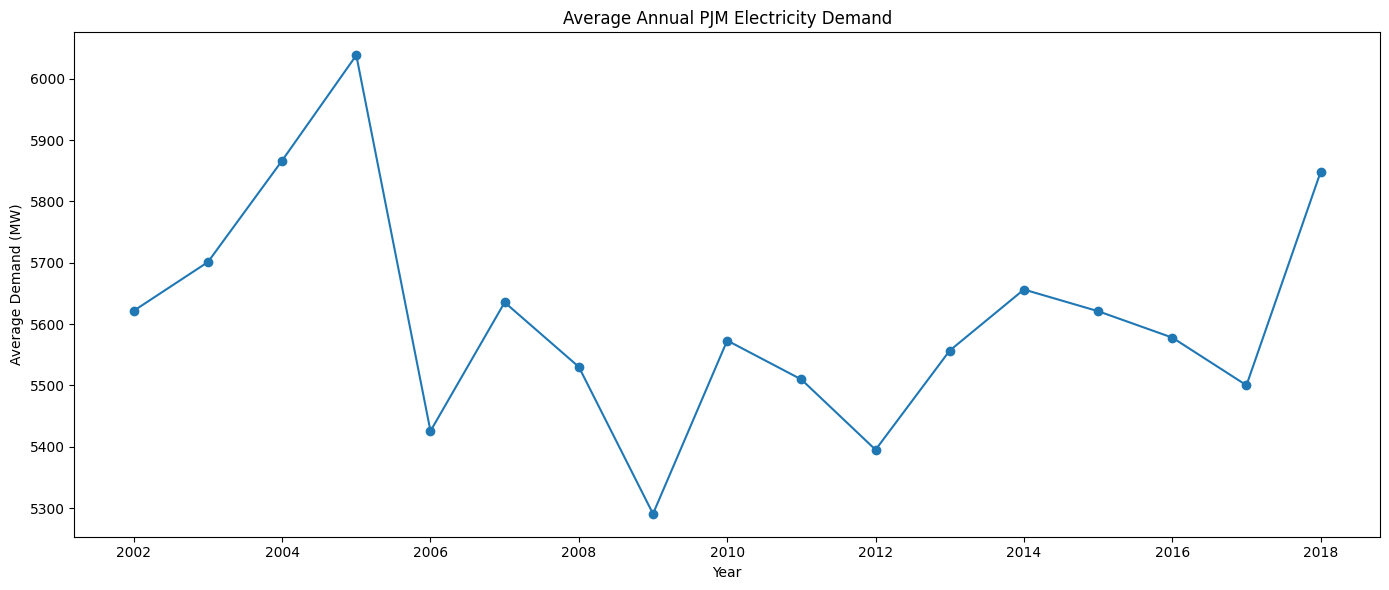

In [102]:
plt.figure(figsize=(14, 6))

plt.plot(
    yearly_demand.index,
    yearly_demand["Mean"],
    marker="o"
)

plt.title(
    "Average Annual PJM Electricity Demand"
)

plt.xlabel("Year")
plt.ylabel("Average Demand (MW)")

plt.tight_layout()
plt.show()

# look at Trend and Season

### DAILY AVERAGE POWER CONSUMPTION: 2013 vs 2014

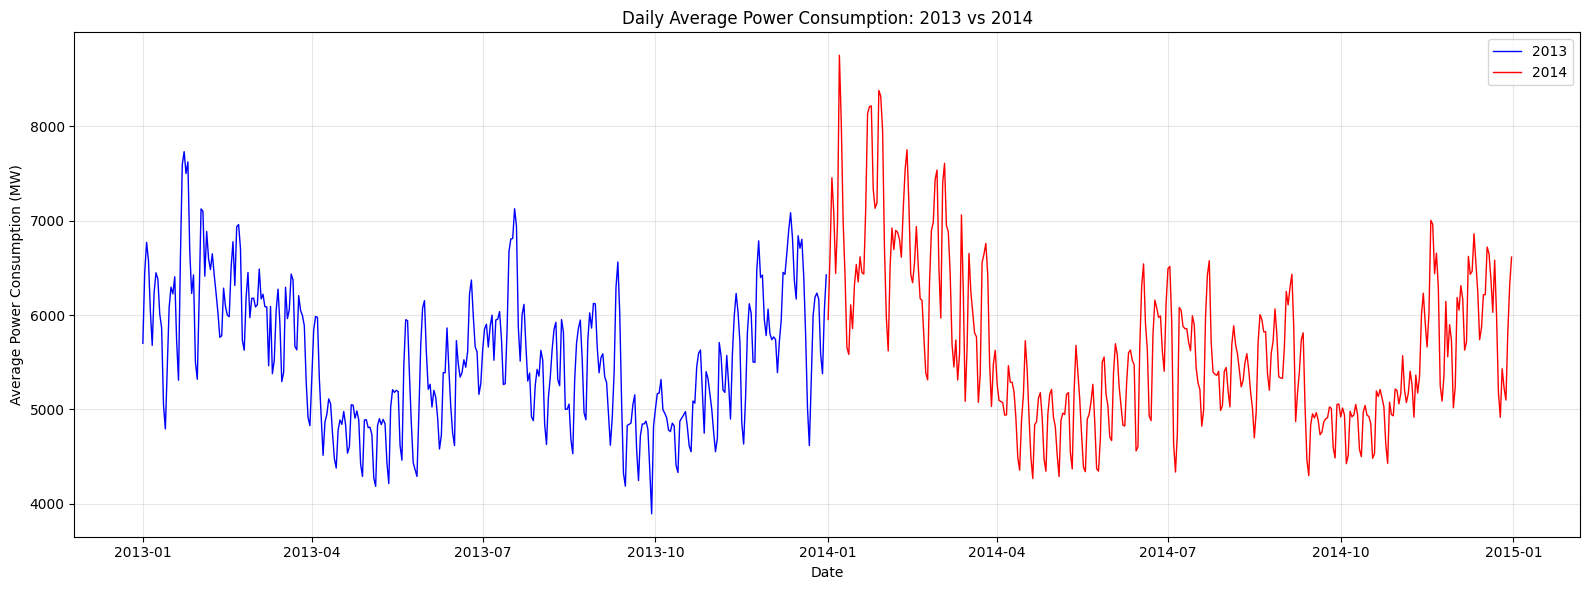

In [105]:
# DAILY AVERAGE POWER CONSUMPTION: 2013 vs 2014

df_2013 = df[df["Year"] == 2013].copy()
df_2014 = df[df["Year"] == 2014].copy()

daily_2013 = (
    df_2013
    .set_index("Datetime")["PJMW_MW"]
    .resample("D")
    .mean()
)

daily_2014 = (
    df_2014
    .set_index("Datetime")["PJMW_MW"]
    .resample("D")
    .mean()
)

plt.figure(figsize=(16, 6))

plt.plot(
    daily_2013.index,
    daily_2013.values,
    color="blue",
    linewidth=1,
    label="2013"
)

plt.plot(
    daily_2014.index,
    daily_2014.values,
    color="red",
    linewidth=1,
    label="2014"
)

plt.title("Daily Average Power Consumption: 2013 vs 2014")
plt.xlabel("Date")
plt.ylabel("Average Power Consumption (MW)")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

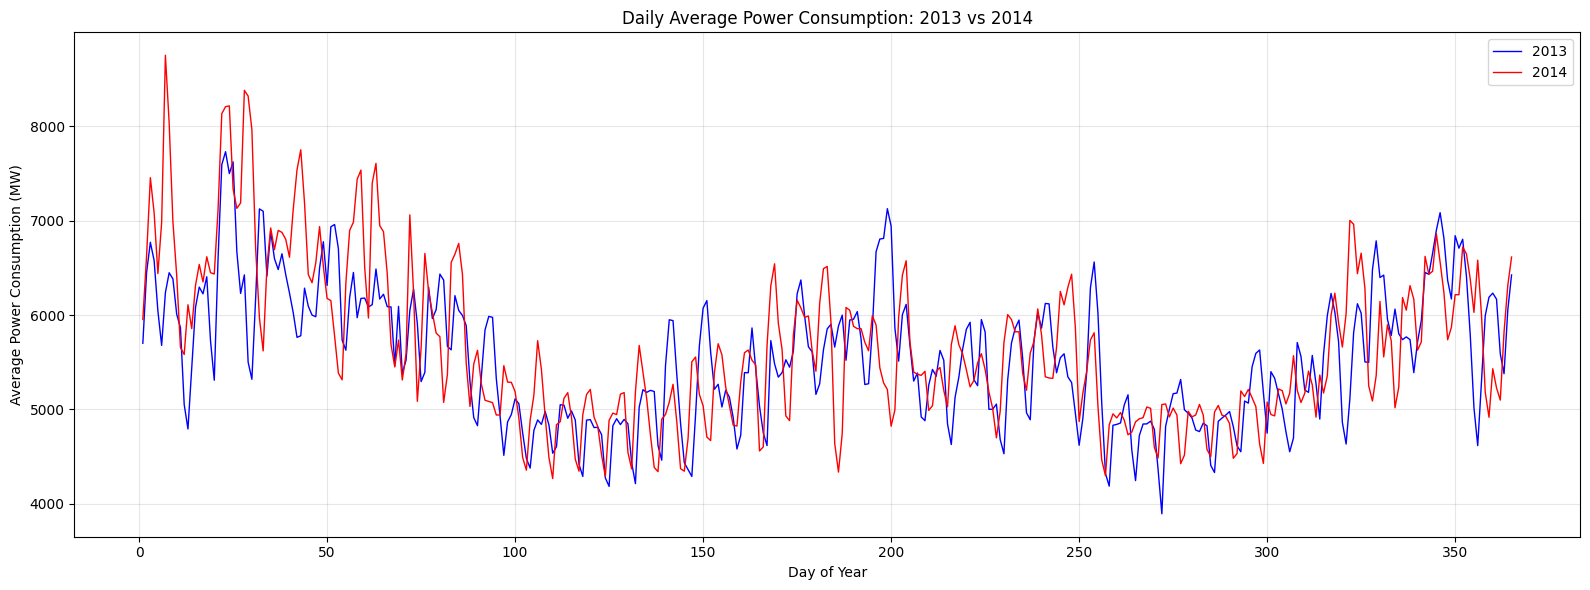

In [106]:
# DAILY AVERAGE: COMPARE 2013 vs 2014
#     SAME MONTH/DAY SCALE

df_2013 = df[df["Year"] == 2013].copy()
df_2014 = df[df["Year"] == 2014].copy()

daily_2013 = (
    df_2013
    .groupby(df_2013["Datetime"].dt.dayofyear)["PJMW_MW"]
    .mean()
)

daily_2014 = (
    df_2014
    .groupby(df_2014["Datetime"].dt.dayofyear)["PJMW_MW"]
    .mean()
)

plt.figure(figsize=(16, 6))

plt.plot(
    daily_2013.index,
    daily_2013.values,
    color="blue",
    linewidth=1,
    label="2013"
)

plt.plot(
    daily_2014.index,
    daily_2014.values,
    color="red",
    linewidth=1,
    label="2014"
)

plt.title("Daily Average Power Consumption: 2013 vs 2014")
plt.xlabel("Day of Year")
plt.ylabel("Average Power Consumption (MW)")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

### YEAR-OVER-YEAR CHANGE IN AVERAGE DEMAND

### Business hypothesis => 

Population ↑ + migration ↑ + industrial activity ↑ → electricity demand ↑ 

=> overall demand should increase from 2002 to 2018

In [109]:
overall_mean = df["PJMW_MW_Clean"].mean()

print("Overall Average Demand:", overall_mean)

Overall Average Demand: 5602.413321276194


In [110]:
# YEARLY AVERAGE POWER DEMAND

yearly_avg = (
    df.groupby("Year")["PJMW_MW_Clean"]
    .mean()
)

display(yearly_avg)

Year
2002    5621.663180
2003    5701.136504
2004    5866.616602
2005    6038.406029
2006    5425.448847
2007    5635.396780
2008    5530.132544
2009    5290.557433
2010    5573.145581
2011    5509.640215
2012    5395.010818
2013    5556.783626
2014    5656.334132
2015    5620.985616
2016    5577.929531
2017    5500.184361
2018    5848.157516
Name: PJMW_MW_Clean, dtype: float64

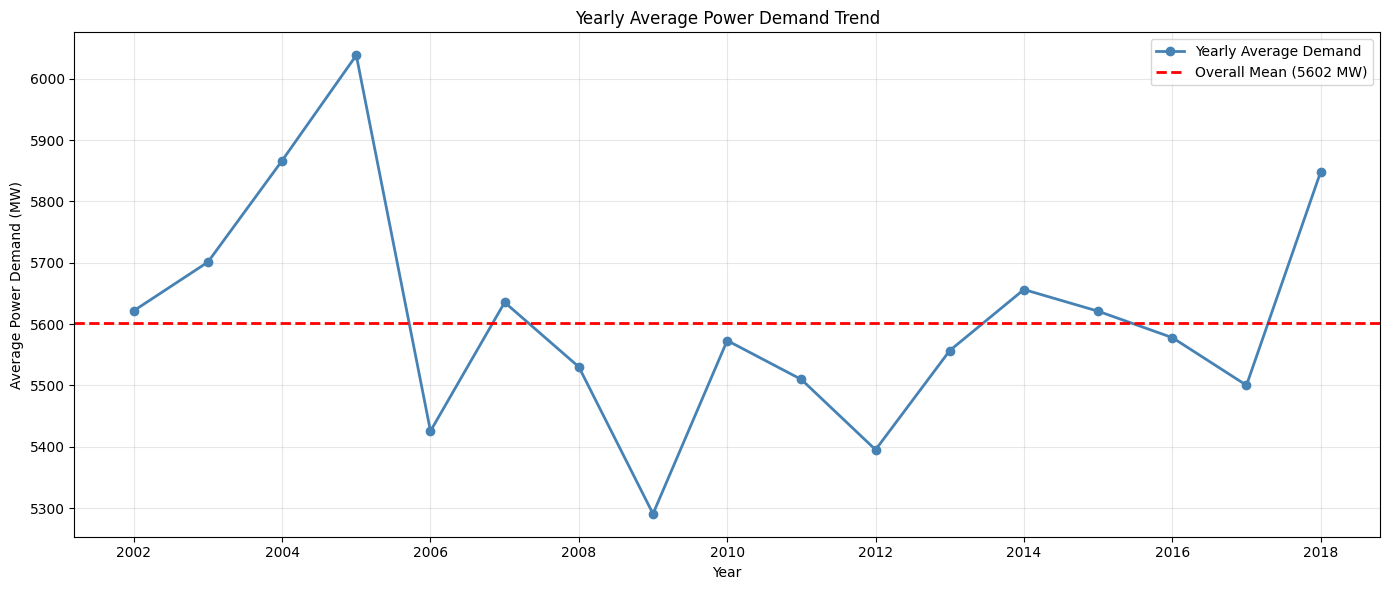

In [111]:
# ============================================================
# YEARLY AVERAGE POWER DEMAND TREND
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    yearly_avg.index,
    yearly_avg.values,
    marker="o",
    linewidth=2,
    color="steelblue",
    label="Yearly Average Demand"
)

# Reference line at 5500 MW
# plt.axhline(
#     y=5500,
#     color="red",
#     linestyle="--",
#     linewidth=2,
#     label="5500 MW Reference"
# )

plt.axhline(
    y=overall_mean,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Overall Mean ({overall_mean:.0f} MW)"
)

plt.xlabel("Year")
plt.ylabel("Average Power Demand (MW)")
plt.title("Yearly Average Power Demand Trend")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

### Key Observations

* Electricity demand does **not increase continuously** every year. It shows fluctuations over time.
* From **2002 to 2005**, average demand increased from **5,621.66 MW to 6,038.41 MW**.
* **2006** shows a significant decrease to **5,425.45 MW**.
* **2009** has one of the lowest yearly averages at **5,290.56 MW**.
* From **2010 to 2014**, demand generally recovered and reached **5,656.33 MW** in 2014.
* From **2015 to 2017**, demand gradually decreased, reaching **5,500.18 MW** in 2017.
* In **2018**, demand increased again to **5,848.16 MW**.


* Overall, the data shows that electricity demand is affected by **multiple factors**, not just population growth or industrial development.
* The **5,500 MW line** is used only as a visual reference to compare yearly average demand.


____

# Seasonal analysis

#### U.S. Seasonal Classification


| Season | Months | Month Numbers |
|---|---|---|
| ❄️ Winter | December, January, February | 12, 1, 2 |
| 🌱 Spring | March, April, May | 3, 4, 5 |
| ☀️ Summer | June, July, August | 6, 7, 8 |
| 🍂 Fall | September, October, November | 9, 10, 11 |


In [116]:
# U.S. SEASON CLASSIFICATION

season_map = {
    12: "Winter",
    1: "Winter",
    2: "Winter",

    3: "Spring",
    4: "Spring",
    5: "Spring",

    6: "Summer",
    7: "Summer",
    8: "Summer",

    9: "Fall",
    10: "Fall",
    11: "Fall"
}

df["Season"] = df["Month"].map(season_map)

display(
    df[
        [
            "Datetime",
            "Month",
            "Month_Name",
            "Season"
        ]
    ].head(20)
)

,Datetime,Month,Month_Name,Season
0,2002-04-01 01:00:00,4,April,Spring
1,2002-04-01 02:00:00,4,April,Spring
2,2002-04-01 03:00:00,4,April,Spring
3,2002-04-01 04:00:00,4,April,Spring
4,2002-04-01 05:00:00,4,April,Spring
5,2002-04-01 06:00:00,4,April,Spring
6,2002-04-01 07:00:00,4,April,Spring
7,2002-04-01 08:00:00,4,April,Spring
8,2002-04-01 09:00:00,4,April,Spring
9,2002-04-01 10:00:00,4,April,Spring


In [117]:
# Set Season Order

season_order = [
    "Winter",
    "Spring",
    "Summer",
    "Fall"
]

In [118]:
# SEASONAL DEMAND

seasonal_demand = (
    df
    .groupby("Season")["PJMW_MW_Clean"]
    .agg(
        Mean="mean",
        Median="median",
        Minimum="min",
        Maximum="max"
    )
    .reindex(season_order)
)

display(seasonal_demand)

,Mean,Median,Minimum,Maximum
Season,,,,
Winter,6268.824157,6258.5,3585.0,9594.0
Spring,5224.515840,5227.0,2553.0,8622.0
Summer,5734.206129,5688.0,3255.0,8998.0
Fall,5200.143147,5207.0,3197.0,8266.0


Seasonal plot

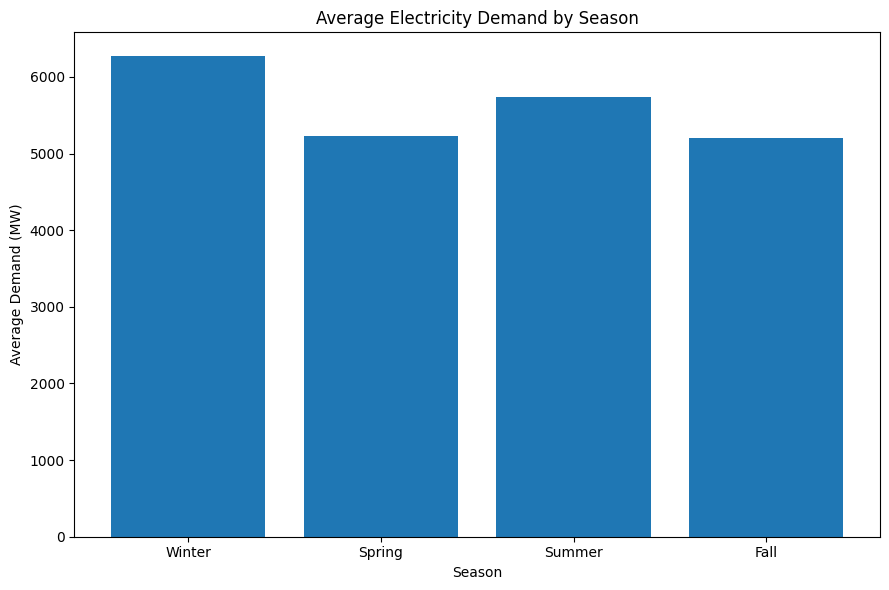

In [120]:
plt.figure(figsize=(9, 6))

plt.bar(
    seasonal_demand.index,
    seasonal_demand["Mean"]
)

plt.title(
    "Average Electricity Demand by Season"
)

plt.xlabel("Season")
plt.ylabel("Average Demand (MW)")

plt.tight_layout()
plt.show()

Hourly Behaviour as pre Season

In [122]:
# ============================================================
# 48. HOURLY PROFILE BY SEASON
# ============================================================

season_hourly = (
    df
    .groupby(
        ["Season", "Hour"]
    )["PJMW_MW_Clean"]
    .mean()
    .unstack(0)
)

display(season_hourly)

Season,Fall,Spring,Summer,Winter
Hour,,,,
0,4806.136676,4886.570822,5327.760417,5923.326870
1,4545.118819,4630.318982,4921.393485,5688.731994
2,4403.227210,4499.615786,4662.691205,5576.684903
3,4333.835852,4441.108839,4501.020847,5540.664820
4,4317.000000,4441.919765,4407.318567,5557.793629
5,4384.278846,4525.054142,4405.762866,5661.231994
6,4619.474588,4776.295499,4550.683388,5926.093490
7,5039.595467,5172.560339,4779.746580,6347.755540
8,5258.665522,5405.725375,5067.076873,6597.767313


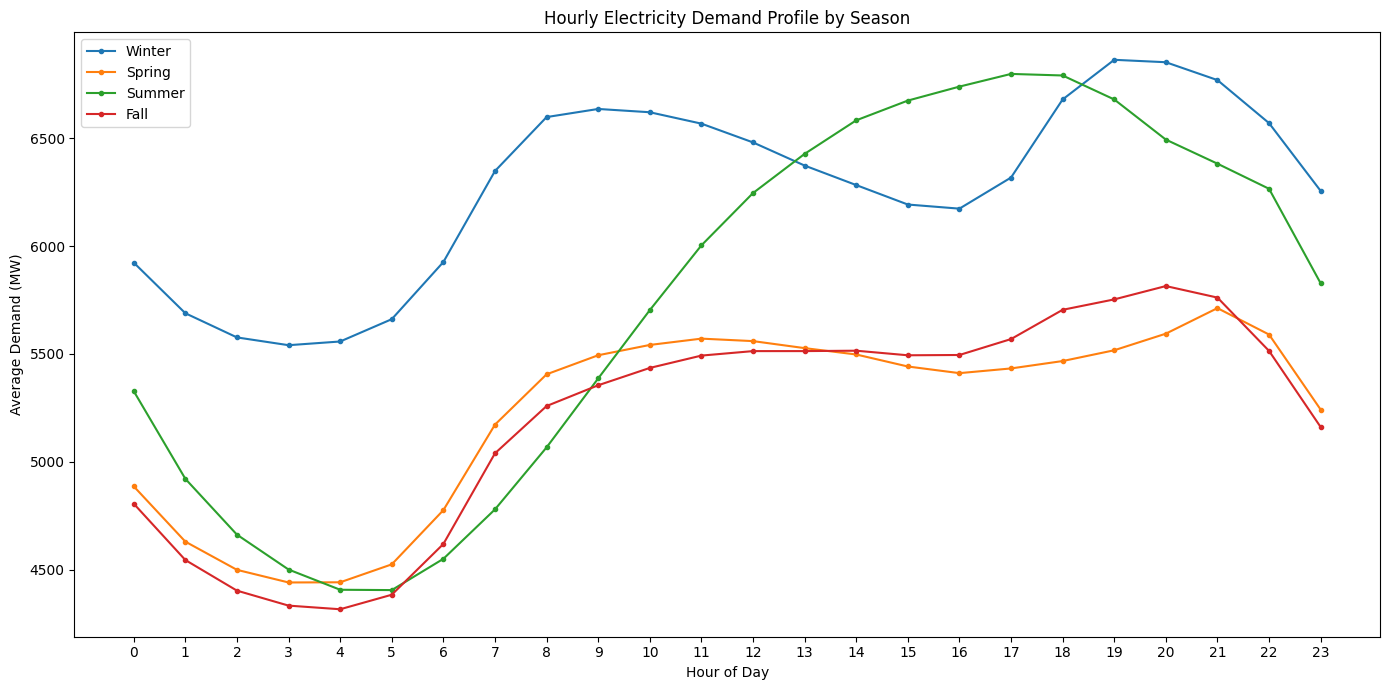

In [123]:
plt.figure(figsize=(14, 7))

for season in season_order:

    plt.plot(
        season_hourly.index,
        season_hourly[season],
        marker="o",
        markersize=3,
        label=season
    )

plt.title(
    "Hourly Electricity Demand Profile by Season"
)

plt.xlabel("Hour of Day")
plt.ylabel("Average Demand (MW)")

plt.xticks(range(24))

plt.legend()

plt.tight_layout()
plt.show()

## Month Analysis

In [125]:
# ============================================================
# 44. MONTHLY DEMAND
# ============================================================

month_order = list(range(1, 13))

monthly_demand = (
    df
    .groupby("Month")["PJMW_MW_Clean"]
    .mean()
    .reindex(month_order)
)

display(
    monthly_demand.to_frame(
        name="Average_Demand_MW"
    )
)

,Average_Demand_MW
Month,
1,6447.667759
2,6296.808813
3,5654.097376
4,5022.310855
5,5016.197699
6,5516.756046
7,5861.537081
8,5822.142809
9,5205.872049


Monthly Plot

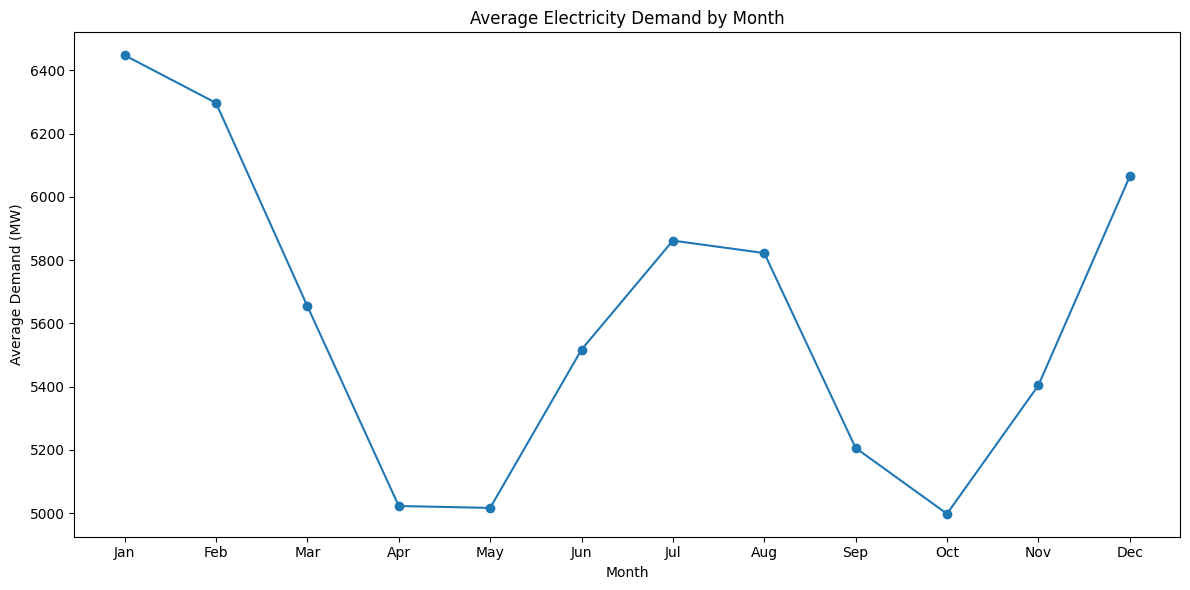

In [127]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_demand.index,
    monthly_demand.values,
    marker="o"
)

plt.title(
    "Average Electricity Demand by Month"
)

plt.xlabel("Month")
plt.ylabel("Average Demand (MW)")

plt.xticks(
    range(1, 13),
    [
        "Jan", "Feb", "Mar",
        "Apr", "May", "Jun",
        "Jul", "Aug", "Sep",
        "Oct", "Nov", "Dec"
    ]
)

plt.tight_layout()
plt.show()

Month + hour analysis

In [129]:
# ============================================================
# 50. MONTHLY HOURLY PROFILE
# ============================================================

month_hourly = (
    df
    .groupby(
        ["Month", "Hour"]
    )["PJMW_MW_Clean"]
    .mean()
    .unstack()
)

display(month_hourly)

Hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Month,,,,,,,,,,,,,,,,,,,,,
1,6066.701613,5846.125000,5744.000000,5714.372984,5733.824597,5836.754032,6105.453629,6522.723790,6790.247984,6821.002016,...,6485.151210,6389.147177,6369.600806,6506.760081,6883.614919,7046.054435,7018.899194,6925.897177,6716.556452,6401.252016
2,5965.500000,5756.856195,5664.373894,5639.356195,5665.035398,5774.393805,6051.477876,6493.586283,6708.566372,6725.325221,...,6292.141593,6190.223451,6150.840708,6235.396018,6471.378319,6792.044248,6821.787611,6742.006637,6544.628319,6244.477876
3,5325.233871,5117.151210,5021.641129,5001.956612,5020.395161,5134.528226,5419.360887,5868.661290,6089.157258,6103.687500,...,5737.939516,5632.358871,5570.792339,5594.094758,5674.989919,5856.645161,6047.854839,6096.000000,5916.258065,5606.622984
4,4690.776031,4447.550980,4324.039216,4276.259406,4283.160784,4371.398039,4631.650980,5051.403922,5265.805882,5341.901961,...,5269.768627,5202.666667,5160.380392,5167.260784,5185.511765,5203.811765,5295.374510,5515.935294,5379.007843,5035.445098
5,4662.818786,4348.996205,4178.210626,4083.990512,4051.110057,4100.130930,4311.036053,4634.654649,4897.901328,5067.546490,...,5491.867173,5494.290323,5503.586338,5538.398482,5544.203036,5500.850095,5456.024668,5541.563567,5487.218216,5099.248577
6,5133.729412,4737.149020,4493.323529,4346.854902,4266.764706,4276.674510,4427.547059,4661.156863,4985.056863,5287.047059,...,6274.719608,6342.835294,6398.394118,6454.443137,6450.915686,6358.711765,6203.633333,6086.278431,6040.041176,5634.482353
7,5460.648956,5039.225806,4762.104364,4585.269450,4478.612903,4465.341556,4594.208729,4782.825427,5089.514231,5444.434535,...,6779.366224,6874.796964,6939.478178,6996.806452,6989.309298,6876.929791,6675.565465,6503.290323,6406.195446,5975.654649
8,5385.723447,4985.383534,4730.937751,4569.746988,4475.813253,4474.913655,4630.726908,4897.935743,5127.329317,5427.566265,...,6689.997992,6801.196787,6875.622490,6938.759036,6928.044177,6798.853414,6597.429719,6556.002008,6347.431727,5868.495984
9,4778.172917,4460.281250,4270.660417,4159.691667,4103.233333,4131.070833,4327.906250,4718.191667,4909.970833,5085.262500,...,5810.979167,5864.664583,5908.420833,5960.756250,5955.045833,5868.018750,5895.647917,5909.270833,5605.489583,5180.208333


Plot Month vs Hours Distribution

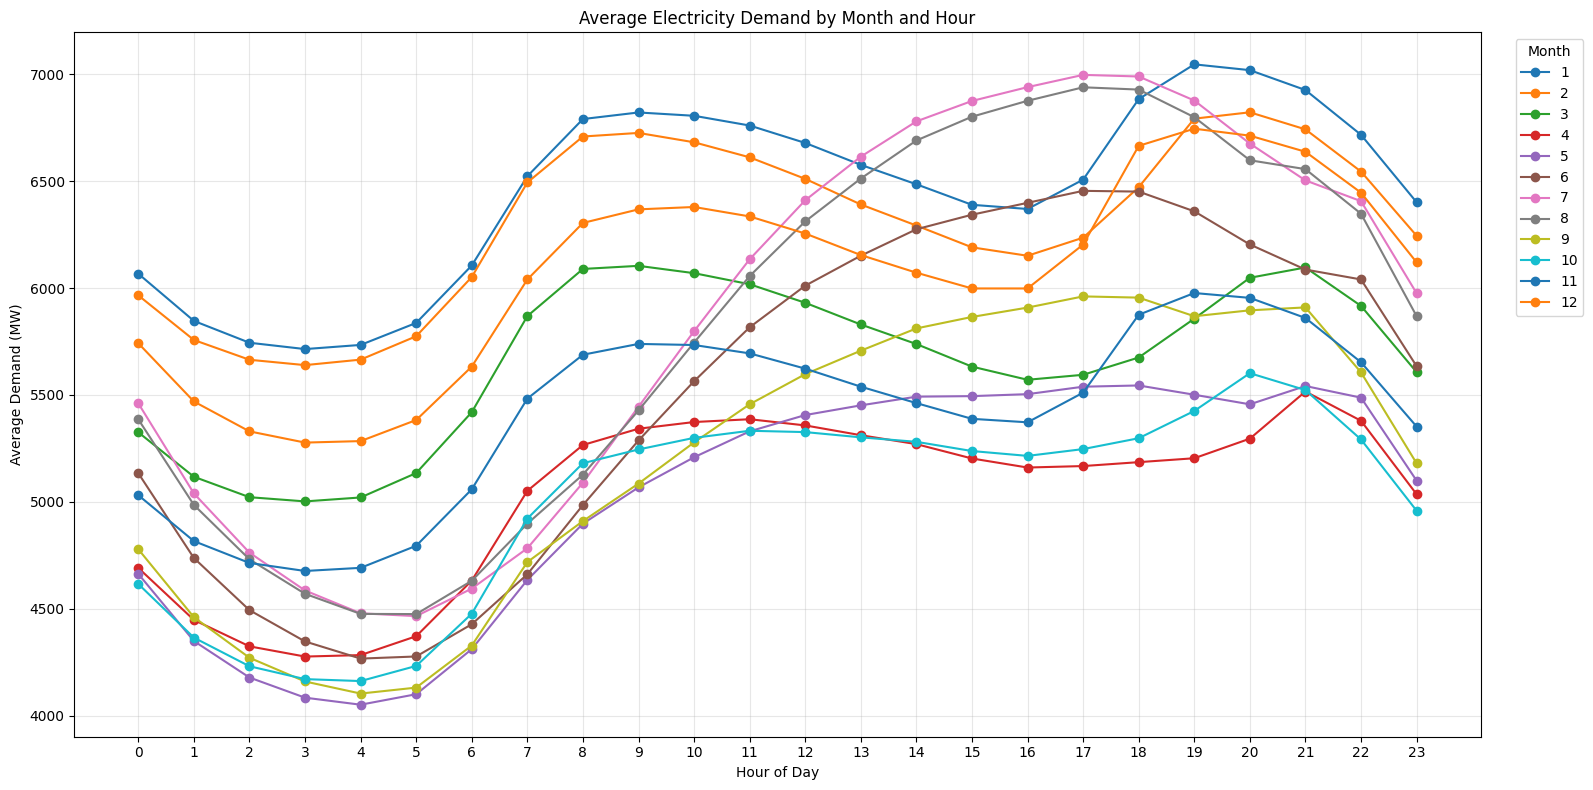

In [131]:
# ============================================================
# 51. MONTH VS HOUR - LINE CHART
# ============================================================

plt.figure(figsize=(16, 8))

for month in month_hourly.index:
    plt.plot(
        month_hourly.columns,
        month_hourly.loc[month],
        marker="o",
        linewidth=1.5,
        label=month
    )

plt.title("Average Electricity Demand by Month and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Demand (MW)")

plt.xticks(range(24))
plt.grid(True, alpha=0.3)

plt.legend(
    title="Month",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## Week Analysis

i.e DAY OF WEEK ANALYSIS

In [133]:
# ============================================================
# 42. DAY OF WEEK ANALYSIS
# ============================================================

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_demand = (
    df
    .groupby("Day_Name")["PJMW_MW_Clean"]
    .mean()
    .reindex(day_order)
)

display(
    daily_demand.to_frame(
        name="Average_Demand_MW"
    )
)

,Average_Demand_MW
Day_Name,
Monday,5700.518783
Tuesday,5801.076837
Wednesday,5802.370701
Thursday,5781.058495
Friday,5686.885129
Saturday,5293.999413
Sunday,5149.638300


Plot Day-of-Week demand

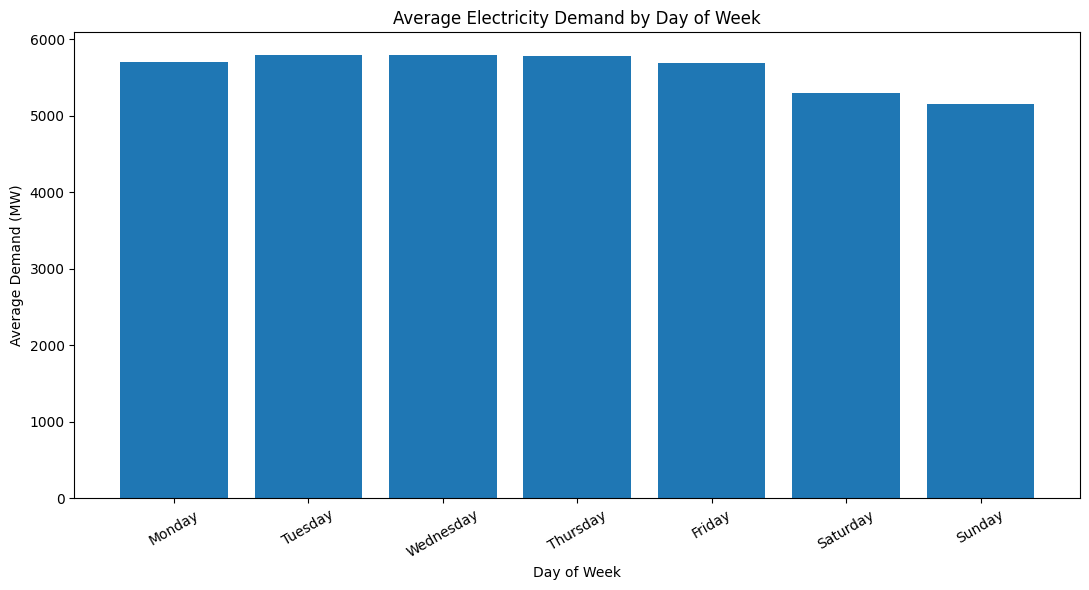

In [135]:
plt.figure(figsize=(11, 6))

plt.bar(
    daily_demand.index,
    daily_demand.values
)

plt.title(
    "Average Electricity Demand by Day of Week"
)

plt.xlabel("Day of Week")
plt.ylabel("Average Demand (MW)")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Weekday vs Weekend

In [137]:
# WEEKEND FEATURE

df["Is_Weekend"] = (
    df["DayOfWeek"] >= 5
).astype(int)

df["Day_Type"] = np.where(
    df["Is_Weekend"] == 1,
    "Weekend",
    "Weekday"
)

display(
    df[
        [
            "Datetime",
            "Day_Name",
            "Is_Weekend",
            "Day_Type"
        ]
    ].head(24*7)
)

,Datetime,Day_Name,Is_Weekend,Day_Type
0,2002-04-01 01:00:00,Monday,0,Weekday
1,2002-04-01 02:00:00,Monday,0,Weekday
2,2002-04-01 03:00:00,Monday,0,Weekday
3,2002-04-01 04:00:00,Monday,0,Weekday
4,2002-04-01 05:00:00,Monday,0,Weekday
...,...,...,...,...
163,2002-04-07 21:00:00,Sunday,1,Weekend
164,2002-04-07 22:00:00,Sunday,1,Weekend
165,2002-04-07 23:00:00,Sunday,1,Weekend
166,2002-04-08 00:00:00,Monday,0,Weekday


In [138]:
# WEEKDAY VS WEEKEND

weekday_weekend = (
    df
    .groupby("Day_Type")["PJMW_MW_Clean"]
    .agg(
        Mean="mean",
        Median="median",
        Minimum="min",
        Maximum="max"
    )
)

display(weekday_weekend)

,Mean,Median,Minimum,Maximum
Day_Type,,,,
Weekday,5754.397685,5671.0,2553.0,9594.0
Weekend,5221.863008,5136.0,2574.0,9003.0


Plot Weekday vs Weekend

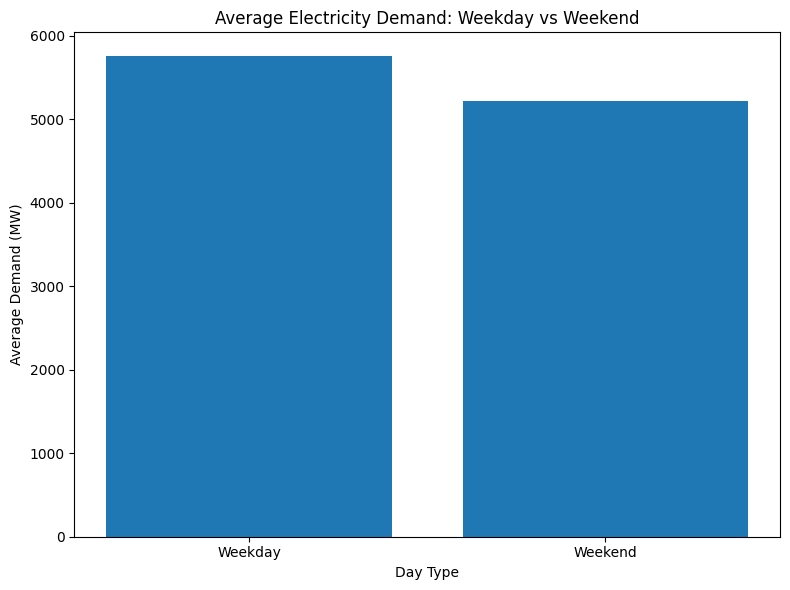

In [140]:
plt.figure(figsize=(8, 6))

plt.bar(
    weekday_weekend.index,
    weekday_weekend["Mean"]
)

plt.title(
    "Average Electricity Demand: Weekday vs Weekend"
)

plt.xlabel("Day Type")
plt.ylabel("Average Demand (MW)")

plt.tight_layout()
plt.show()

## Hourly Analysis

i.e. Hour-of-day analysis

In [142]:
# ============================================================
# 40. AVERAGE DEMAND BY HOUR
# ============================================================

hourly_demand = (
    df
    .groupby("Hour")["PJMW_MW_Clean"]
    .mean()
)

display(
    hourly_demand.to_frame(
        name="Average_Demand_MW"
    )
)

,Average_Demand_MW
Hour,
0,5231.348107
1,4940.489276
2,4779.152349
3,4697.121996
4,4672.537366
5,4734.933479
6,4958.209450
7,5323.434316
8,5571.168398


Plot Hourly Demand

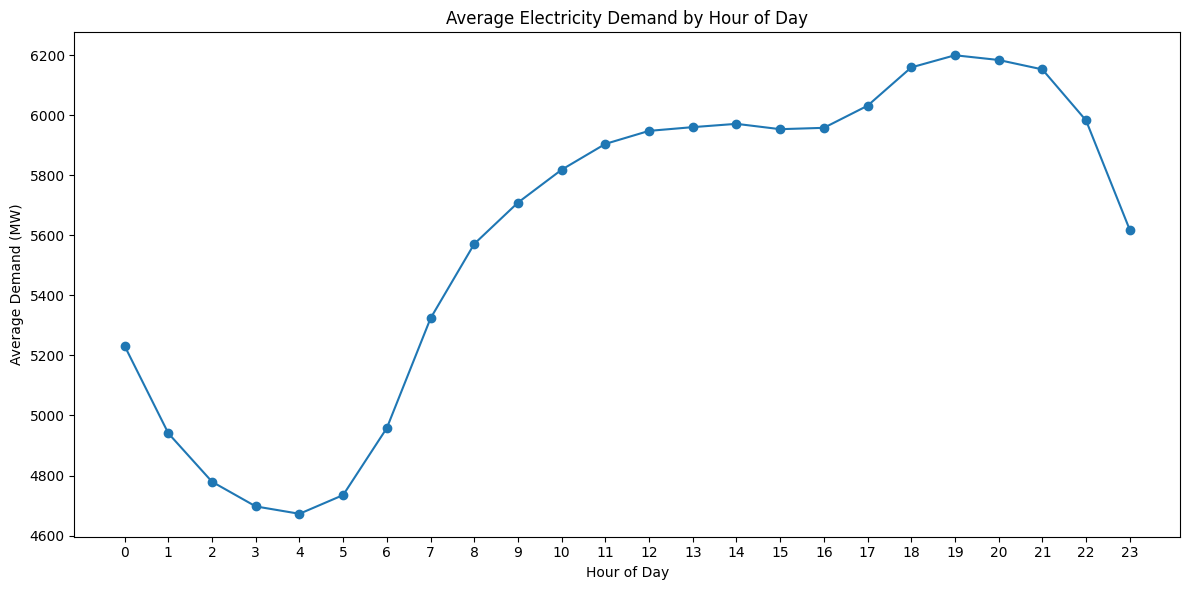

In [144]:
plt.figure(figsize=(12, 6))

plt.plot(
    hourly_demand.index,
    hourly_demand.values,
    marker="o"
)

plt.title(
    "Average Electricity Demand by Hour of Day"
)

plt.xlabel("Hour of Day")
plt.ylabel("Average Demand (MW)")

plt.xticks(range(24))

plt.tight_layout()
plt.show()

____

## Holiday analysis

#### Major U.S. Holidays for Electricity Consumption Analysis

| Holiday | Date / Rule |
|---|---|
| New Year's Day | January 1 |
| Martin Luther King Jr. Day | 3rd Monday of January |
| Presidents' Day | 3rd Monday of February |
| Memorial Day | Last Monday of May |
| Independence Day | July 4 |
| Labor Day | 1st Monday of September |
| Thanksgiving Day | 4th Thursday of November |
| Day After Thanksgiving (Black Friday) | Friday after Thanksgiving |
| Christmas Eve | December 24 |
| Christmas Day | December 25 |
| New Year's Eve | December 31 |

In [147]:
# HOLIDAY FUNCTIONS

def nth_weekday(year, month, weekday, n):
    """
    Return the date of the nth weekday in a month.

    weekday:
        Monday = 0
        Tuesday = 1
        ...
        Sunday = 6
    """

    dates = pd.date_range(
        start=f"{year}-{month:02d}-01",
        end=f"{year}-{month:02d}-28"
    )

    matching_days = dates[
        dates.weekday == weekday
    ]

    return matching_days[n - 1]


def last_weekday(year, month, weekday):
    """
    Return the date of the last specified weekday
    in a month.
    """

    start = pd.Timestamp(
        year=year,
        month=month,
        day=1
    )

    end = (
        start
        + pd.offsets.MonthEnd(1)
    )

    dates = pd.date_range(
        start=start,
        end=end
    )

    matching_days = dates[
        dates.weekday == weekday
    ]

    return matching_days[-1]

In [148]:
# CREATE HOLIDAY CALENDAR

def create_us_holidays(start_year, end_year):

    holiday_dict = {}

    for year in range(start_year, end_year + 1):

        # New Year's Day
        holiday_dict[
            pd.Timestamp(year, 1, 1)
        ] = "New Year's Day"

        # Martin Luther King Jr. Day
        mlk = nth_weekday(
            year,
            1,
            0,
            3
        )

        holiday_dict[mlk] = (
            "Martin Luther King Jr. Day"
        )

        # Presidents' Day
        presidents = nth_weekday(
            year,
            2,
            0,
            3
        )

        holiday_dict[presidents] = (
            "Presidents' Day"
        )

        # Memorial Day
        memorial = last_weekday(
            year,
            5,
            0
        )

        holiday_dict[memorial] = (
            "Memorial Day"
        )

        # Independence Day
        holiday_dict[
            pd.Timestamp(year, 7, 4)
        ] = "Independence Day"

        # Labor Day
        labor = nth_weekday(
            year,
            9,
            0,
            1
        )

        holiday_dict[labor] = "Labor Day"

        # Thanksgiving
        thanksgiving = nth_weekday(
            year,
            11,
            3,
            4
        )

        holiday_dict[thanksgiving] = (
            "Thanksgiving Day"
        )

        # Black Friday
        black_friday = (
            thanksgiving
            + pd.Timedelta(days=1)
        )

        holiday_dict[black_friday] = (
            "Day After Thanksgiving"
        )

        # Christmas Eve
        holiday_dict[
            pd.Timestamp(year, 12, 24)
        ] = "Christmas Eve"

        # Christmas Day
        holiday_dict[
            pd.Timestamp(year, 12, 25)
        ] = "Christmas Day"

        # New Year's Eve
        holiday_dict[
            pd.Timestamp(year, 12, 31)
        ] = "New Year's Eve"

    return holiday_dict

In [149]:
# GENERATE HOLIDAY CALENDAR

start_year = df["Year"].min()
end_year = df["Year"].max()

holiday_calendar = create_us_holidays(
    start_year,
    end_year
)

print(
    "Number of holiday dates created:",
    len(holiday_calendar)
)

Number of holiday dates created: 187


Add holiday information to dataset

In [151]:
# ADD HOLIDAY INFORMATION

df["Holiday_Name"] = (
    df["Datetime"]
    .dt.normalize()
    .map(holiday_calendar)
)

df["Is_Holiday"] = (
    df["Holiday_Name"]
    .notna()
    .astype(int)
)

df["Holiday_Name"] = (
    df["Holiday_Name"]
    .fillna("None")
)

In [152]:
display(
    df[
        df["Is_Holiday"] == 1
    ][
        [
            "Datetime",
            "Holiday_Name",
            "PJMW_MW_Clean"
        ]
    ].head(30)
)

,Datetime,Holiday_Name,PJMW_MW_Clean
1342,2002-05-27 00:00:00,Memorial Day,4307.0
1343,2002-05-27 01:00:00,Memorial Day,4023.0
1344,2002-05-27 02:00:00,Memorial Day,3871.0
1345,2002-05-27 03:00:00,Memorial Day,3801.0
1346,2002-05-27 04:00:00,Memorial Day,3745.0
1347,2002-05-27 05:00:00,Memorial Day,3712.0
1348,2002-05-27 06:00:00,Memorial Day,3728.0
1349,2002-05-27 07:00:00,Memorial Day,3797.0
1350,2002-05-27 08:00:00,Memorial Day,3986.0
1351,2002-05-27 09:00:00,Memorial Day,4358.0


In [153]:
# ============================================================
# 55. HOLIDAY VS NON-HOLIDAY
# ============================================================

holiday_summary = (
    df
    .groupby("Is_Holiday")["PJMW_MW_Clean"]
    .agg(
        Mean="mean",
        Median="median",
        Minimum="min",
        Maximum="max",
        Count="count"
    )
)

holiday_summary.index = [
    "Non-Holiday",
    "Holiday"
]

display(holiday_summary)

,Mean,Median,Minimum,Maximum,Count
Non-Holiday,5604.502382,5532.0,2553.0,9594.0,138935
Holiday,5534.472378,5466.0,3286.0,9187.0,4272


Holiday vs non-holiday graph

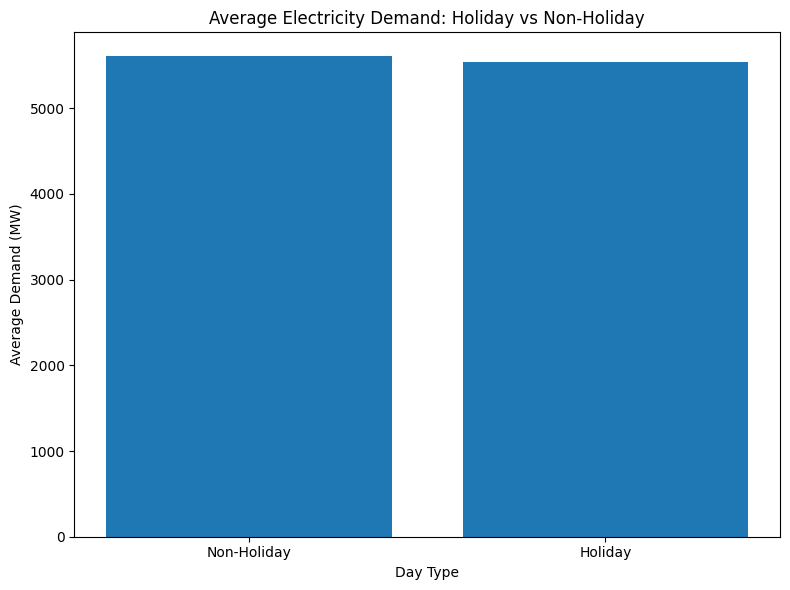

In [155]:
plt.figure(figsize=(8, 6))

plt.bar(
    holiday_summary.index,
    holiday_summary["Mean"]
)

plt.title(
    "Average Electricity Demand: Holiday vs Non-Holiday"
)

plt.xlabel("Day Type")
plt.ylabel("Average Demand (MW)")

plt.tight_layout()
plt.show()

In [156]:
# HOLIDAY DEMAND BY SEASON


holiday_season = (
    df
    .groupby(
        ["Season", "Is_Holiday"]
    )["PJMW_MW_Clean"]
    .mean()
    .unstack()
)

holiday_season.columns = [
    "Non-Holiday",
    "Holiday"
]

display(holiday_season)

,Non-Holiday,Holiday
Season,,
Fall,5203.286852,5107.949653
Spring,5228.403303,4878.017157
Summer,5739.756786,5238.551471
Winter,6293.923776,5916.383681


_____

### Season × day × hour

In [159]:
#  SEASON + DAY TYPE + HOUR

season_day_hour = (
    df
    .groupby(
        [
            "Season",
            "Day_Type",
            "Hour"
        ]
    )["PJMW_MW_Clean"]
    .mean()
)

display(
    season_day_hour.head(30)
)

Season  Day_Type  Hour
Fall    Weekday   0       4853.503846
                  1       4595.413462
                  2       4459.230769
                  3       4396.199038
                  4       4386.921154
                  5       4474.313462
                  6       4767.078846
                  7       5289.325000
                  8       5520.840385
                  9       5561.876923
                  10      5606.978846
                  11      5661.685577
                  12      5684.164423
                  13      5686.623077
                  14      5697.549038
                  15      5678.563462
                  16      5676.377885
                  17      5743.481731
                  18      5868.629808
                  19      5913.926923
                  20      5974.640385
                  21      5915.262500
                  22      5653.298077
                  23      5273.250962
        Weekend   0       4687.718750
                  1       4

Hour on the X-axis, Demand on the Y-axis, and separate colored lines for the Season + Day Type combinations.

That gives you 8 distinct lines:

- Winter – Weekday
- Winter – Weekend
- Spring – Weekday
- Spring – Weekend
- Summer – Weekday
- Summer – Weekend
- Fall – Weekday
- Fall – Weekend

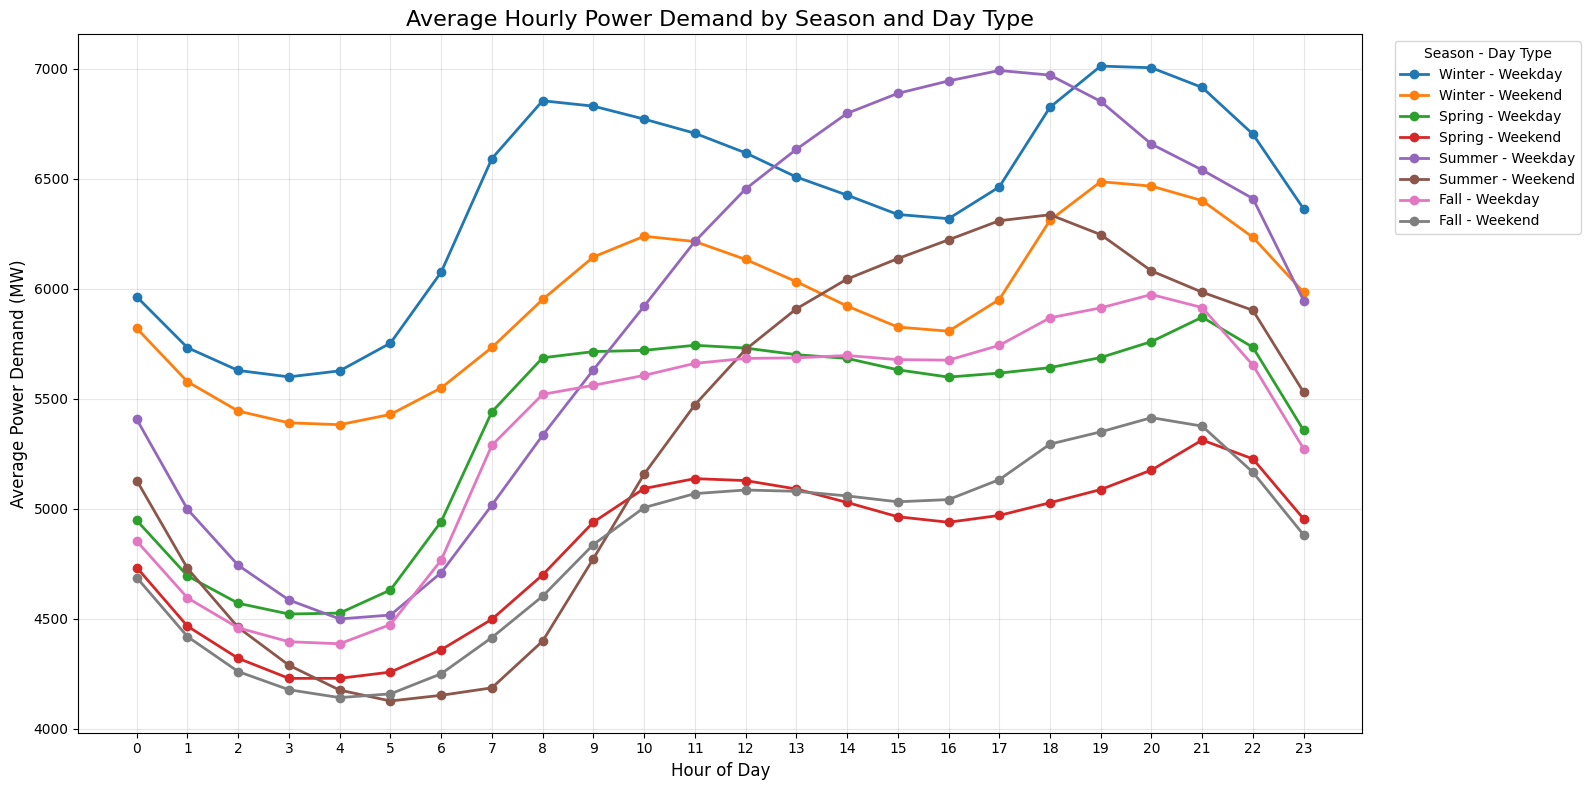

In [161]:
# Ploting SEASON + DAY TYPE + HOUR
# Hourly demand profile by Season and Day Type

# Calculate average demand
season_day_hour = (
    df.groupby(
        ["Season", "Day_Type", "Hour"]
    )["PJMW_MW_Clean"]
    .mean()
    .reset_index()
)

# Season order
season_order = ["Winter", "Spring", "Summer", "Fall"]

# Day type order
day_type_order = ["Weekday", "Weekend"]

# Create one figure
plt.figure(figsize=(16, 8))

# Plot each Season + Day Type combination
for season in season_order:
    
    for day_type in day_type_order:
        
        temp = season_day_hour[
            (season_day_hour["Season"] == season) &
            (season_day_hour["Day_Type"] == day_type)
        ]
        
        plt.plot(
            temp["Hour"],
            temp["PJMW_MW_Clean"],
            marker="o",
            linewidth=2,
            label=f"{season} - {day_type}"
        )

# Graph formatting
plt.title(
    "Average Hourly Power Demand by Season and Day Type",
    fontsize=16
)

plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Average Power Demand (MW)", fontsize=12)

plt.xticks(range(24))

plt.legend(
    title="Season - Day Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

____

___

### Rolling Mean And Rolling Standard Deviation -> Check data is stationary 

From 2002-2018 claculating 24-hours & 168-hours i.e 7 days window rolling mean and standard deviation

In [165]:
# ============================================================
# LEAKAGE-FREE ROLLING FEATURES
# ============================================================

# shift(1) ensures the current demand value is NOT included.
# Therefore, features at time t use only information from t-1
# and earlier.

# ------------------------------------------------------------
# 24-HOUR ROLLING FEATURES
# ------------------------------------------------------------

df["Rolling_Mean_24"] = (
    df["PJMW_MW_Clean"]
    .shift(1)
    .rolling(window=24, min_periods=24)
    .mean()
)

df["Rolling_Std_24"] = (
    df["PJMW_MW_Clean"]
    .shift(1)
    .rolling(window=24, min_periods=24)
    .std()
)


# ------------------------------------------------------------
# 168-HOUR (7-DAY) ROLLING FEATURES
# ------------------------------------------------------------

df["Rolling_Mean_168"] = (
    df["PJMW_MW_Clean"]
    .shift(1)
    .rolling(window=168, min_periods=168)
    .mean()
)

df["Rolling_Std_168"] = (
    df["PJMW_MW_Clean"]
    .shift(1)
    .rolling(window=168, min_periods=168)
    .std()
)

Also, min_periods=24 and min_periods=168 deliberately leave the initial rows as NaN rather than calculating incomplete rolling windows. We'll handle those rows later when preparing the model-ready dataset.

Yes — absolutely. In fact, **keeping those initial `NaN`s for now is the safer choice**.

Here's why:

* `Rolling_Mean_24` and `Rolling_Std_24` need **24 previous observations**, so the first 24 rows cannot have valid values.
* `Rolling_Mean_168` and `Rolling_Std_168` need **168 previous observations**, so the first 168 rows cannot have valid values.
* These are **expected NaNs**, not missing data problems.
* We should **not interpolate or fill them**, because that would create artificial historical information.
* Later, when we create the **train/validation/test split and model-ready dataset**, we can simply remove the rows that don't have enough historical information.

So your current approach is correct:

```python
.shift(1)
.rolling(window=24, min_periods=24)
```

and

```python
.shift(1)
.rolling(window=168, min_periods=168)
```

### One important thing

Don't delete those rows **right now**.

Keep them while we continue checking the dataset. When we reach the model-preparation stage, we'll handle them properly.

Your workflow should therefore be:

**Clean demand → create leakage-free rolling features → check other leakage → create lag features → time split → scale using training data → remove/handle initial NaNs → final model-ready dataset.**

So yes, **leave those NaNs as they are for now.**


In [168]:
# Display 24 & 168 hours rolling data -> last 55 enteries 
display(
    df[
        [
            "Datetime",
            "PJMW_MW_Clean",
            "Rolling_Mean_24",
            "Rolling_Std_24",
            "Rolling_Mean_168",
            "Rolling_Std_168"
        ]
    ].tail(55)
)

,Datetime,PJMW_MW_Clean,Rolling_Mean_24,Rolling_Std_24,Rolling_Mean_168,Rolling_Std_168
143152,2018-07-31 18:00:00,6480.0,5612.500000,769.871870,5757.880952,923.054211
143153,2018-07-31 19:00:00,6426.0,5622.833333,780.144227,5753.559524,917.919169
143154,2018-07-31 20:00:00,6276.0,5632.791667,789.132379,5749.779762,913.801367
143155,2018-07-31 21:00:00,6250.0,5637.125000,792.500408,5746.083333,910.382557
143156,2018-07-31 22:00:00,6123.0,5644.750000,797.679692,5742.922619,907.685746
143157,2018-07-31 23:00:00,5771.0,5653.625000,801.932764,5740.029762,905.681213
143158,2018-08-01 00:00:00,5343.0,5660.750000,802.195208,5737.785714,905.131202
143159,2018-08-01 01:00:00,5061.0,5668.916667,797.722842,5735.255952,905.640026
143160,2018-08-01 02:00:00,4817.0,5677.833333,789.287718,5733.613095,906.616609
143161,2018-08-01 03:00:00,4687.0,5689.583333,773.475494,5732.083333,907.952097


### Observation: Rolling Mean and Rolling Standard Deviation

* The **24-hour rolling standard deviation** is around **700–910 MW**, showing that demand has considerable variation within a day.
* The 168-hour rolling standard deviation is generally around **850–920 MW**, showing that demand variability also exists across the weekly period.

Ploting Rolling Mean and Standard Deviation for 2002-2018

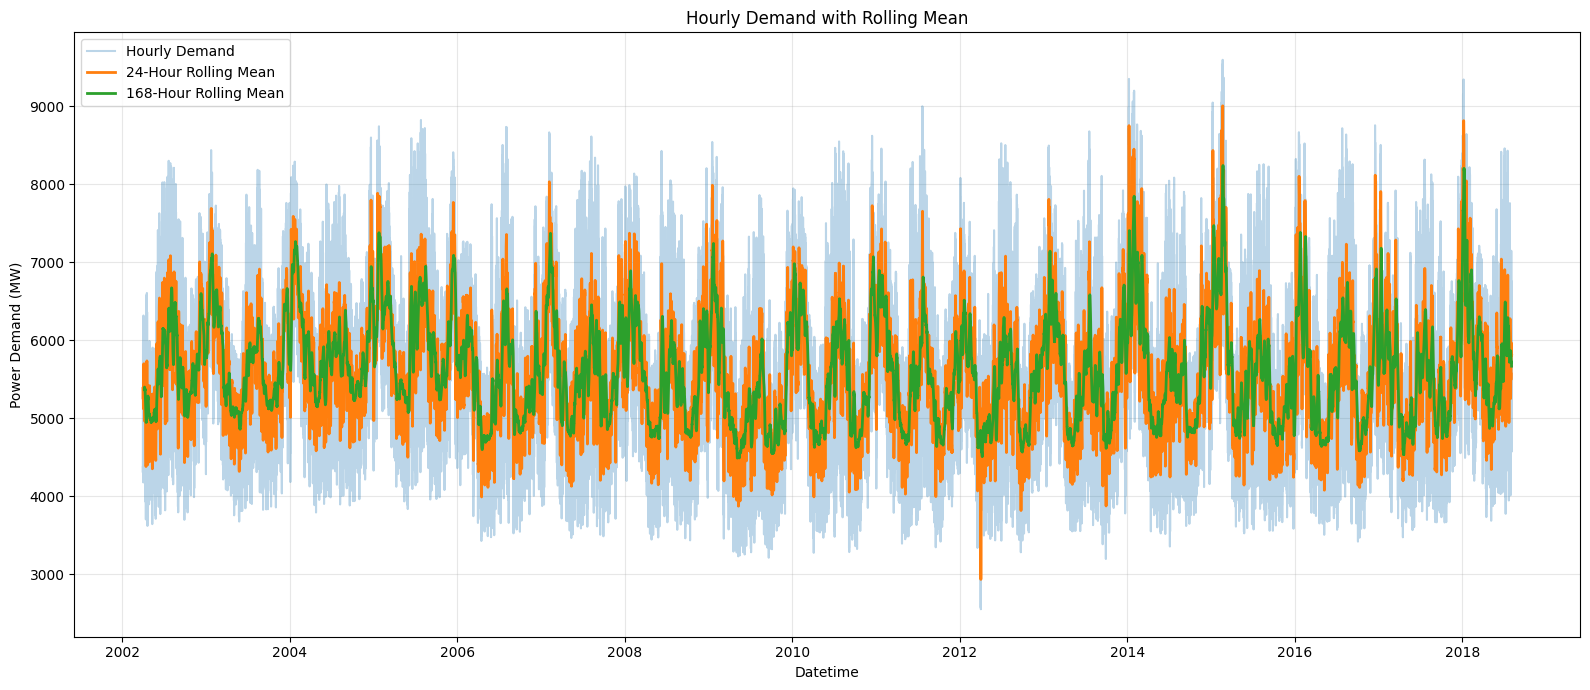

In [171]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 7))

plt.plot(
    df["Datetime"],
    df["PJMW_MW_Clean"],
    alpha=0.3,
    label="Hourly Demand"
)

plt.plot(
    df["Datetime"],
    df["Rolling_Mean_24"],
    linewidth=2,
    label="24-Hour Rolling Mean"
)

plt.plot(
    df["Datetime"],
    df["Rolling_Mean_168"],
    linewidth=2,
    label="168-Hour Rolling Mean"
)

plt.title("Hourly Demand with Rolling Mean")
plt.xlabel("Datetime")
plt.ylabel("Power Demand (MW)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Volatility 24 vs 168 comparision 

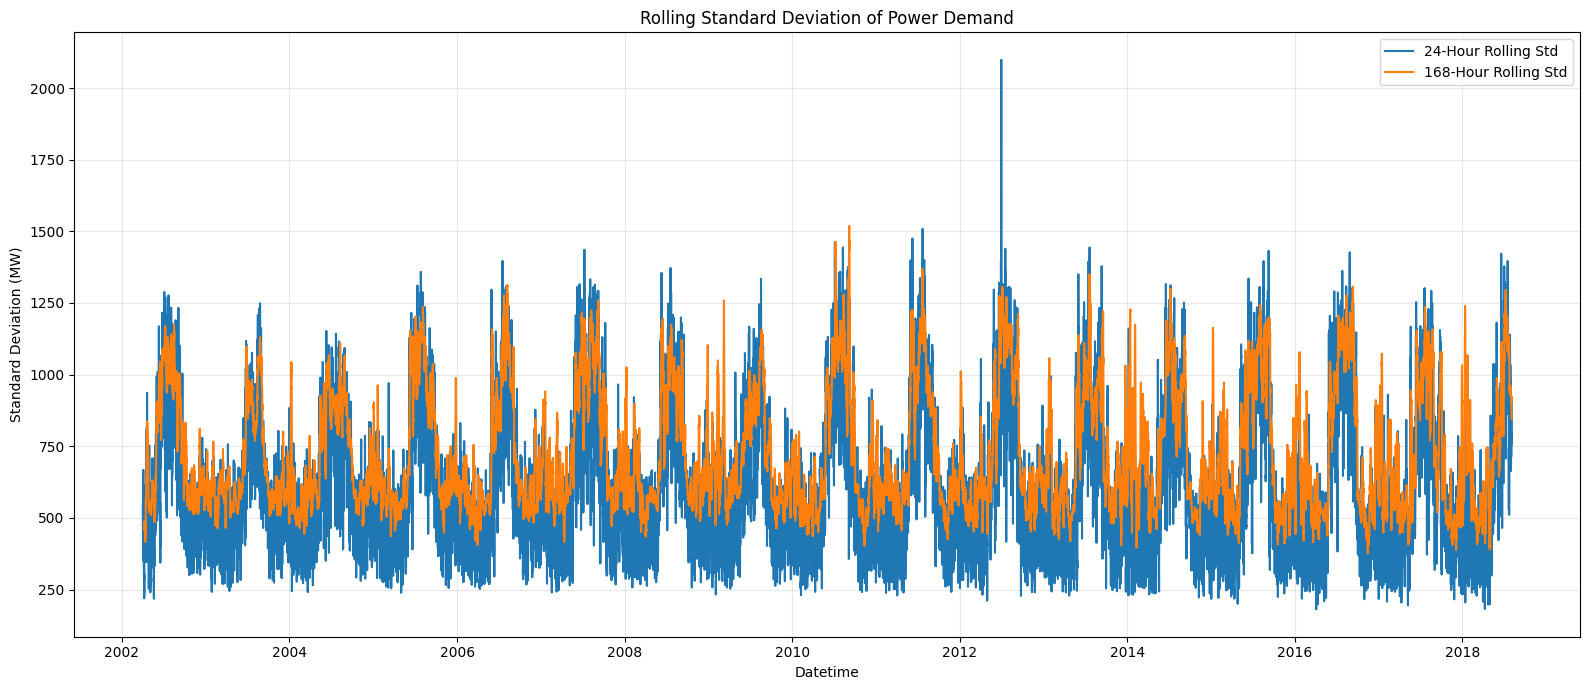

In [173]:
plt.figure(figsize=(16, 7))

plt.plot(
    df["Datetime"],
    df["Rolling_Std_24"],
    label="24-Hour Rolling Std"
)

plt.plot(
    df["Datetime"],
    df["Rolling_Std_168"],
    label="168-Hour Rolling Std"
)

plt.title("Rolling Standard Deviation of Power Demand")
plt.xlabel("Datetime")
plt.ylabel("Standard Deviation (MW)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Ploting Rolling Mean & Standard deviation for year 2013 

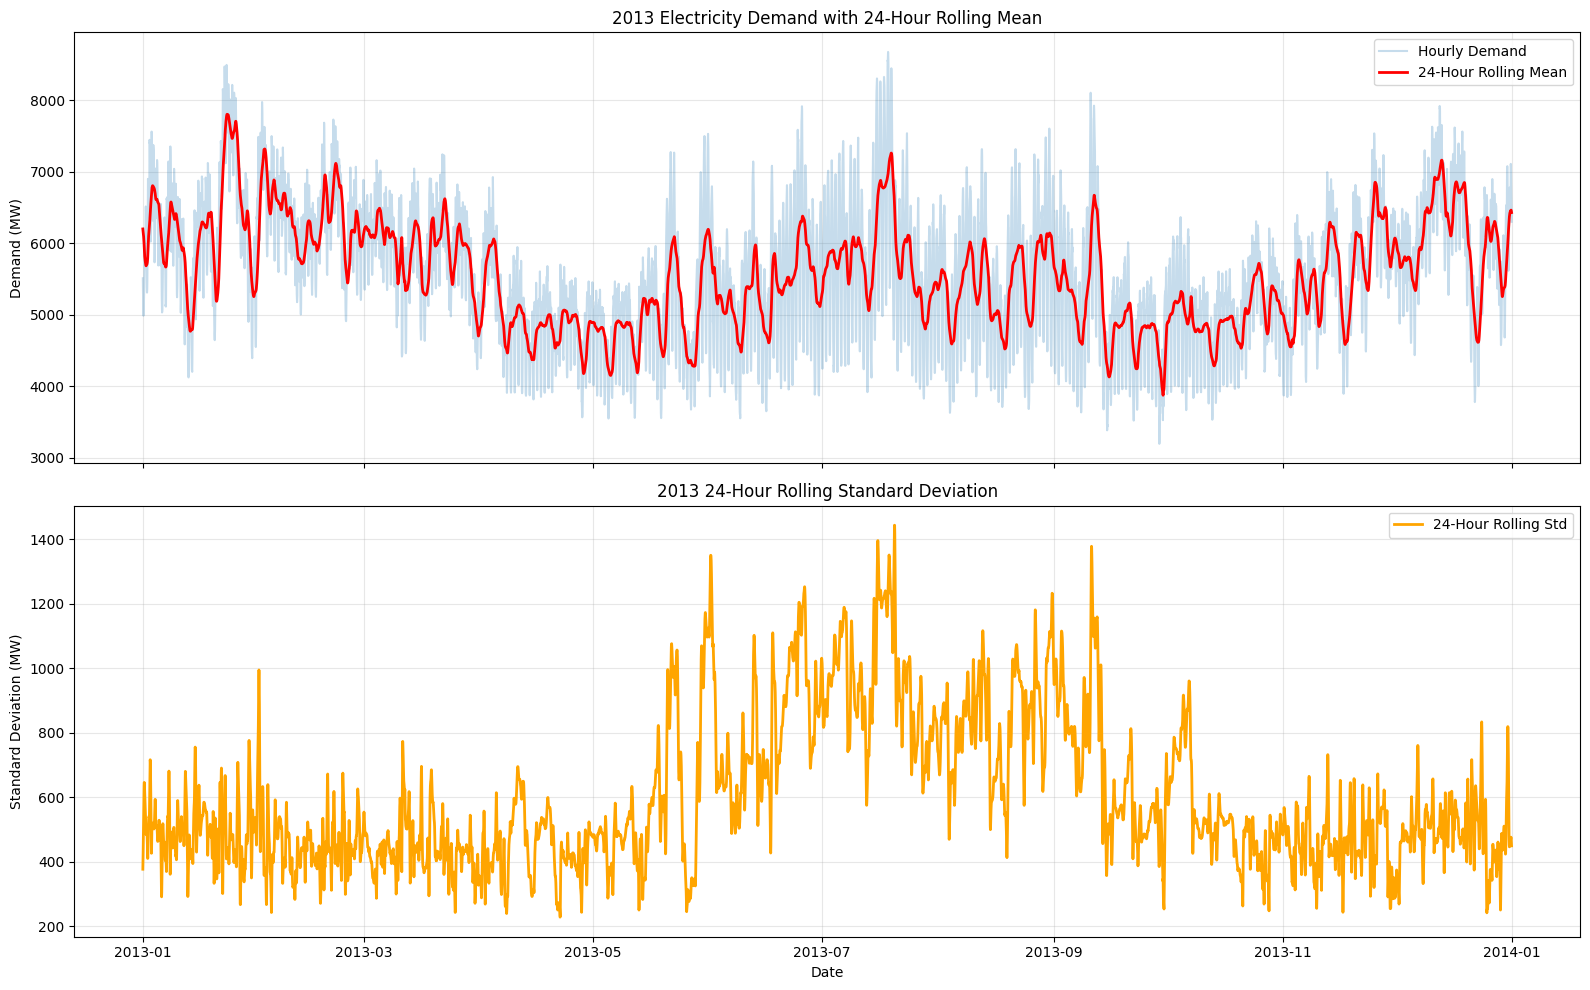

In [175]:
# 2013 - 24-HOUR ROLLING MEAN AND STANDARD DEVIATION

df_2013 = df[df["Year"] == 2013].copy()

fig, axes = plt.subplots(
    2, 1,
    figsize=(16, 10),
    sharex=True
)

# ------------------------------------------------------------
# Rolling Mean
# ------------------------------------------------------------

axes[0].plot(
    df_2013["Datetime"],
    df_2013["PJMW_MW_Clean"],
    alpha=0.25,
    label="Hourly Demand"
)

axes[0].plot(
    df_2013["Datetime"],
    df_2013["Rolling_Mean_24"],
    linewidth=2,
    color="red",
    label="24-Hour Rolling Mean"
)

axes[0].set_title(
    "2013 Electricity Demand with 24-Hour Rolling Mean"
)

axes[0].set_ylabel("Demand (MW)")
axes[0].legend()
axes[0].grid(alpha=0.3)


# ------------------------------------------------------------
# Rolling Standard Deviation
# ------------------------------------------------------------

axes[1].plot(
    df_2013["Datetime"],
    df_2013["Rolling_Std_24"],
    linewidth=2,
    color="orange",
    label="24-Hour Rolling Std"
)

axes[1].set_title(
    "2013 24-Hour Rolling Standard Deviation"
)

axes[1].set_xlabel("Date")
axes[1].set_ylabel("Standard Deviation (MW)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### ADF test — Augmented Dickey-Fuller

In [177]:
from statsmodels.tsa.stattools import adfuller

In [178]:
# ============================================================
# AUGMENTED DICKEY-FULLER (ADF) TEST
# ============================================================

adf_result = adfuller(df["PJMW_MW_Clean"].dropna())

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -19.903258030986628
p-value: 0.0

Critical Values:
1%: -3.4303956880172164
5%: -2.8615601934548742
10%: -2.5667807482577287


H0 -> Evidence that the series is non-stationary  

p-value < 0.05 => Reject H0 => Evidence that the series is stationary

# Rolling Features & Stationarity — Key Findings

## Rolling Feature NaN Values

* Initial NaN values are **expected**.
* `Rolling_Mean_24` and `Rolling_Std_24` require 24 previous observations.
* `Rolling_Mean_168` and `Rolling_Std_168` require 168 previous observations.
* Therefore, the beginning of the dataset cannot have valid rolling values.

### Decision

* Do **not** interpolate these NaN values.
* Do **not** fill them with `0` or the mean.
* Do **not** treat them as actual missing demand values.
* Keep the complete dataset unchanged during EDA.
* When creating a specific modeling dataset that uses these rolling features, remove only the rows where the required rolling features are unavailable.

---

## Stationarity Analysis

### Augmented Dickey-Fuller (ADF) Test

* ADF Statistic: **-19.9044**
* p-value: **< 0.001**
* 1% Critical Value: **-3.4304**
* 5% Critical Value: **-2.8616**
* 10% Critical Value: **-2.5668**

### Interpretation

* The ADF statistic is much lower (more negative) than the critical values.
* The p-value is below 0.05.
* Therefore, the null hypothesis of a unit root is rejected.
* The test provides **strong evidence that the cleaned PJM demand series is stationary according to the ADF test**.
* Differencing is **not required at this stage** based on the ADF result.
* Stationarity does **not** mean that the dataset has no seasonality, weekly patterns, daily patterns, or holiday effects.

---


________________

### Final EDA summary table

In [183]:
# FINAL EDA SUMMARY

overall_mean = df["PJMW_MW_Clean"].mean()

summary = {
    "Total Observations": len(df),

    "Start Date": df["Datetime"].min(),

    "End Date": df["Datetime"].max(),

    "Average Demand (MW)": round(
        df["PJMW_MW_Clean"].mean(),
        2
    ),

    "Median Demand (MW)": round(
        df["PJMW_MW_Clean"].median(),
        2
    ),

    "Minimum Demand (MW)": round(
        df["PJMW_MW_Clean"].min(),
        2
    ),

    "Maximum Demand (MW)": round(
        df["PJMW_MW_Clean"].max(),
        2
    ),

    "Standard Deviation (MW)": round(
        df["PJMW_MW_Clean"].std(),
        2
    )
}

summary_df = pd.DataFrame(
    summary.items(),
    columns=["Metric", "Value"]
)

display(summary_df)

,Metric,Value
0,Total Observations,143207
1,Start Date,2002-04-01 01:00:00
2,End Date,2018-08-03 00:00:00
3,Average Demand (MW),5602.41
4,Median Demand (MW),5530.0
5,Minimum Demand (MW),2553.0
6,Maximum Demand (MW),9594.0
7,Standard Deviation (MW),979.05


PRINT BUSINESS FINDINGS

In [185]:
# BUSINESS INSIGHT NUMBERS

# Overall average
overall = df["PJMW_MW_Clean"].mean()

# Highest season
highest_season = (
    seasonal_demand["Mean"]
    .idxmax()
)

highest_season_value = (
    seasonal_demand["Mean"]
    .max()
)

# Lowest season
lowest_season = (
    seasonal_demand["Mean"]
    .idxmin()
)

lowest_season_value = (
    seasonal_demand["Mean"]
    .min()
)

# Peak hour
peak_hour = hourly_demand.idxmax()
peak_hour_value = hourly_demand.max()

# Lowest hour
low_hour = hourly_demand.idxmin()
low_hour_value = hourly_demand.min()

# Highest weekday
highest_day = daily_demand.idxmax()

In [186]:
day_of_week_average = (
    df
    .groupby("Day_Name")["PJMW_MW_Clean"]
    .mean()
    .reindex(day_order)
)

highest_day_name = (
    day_of_week_average.idxmax()
)

highest_day_value = (
    day_of_week_average.max()
)

lowest_day_name = (
    day_of_week_average.idxmin()
)

lowest_day_value = (
    day_of_week_average.min()
)

In [187]:
# PRINT BUSINESS FINDINGS

print("=" * 60)
print("BUSINESS INSIGHTS")
print("=" * 60)

print(
    f"\nOverall average demand: "
    f"{overall:,.2f} MW"
)

print(
    f"\nHighest-demand season: "
    f"{highest_season} "
    f"({highest_season_value:,.2f} MW)"
)

print(
    f"Lowest-demand season: "
    f"{lowest_season} "
    f"({lowest_season_value:,.2f} MW)"
)

print(
    f"\nPeak average hour: "
    f"{peak_hour}:00 "
    f"({peak_hour_value:,.2f} MW)"
)

print(
    f"Lowest average hour: "
    f"{low_hour}:00 "
    f"({low_hour_value:,.2f} MW)"
)

print(
    f"\nHighest-demand day of week: "
    f"{highest_day_name} "
    f"({highest_day_value:,.2f} MW)"
)

print(
    f"Lowest-demand day of week: "
    f"{lowest_day_name} "
    f"({lowest_day_value:,.2f} MW)"
)

print("=" * 60)

BUSINESS INSIGHTS

Overall average demand: 5,602.41 MW

Highest-demand season: Winter (6,268.82 MW)
Lowest-demand season: Fall (5,200.14 MW)

Peak average hour: 19:00 (6,199.29 MW)
Lowest average hour: 4:00 (4,672.54 MW)

Highest-demand day of week: Wednesday (5,802.37 MW)
Lowest-demand day of week: Sunday (5,149.64 MW)


## EDA GRAPHS - Hour, Season , Day, Month 

In [189]:
# # MAIN EDA GRAPHS


# fig, axes = plt.subplots(
#     2,
#     2,
#     figsize=(16, 10)
# )

# # ------------------------------------------------------------
# # Graph 1: Hourly
# # ------------------------------------------------------------

# axes[0, 0].plot(
#     hourly_demand.index,
#     hourly_demand.values,
#     marker="o"
# )

# axes[0, 0].set_title(
#     "Average Demand by Hour"
# )

# axes[0, 0].set_xlabel("Hour")
# axes[0, 0].set_ylabel("Demand (MW)")


# # ------------------------------------------------------------
# # Graph 2: Season
# # ------------------------------------------------------------

# axes[0, 1].bar(
#     seasonal_demand.index,
#     seasonal_demand["Mean"]
# )

# axes[0, 1].set_title(
#     "Average Demand by Season"
# )

# axes[0, 1].set_xlabel("Season")
# axes[0, 1].set_ylabel("Demand (MW)")


# # ------------------------------------------------------------
# # Graph 3: Day of week
# # ------------------------------------------------------------

# axes[1, 0].bar(
#     day_of_week_average.index,
#     day_of_week_average.values
# )

# axes[1, 0].set_title(
#     "Average Demand by Day of Week"
# )

# axes[1, 0].set_xlabel("Day")
# axes[1, 0].set_ylabel("Demand (MW)")

# axes[1, 0].tick_params(
#     axis="x",
#     rotation=30
# )


# # ------------------------------------------------------------
# # Graph 4: Monthly
# # ------------------------------------------------------------

# axes[1, 1].plot(
#     monthly_demand.index,
#     monthly_demand.values,
#     marker="o"
# )

# axes[1, 1].set_title(
#     "Average Demand by Month"
# )

# axes[1, 1].set_xlabel("Month")
# axes[1, 1].set_ylabel("Demand (MW)")


# plt.tight_layout()
# plt.show()

# Thank you !!!

____

In [193]:
# ============================================================
# 6. CHECK CORRELATIONS / REDUNDANT FEATURES
# ============================================================

# Select numeric columns
numeric_cols = df.select_dtypes(include="number").columns

# Correlation with the target
correlation_with_target = (
    df[numeric_cols]
    .corr()["PJMW_MW_Clean"]
    .sort_values(ascending=False)
)

display(correlation_with_target)

PJMW_MW_Clean       1.000000
PJMW_MW_Capped      0.999987
PJMW_MW             0.999928
Rolling_Mean_24     0.723249
Rolling_Mean_168    0.584000
Hour                0.447210
Rolling_Std_24      0.167935
Rolling_Std_168     0.156336
Time_Difference     0.000391
Day                -0.006129
Is_Holiday         -0.012169
Year               -0.046985
DayOfYear          -0.150924
WeekOfYear         -0.151616
Month              -0.152426
Quarter            -0.159961
DayOfWeek          -0.202873
Is_Weekend         -0.245641
Name: PJMW_MW_Clean, dtype: float64

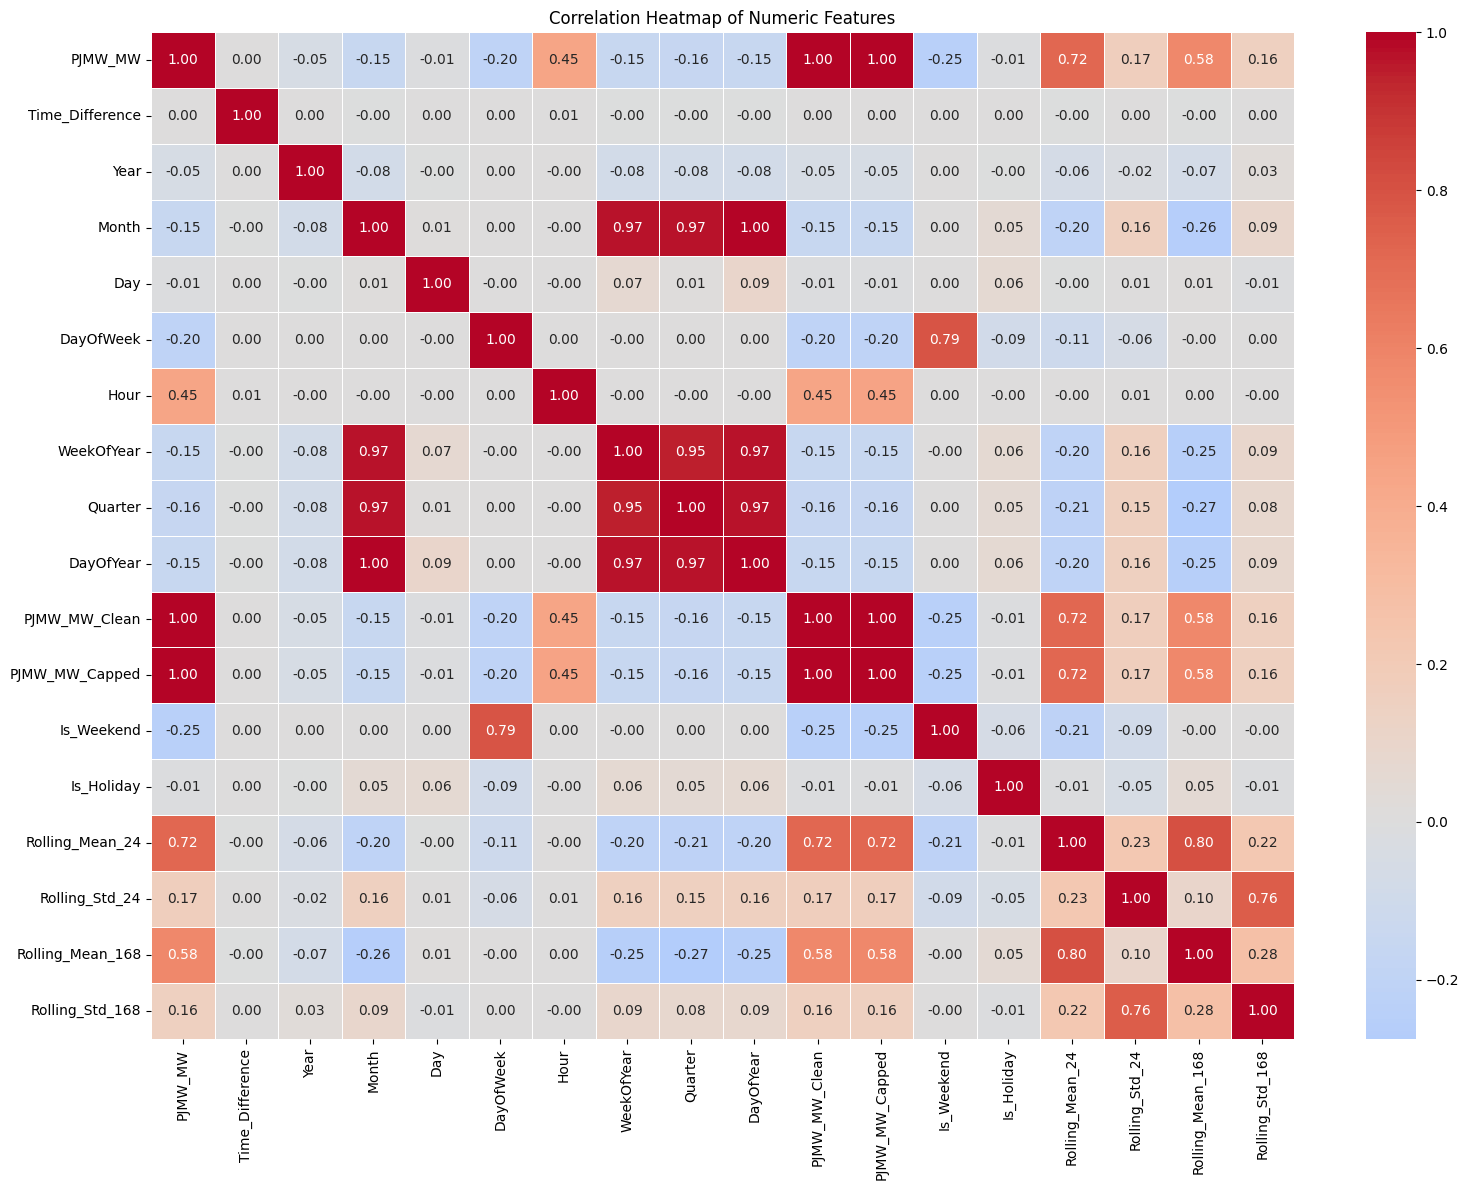

In [194]:
# ============================================================
# CORRELATION HEATMAP
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric columns
numeric_cols = df.select_dtypes(include="number").columns

# Correlation matrix
corr_matrix = df[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

<!-- Good. The output shows the features are clean and have no missing values. I would **not keep all of them**, because several are duplicate representations of the same time information.

### Step 8 — Recommended feature handling

**Keep:**

* `Year`
* `Month`
* `Day`
* `DayOfWeek`
* `Hour`
* `WeekOfYear`
* `DayOfYear`
* `Is_Weekend`
* `Is_Holiday`
* `Rolling_Mean_24`
* `Rolling_Std_24`
* `Rolling_Mean_168`
* `Rolling_Std_168`

**Remove/redundant later:**

* `Month_Name` → duplicate of `Month`
* `Day_Name` → duplicate of `DayOfWeek`
* `Season` → largely represented by `Month`
* `Day_Type` → duplicate of `Is_Weekend`
* `Holiday_Name` → overlaps with `Is_Holiday`; the name may be useful if you specifically want different holiday effects, but I'd initially leave it out.
* `Quarter` → largely redundant with `Month`

**Important:** `Year` can be useful because demand patterns can change over the 2002–2018 period.

Also, **don't delete these columns yet**. We'll create the final `feature_cols` list after the lag features are added.

### One correction before Step 9

Your current `Hour` values show `0–23`, which is good. However, because you have DST duplicate local hours, **`Datetime` itself remains the safest source for chronological ordering**. We should not try to "fix" the four legitimate DST duplicate timestamps by deleting observations.

### Next

We're ready for **Step 9: proper lag features**.

This is particularly important for forecasting because features like:

* `Lag_1` → previous hour's demand
* `Lag_24` → demand 24 hours ago
* `Lag_168` → demand 7 days ago

give the model direct historical demand information **without looking into the future**.

If you want, I'll give you the Step 9 code next. -->


____

### Creating Lag

Lag = "What was the demand at a specific previous time?" \
Rolling = "What was the average/variability over a previous period?"

In [199]:
# ============================================================
# 9. CREATE LAG FEATURES
# ============================================================

# Make sure data is chronologically ordered
df = df.sort_values("Datetime").reset_index(drop=True)

# Create demand lags
df["Lag_1"] = df["PJMW_MW_Clean"].shift(1)      # previous observation
df["Lag_24"] = df["PJMW_MW_Clean"].shift(24)    # previous ~24 hours
df["Lag_168"] = df["PJMW_MW_Clean"].shift(168)  # previous ~7 days

# Check the first rows                                                                                  
display(
    df[
        [
            "Datetime",
            "PJMW_MW_Clean",
            "Lag_1",
            "Lag_24",
            "Lag_168"
        ]
    ].head(180)
)

,Datetime,PJMW_MW_Clean,Lag_1,Lag_24,Lag_168
0,2002-04-01 01:00:00,4374.0,NaN,NaN,NaN
1,2002-04-01 02:00:00,4306.0,4374.0,NaN,NaN
2,2002-04-01 03:00:00,4322.0,4306.0,NaN,NaN
3,2002-04-01 04:00:00,4359.0,4322.0,NaN,NaN
4,2002-04-01 05:00:00,4436.0,4359.0,NaN,NaN
...,...,...,...,...,...
175,2002-04-08 09:00:00,5848.0,5820.0,5347.0,5482.0
176,2002-04-08 10:00:00,5837.0,5848.0,5337.0,5616.0
177,2002-04-08 11:00:00,5792.0,5837.0,5283.0,5722.0
178,2002-04-08 12:00:00,5706.0,5792.0,5165.0,5783.0


In [200]:
# ============================================================
# VERIFY LAG FEATURES
# ============================================================

print("Lag_1 missing values:", df["Lag_1"].isna().sum())
print("Lag_24 missing values:", df["Lag_24"].isna().sum())
print("Lag_168 missing values:", df["Lag_168"].isna().sum())

print("\nFirst valid Lag_1:")
display(
    df[
        ["Datetime", "PJMW_MW_Clean", "Lag_1"]
    ].iloc[1:6]
)

print("\nFirst valid Lag_24:")
display(
    df[
        ["Datetime", "PJMW_MW_Clean", "Lag_24"]
    ].iloc[24:29]
)

print("\nFirst valid Lag_168:")
display(
    df[
        ["Datetime", "PJMW_MW_Clean", "Lag_168"]
    ].iloc[168:173]
)

Lag_1 missing values: 1
Lag_24 missing values: 24
Lag_168 missing values: 168

First valid Lag_1:


,Datetime,PJMW_MW_Clean,Lag_1
1,2002-04-01 02:00:00,4306.0,4374.0
2,2002-04-01 03:00:00,4322.0,4306.0
3,2002-04-01 04:00:00,4359.0,4322.0
4,2002-04-01 05:00:00,4436.0,4359.0
5,2002-04-01 06:00:00,4723.0,4436.0



First valid Lag_24:


,Datetime,PJMW_MW_Clean,Lag_24
24,2002-04-02 01:00:00,4873.0,4374.0
25,2002-04-02 02:00:00,4768.0,4306.0
26,2002-04-02 03:00:00,4713.0,4322.0
27,2002-04-02 04:00:00,4737.0,4359.0
28,2002-04-02 05:00:00,4809.0,4436.0



First valid Lag_168:


,Datetime,PJMW_MW_Clean,Lag_168
168,2002-04-08 02:00:00,4532.0,4374.0
169,2002-04-08 03:00:00,4481.0,4306.0
170,2002-04-08 04:00:00,4527.0,4322.0
171,2002-04-08 05:00:00,4640.0,4359.0
172,2002-04-08 06:00:00,4940.0,4436.0


| Period            | Purpose                    |
| ----------------- | -------------------------- |
| **2002–2016**     | Training                   |
| **2017**          | Test/evaluation year       |
| **2018 Jan 1–30** | 30-day forecast evaluation |


Exactly. We have now fixed the experimental design:

Training: 2002–2016
Test/evaluation: 2017
30-day forecast evaluation: January 1–30, 2018
Target: PJMW_MW_Clean
Lag features: Lag_1, Lag_24, Lag_168
Rolling features: the four corrected, shifted rolling features
We will not use PJMW_MW_Scaled yet because scaling must be fitted using training data only.

___

## Creating TIme_Index column -> time_index

In [205]:
# Create a unique sequential index for every observation
df["time_index"] = range(len(df))

# Check that it is unique
print("Unique time_index:", df["time_index"].is_unique)

# Check duplicate Datetime values
print("Duplicate Datetime rows:", df["Datetime"].duplicated(keep=False).sum())

Unique time_index: True
Duplicate Datetime rows: 8


In [206]:
# df = df.sort_values("Datetime").reset_index(drop=True)
# df["Time_Index"] = range(len(df))

In [207]:
# df

| EDA                                      | Major Highlight                                                                                                                                          |
| ---------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **1. Duplicate Datetime / DST**          | Identified valid **DST-related duplicate timestamps**; these were retained because they represent genuine repeated hours.                                |
| **2. Rolling Statistics + Stationarity** | Rolling features captured **short-term and weekly demand behavior**, while the ADF test indicated the demand series is **stationary**.                   |
| **3. Time Gaps / Missing Timestamps**    | Identified **one genuine missing timestamp**, which was interpolated; remaining time gaps were confirmed as **DST-related**.                             |
| **4. Outlier Analysis**                  | High-demand peaks were investigated contextually instead of blindly removing IQR outliers; **genuine peak-demand observations were retained**.           |
| **5. Lag Features**                      | Created **1-hour, 24-hour and 168-hour lag features**, capturing immediate, daily and weekly demand dependencies.                                        |
| **6. Descriptive Statistics**            | Average demand was **5,602 MW**, ranging from **2,553 to 9,594 MW**, showing significant demand variability.                                             |
| **7. Correlation Analysis**              | Strongest relationship was with **Lag-1 (0.975)**, followed by **Lag-24 (0.877)** and **Lag-168 (0.759)**, confirming strong historical dependence.      |
| **8. ACF/PACF / Autocorrelation**        | Confirmed strong **hourly, daily and weekly patterns**, supporting time-series and lag-based forecasting approaches.                                     |
| **9. Time-Series Visualization**         | Visual analysis confirmed clear **daily, weekly and seasonal demand patterns**, including recurring peak-demand periods.                                 |
| **10. Business Insights**                | **Winter has the highest demand (6,268.82 MW)**, **19:00 is the peak hour (6,199.29 MW)**, and **Wednesday has the highest daily demand (5,802.37 MW)**. |


Yes. **Step 10 is now verified and correct.** ✅

### What the output tells us

* ✅ **Training:** 129,311 rows — 2002–2016
* ✅ **Test:** 8,760 rows — full 2017
* ✅ **Forecast evaluation:** 720 rows — Jan 1–30, 2018
* ✅ Chronological separation is correct.
* ✅ `Time_Index` is correct: 0 → 143,206 with no duplicates.
* ✅ **17 model features** are now included.
* ✅ Target is correctly set to `PJMW_MW_Clean`.
* ✅ Test and forecast have **no missing feature values**.

### One issue we now need to handle

Only the **training set** has NaNs:

| Feature          | Missing |
| ---------------- | ------: |
| Rolling_Mean_24  |      23 |
| Rolling_Std_24   |      23 |
| Rolling_Mean_168 |     167 |
| Rolling_Std_168  |     167 |
| Lag_1            |       1 |
| Lag_24           |      24 |
| Lag_168          |     168 |

This is **expected** because these features require previous observations.

For example, `Lag_168` cannot exist for the first 168 observations.

**Do not fill these with 0 or mean values.** That could create artificial information for the model.

The clean approach is to remove the initial rows from the **training data only** where these features aren't available. The test and forecast sets are already complete.

So before scaling, our next step should be:

**Step 11 → handle these training NaNs + fit the scaler using training data only.**

And importantly, we'll also make sure the scaler does **not** use 2017 or 2018 information.


In [210]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143207 entries, 0 to 143206
Data columns (total 29 columns):
 #   Column            Non-Null Count   Dtype          
---  ------            --------------   -----          
 0   Datetime          143207 non-null  datetime64[ns] 
 1   PJMW_MW           143207 non-null  float64        
 2   Time_Difference   143205 non-null  timedelta64[ns]
 3   Year              143207 non-null  int32          
 4   Month             143207 non-null  int32          
 5   Month_Name        143207 non-null  object         
 6   Day               143207 non-null  int32          
 7   DayOfWeek         143207 non-null  int32          
 8   Day_Name          143207 non-null  object         
 9   Hour              143207 non-null  int32          
 10  WeekOfYear        143207 non-null  UInt32         
 11  Quarter           143207 non-null  int32          
 12  DayOfYear         143207 non-null  int32          
 13  PJMW_MW_Clean     143207 non-null  float64  

____

| Model          | Typical Inputs                          |
| -------------- | --------------------------------------- |
| Seasonal Naive | Historical demand                       |
| ARIMA          | Target time series                      |
| SARIMA         | Target + seasonal structure             |
| Holt-Winters   | Target + trend/seasonality              |
| Prophet        | Datetime + target + optional regressors |
| Random Forest  | Lag + calendar + rolling features       |
| XGBoost        | Lag + calendar + rolling features       |
| LightGBM       | Lag + calendar + rolling features       |
| LSTM           | Sequential lagged target/features       |


## UNIVERSAL TRAIN / VALIDATION / FINAL TEST SPLI

In [214]:
# ============================================================
# UNIVERSAL TRAIN / VALIDATION / FINAL TEST SPLIT
# P705 - Forecasting Power Supply Demand
# ============================================================

# Make sure data is sorted chronologically
df = df.sort_values("Datetime").reset_index(drop=True)

# ------------------------------------------------------------
# 1. Define the fixed dates
# ------------------------------------------------------------

TRAIN_START = "2002-04-01"
TRAIN_END   = "2016-08-02"

VAL_START   = "2016-08-03"
VAL_END     = "2017-08-02"

TEST_START  = "2017-08-03"
TEST_END    = "2018-08-03"

# Separate 30-day historical forecasting experiment
BACKTEST_30_START = "2018-07-01"
BACKTEST_30_END   = "2018-07-30"

# Dataset end / future forecast origin
FORECAST_ORIGIN = "2018-08-03"


# ------------------------------------------------------------
# 2. Create Training Dataset
# ------------------------------------------------------------

train_df = df[
    (df["Datetime"] >= TRAIN_START) &
    (df["Datetime"] <= TRAIN_END)
].copy()


# ------------------------------------------------------------
# 3. Create Validation Dataset
# ------------------------------------------------------------

val_df = df[
    (df["Datetime"] >= VAL_START) &
    (df["Datetime"] <= VAL_END)
].copy()


# ------------------------------------------------------------
# 4. Create Final Test Dataset
# ------------------------------------------------------------

test_df = df[
    (df["Datetime"] >= TEST_START) &
    (df["Datetime"] <= TEST_END)
].copy()


# ------------------------------------------------------------
# 5. Create Separate 30-Day Historical Backtest Dataset
# ------------------------------------------------------------

backtest_30_df = df[
    (df["Datetime"] >= BACKTEST_30_START) &
    (df["Datetime"] <= BACKTEST_30_END)
].copy()


# ------------------------------------------------------------
# 6. Display split information
# ------------------------------------------------------------

print("=" * 70)
print("UNIVERSAL DATA SPLIT")
print("=" * 70)

print("\nTraining Data:")
print("Start :", train_df["Datetime"].min())
print("End   :", train_df["Datetime"].max())
print("Rows  :", len(train_df))

print("\nValidation Data:")
print("Start :", val_df["Datetime"].min())
print("End   :", val_df["Datetime"].max())
print("Rows  :", len(val_df))

print("\nFinal Test / 1-Year Backtest:")
print("Start :", test_df["Datetime"].min())
print("End   :", test_df["Datetime"].max())
print("Rows  :", len(test_df))

print("\nSeparate 30-Day Historical Backtest:")
print("Start :", backtest_30_df["Datetime"].min())
print("End   :", backtest_30_df["Datetime"].max())
print("Rows  :", len(backtest_30_df))

print("\nFuture Forecast Origin:")
print(FORECAST_ORIGIN)

print("=" * 70)

UNIVERSAL DATA SPLIT

Training Data:
Start : 2002-04-01 01:00:00
End   : 2016-08-02 00:00:00
Rows  : 125663

Validation Data:
Start : 2016-08-03 00:00:00
End   : 2017-08-02 00:00:00
Rows  : 8737

Final Test / 1-Year Backtest:
Start : 2017-08-03 00:00:00
End   : 2018-08-03 00:00:00
Rows  : 8761

Separate 30-Day Historical Backtest:
Start : 2018-07-01 00:00:00
End   : 2018-07-30 00:00:00
Rows  : 697

Future Forecast Origin:
2018-08-03


## Validation checks
Protect from accidentally using the wrong dates later.

In [216]:
# ============================================================
# 7. SPLIT VALIDATION CHECKS
# ============================================================

# Check that each main split has data
assert len(train_df) > 0, "Training dataset is empty!"
assert len(val_df) > 0, "Validation dataset is empty!"
assert len(test_df) > 0, "Final test dataset is empty!"
assert len(backtest_30_df) > 0, "30-day backtest dataset is empty!"


# Check chronological ordering
assert train_df["Datetime"].max() < val_df["Datetime"].min(), \
    "Training and validation periods overlap!"

assert val_df["Datetime"].max() < test_df["Datetime"].min(), \
    "Validation and final test periods overlap!"


# Check final test ends at the dataset end
assert test_df["Datetime"].max() == df["Datetime"].max(), \
    "Final test does not reach the end of the available dataset!"


print("\nAll universal split checks passed successfully.")


All universal split checks passed successfully.


Final Model-Building Framework

11 model implementations if we treat Simple, Double and Triple Holt-Winters as separate models:

Seasonal Naive
ARIMA
SARIMA
Simple Exponential Smoothing
Holt / Double Exponential Smoothing
Holt-Winters / Triple Exponential Smoothing
Random Forest
XGBoost
LightGBM
LSTM
Prophet

I would modify your workflow slightly to this:

Phase 1 — Train/Test Split & Forecasting Strategy
Phase 2 — Model-Specific Data Preparation
Phase 3 — Baseline Model Training
Phase 4 — Last 1-Year Backtesting
Phase 5 — Next 30-Day Forecast
Phase 6 — Actual vs Predicted Analysis
Phase 7 — Model Evaluation
Phase 8 — Fine-Tuning
Phase 9 — Before vs After Fine-Tuning Comparison
Phase 10 — Visualization
Phase 11 — DST & Time-Gap Validation
Phase 12 — Model Diagnostics & Business Interpretation
Phase 13 — Final Model Decision

Your original 12 steps are therefore good; I've mainly reorganized them so that the process is cleaner.

# Model 1

# Seasonal Naive

Phase 1 — Train/Test Split & Forecasting Strategy

In [222]:
# ============================================================
# SEASONAL NAIVE — PHASE 1
# Train / Validation / Test Split
# ============================================================

df = df.sort_values("Datetime").reset_index(drop=True)

# Fixed split dates
train_start, train_end = "2002-04-01", "2016-08-02"
val_start, val_end = "2016-08-03", "2017-08-02"
test_start, test_end = "2017-08-03", "2018-08-03"

# Separate 30-day historical backtest
backtest_start, backtest_end = "2018-07-01", "2018-07-30"

# Split data
seasonal_naive_train = df[
    df["Datetime"].between(train_start, train_end)
].copy()

seasonal_naive_val = df[
    df["Datetime"].between(val_start, val_end)
].copy()

seasonal_naive_test = df[
    df["Datetime"].between(test_start, test_end)
].copy()

seasonal_naive_backtest_30 = df[
    df["Datetime"].between(backtest_start, backtest_end)
].copy()

# Seasonal period: 168 hours = 1 week
seasonal_period = 168

# Basic checks
assert len(seasonal_naive_train) > 0
assert len(seasonal_naive_val) > 0
assert len(seasonal_naive_test) > 0
assert len(seasonal_naive_backtest_30) > 0

assert seasonal_naive_train["Datetime"].max() < seasonal_naive_val["Datetime"].min()
assert seasonal_naive_val["Datetime"].max() < seasonal_naive_test["Datetime"].min()

print("Train      :", seasonal_naive_train["Datetime"].min(), "→", seasonal_naive_train["Datetime"].max(), "| Rows:", len(seasonal_naive_train))
print("Validation :", seasonal_naive_val["Datetime"].min(), "→", seasonal_naive_val["Datetime"].max(), "| Rows:", len(seasonal_naive_val))
print("Final Test :", seasonal_naive_test["Datetime"].min(), "→", seasonal_naive_test["Datetime"].max(), "| Rows:", len(seasonal_naive_test))
print("30-Day BT  :", seasonal_naive_backtest_30["Datetime"].min(), "→", seasonal_naive_backtest_30["Datetime"].max(), "| Rows:", len(seasonal_naive_backtest_30))
print("Seasonal Period:", seasonal_period, "hours")

Train      : 2002-04-01 01:00:00 → 2016-08-02 00:00:00 | Rows: 125663
Validation : 2016-08-03 00:00:00 → 2017-08-02 00:00:00 | Rows: 8737
Final Test : 2017-08-03 00:00:00 → 2018-08-03 00:00:00 | Rows: 8761
30-Day BT  : 2018-07-01 00:00:00 → 2018-07-30 00:00:00 | Rows: 697
Seasonal Period: 168 hours


In [223]:
# ============================================================
# SEASONAL NAIVE — PHASE 2
# Model-Specific Data Preparation
# ============================================================

target = "PJMW_MW_Clean"
seasonal_period = 168

# Target series
y_train = seasonal_naive_train[target].copy()
y_val = seasonal_naive_val[target].copy()
y_test = seasonal_naive_test[target].copy()

# 30-day historical backtest
y_backtest_30 = seasonal_naive_backtest_30[target].copy()

# No scaling required
scaler = None

print("Target:", target)
print("Seasonal period:", seasonal_period, "hours")
print("Scaling: Not required")

print("\nTrain:", len(y_train))
print("Validation:", len(y_val))
print("Final Test:", len(y_test))
print("30-Day Backtest:", len(y_backtest_30))

print("\nMissing values:")
print("Train:", y_train.isna().sum())
print("Validation:", y_val.isna().sum())
print("Test:", y_test.isna().sum())
print("30-Day Backtest:", y_backtest_30.isna().sum())

Target: PJMW_MW_Clean
Seasonal period: 168 hours
Scaling: Not required

Train: 125663
Validation: 8737
Final Test: 8761
30-Day Backtest: 697

Missing values:
Train: 0
Validation: 0
Test: 0
30-Day Backtest: 0


### Observation — Phase 2: Model-Specific Data Preparation

- `PJMW_MW_Clean` is used as the target variable for Seasonal Naive.
- No scaling is required because Seasonal Naive directly uses historical demand values.
- A seasonal period of 168 hours (7 days) is used to capture weekly demand patterns.
- Training, validation, final-test, and 30-day backtest datasets contain no missing target values.
- The data is therefore ready for Seasonal Naive baseline training.

Seasonal Naive — Phase 3: Baseline Model Training

In [226]:
# ============================================================
# SEASONAL NAIVE — PHASE 3
# Baseline Model Training
# ============================================================

# Combine train + validation so previous 168 observations
# are available when predicting the validation period
train_val = pd.concat(
    [seasonal_naive_train, seasonal_naive_val]
).sort_values("Datetime").reset_index(drop=True)

# Seasonal Naive prediction
train_val["Seasonal_Naive_Pred"] = (
    train_val[target].shift(seasonal_period)
)

# Keep only validation predictions
seasonal_naive_val_pred = train_val[
    train_val["Datetime"].between(val_start, val_end)
].copy()

# Check predictions
print("Validation observations :", len(seasonal_naive_val_pred))
print("Actual values           :", seasonal_naive_val_pred[target].notna().sum())
print("Predicted values        :", seasonal_naive_val_pred["Seasonal_Naive_Pred"].notna().sum())

print("\nSample predictions:")
print(
    seasonal_naive_val_pred[
        ["Datetime", target, "Seasonal_Naive_Pred"]
    ].head(10)
)

Validation observations : 8737
Actual values           : 8737
Predicted values        : 8737

Sample predictions:
                  Datetime  PJMW_MW_Clean  Seasonal_Naive_Pred
125663 2016-08-03 00:00:00         5780.0               5845.0
125664 2016-08-03 01:00:00         5348.0               5521.0
125665 2016-08-03 02:00:00         5091.0               5321.0
125666 2016-08-03 03:00:00         4878.0               5151.0
125667 2016-08-03 04:00:00         4765.0               5120.0
125668 2016-08-03 05:00:00         4743.0               5288.0
125669 2016-08-03 06:00:00         4998.0               5588.0
125670 2016-08-03 07:00:00         5164.0               6015.0
125671 2016-08-03 08:00:00         5476.0               6341.0
125672 2016-08-03 09:00:00         5787.0               6740.0


### Observation — Phase 3: Baseline Model Training

- Seasonal Naive successfully generated predictions for all 8,737 validation observations.
- No missing predictions were produced.
- The baseline uses the demand from the previous 168-hour period (previous week) as the forecast.
- The sample shows noticeable differences between actual and predicted demand, which we will quantify during model evaluation.

Seasonal Naive — Phase 4: Last 1-Year Backtesting

In [229]:
# ============================================================
# SEASONAL NAIVE — PHASE 4
# Last 1-Year Backtesting
# ============================================================

# Combine data needed for the final test period
train_val_test = pd.concat(
    [seasonal_naive_train, seasonal_naive_val, seasonal_naive_test]
).sort_values("Datetime").reset_index(drop=True)

# Generate Seasonal Naive predictions
train_val_test["Seasonal_Naive_Pred"] = (
    train_val_test[target].shift(seasonal_period)
)

# Extract final 1-year test period
seasonal_naive_test_pred = train_val_test[
    train_val_test["Datetime"].between(test_start, test_end)
].copy()

# Check results
print("Test observations :", len(seasonal_naive_test_pred))
print("Actual values     :", seasonal_naive_test_pred[target].notna().sum())
print("Predicted values  :", seasonal_naive_test_pred["Seasonal_Naive_Pred"].notna().sum())

print("\nSample predictions:")
print(
    seasonal_naive_test_pred[
        ["Datetime", target, "Seasonal_Naive_Pred"]
    ].head(10)
)

Test observations : 8761
Actual values     : 8761
Predicted values  : 8761

Sample predictions:
                  Datetime  PJMW_MW_Clean  Seasonal_Naive_Pred
134400 2017-08-03 00:00:00         5591.0               4749.0
134401 2017-08-03 01:00:00         5170.0               4446.0
134402 2017-08-03 02:00:00         4948.0               4310.0
134403 2017-08-03 03:00:00         4700.0               4299.0
134404 2017-08-03 04:00:00         4606.0               4259.0
134405 2017-08-03 05:00:00         4580.0               4460.0
134406 2017-08-03 06:00:00         4797.0               4719.0
134407 2017-08-03 07:00:00         5030.0               4975.0
134408 2017-08-03 08:00:00         5322.0               5206.0
134409 2017-08-03 09:00:00         5602.0               5440.0


Seasonal Naive — Phase 5: Next 30-Day Forecast => 2018-07-01 → 2018-07-30

In [231]:
# ============================================================
# SEASONAL NAIVE — PHASE 5
# 30-Day Historical Forecast
# ============================================================

# Use data before the 30-day forecast period
forecast_history = df[
    df["Datetime"] < BACKTEST_30_START
].copy()

# Add Seasonal Naive predictions
forecast_history["Seasonal_Naive_Pred"] = (
    forecast_history[target].shift(seasonal_period)
)

# Get the 30-day forecast period
seasonal_naive_30_pred = df[
    df["Datetime"].between(BACKTEST_30_START, BACKTEST_30_END)
].copy()

# Match predictions using the previous 168 observations
seasonal_naive_30_pred["Seasonal_Naive_Pred"] = (
    df[target]
    .shift(seasonal_period)
    .loc[seasonal_naive_30_pred.index]
)

# Display results
print("30-Day observations :", len(seasonal_naive_30_pred))
print("Actual values       :", seasonal_naive_30_pred[target].notna().sum())
print("Predicted values    :", seasonal_naive_30_pred["Seasonal_Naive_Pred"].notna().sum())

print("\nSample predictions:")
print(
    seasonal_naive_30_pred[
        ["Datetime", target, "Seasonal_Naive_Pred"]
    ].head(10)
)

30-Day observations : 697
Actual values       : 697
Predicted values    : 697

Sample predictions:
                  Datetime  PJMW_MW_Clean  Seasonal_Naive_Pred
142414 2018-07-01 00:00:00         5819.0               4895.0
142415 2018-07-01 01:00:00         5368.0               4550.0
142416 2018-07-01 02:00:00         5038.0               4324.0
142417 2018-07-01 03:00:00         4768.0               4161.0
142418 2018-07-01 04:00:00         4591.0               4099.0
142419 2018-07-01 05:00:00         4410.0               4056.0
142420 2018-07-01 06:00:00         4399.0               4075.0
142421 2018-07-01 07:00:00         4381.0               4077.0
142422 2018-07-01 08:00:00         4765.0               4321.0
142423 2018-07-01 09:00:00         5313.0               4730.0


### Observation — Phase 5: 30-Day Historical Forecast

- Seasonal Naive generated predictions for all **697 observations** in the 30-day period.
- No missing actual or predicted values were found.
- The model uses the demand from the previous **168 observations (weekly pattern)** for forecasting.
- In the sample, actual demand is generally higher than the previous-week prediction, indicating noticeable week-to-week variation.
- The 30-day historical forecast is ready for direct actual-vs-predicted analysis.

SEASONAL NAIVE Phase 6 — Actual vs Predicted Analysis

In [234]:
# ============================================================
# SEASONAL NAIVE — PHASE 6
# Actual vs Predicted Analysis
# ============================================================

# Create comparison columns
seasonal_naive_30_pred["Error"] = (
    seasonal_naive_30_pred[target]
    - seasonal_naive_30_pred["Seasonal_Naive_Pred"]
)

seasonal_naive_30_pred["Absolute_Error"] = (
    seasonal_naive_30_pred["Error"].abs()
)

# Summary
print("Actual Mean    :", seasonal_naive_30_pred[target].mean())
print("Predicted Mean :", seasonal_naive_30_pred["Seasonal_Naive_Pred"].mean())
print("Mean Error     :", seasonal_naive_30_pred["Error"].mean())
print("Mean Abs Error :", seasonal_naive_30_pred["Absolute_Error"].mean())

# Sample comparison
print("\nActual vs Predicted:")
print(
    seasonal_naive_30_pred[
        [
            "Datetime",
            target,
            "Seasonal_Naive_Pred",
            "Error",
            "Absolute_Error"
        ]
    ].head(10)
)

Actual Mean    : 6005.238163558106
Predicted Mean : 5990.5222381635585
Mean Error     : 14.715925394548064
Mean Abs Error : 644.635581061693

Actual vs Predicted:
                  Datetime  PJMW_MW_Clean  Seasonal_Naive_Pred  Error  \
142414 2018-07-01 00:00:00         5819.0               4895.0  924.0   
142415 2018-07-01 01:00:00         5368.0               4550.0  818.0   
142416 2018-07-01 02:00:00         5038.0               4324.0  714.0   
142417 2018-07-01 03:00:00         4768.0               4161.0  607.0   
142418 2018-07-01 04:00:00         4591.0               4099.0  492.0   
142419 2018-07-01 05:00:00         4410.0               4056.0  354.0   
142420 2018-07-01 06:00:00         4399.0               4075.0  324.0   
142421 2018-07-01 07:00:00         4381.0               4077.0  304.0   
142422 2018-07-01 08:00:00         4765.0               4321.0  444.0   
142423 2018-07-01 09:00:00         5313.0               4730.0  583.0   

        Absolute_Error  
142414  

### Observation — Phase 6: Actual vs Predicted Analysis

- Actual average demand was **6,005.24 MW**, while predicted average demand was **5,990.52 MW**.
- The mean error was **+14.72 MW**, indicating very little overall bias.
- Mean Absolute Error was **644.64 MW**, showing that individual hourly predictions can still differ considerably from actual demand.
- The first few observations show the model generally **underpredicting demand** during this 30-day period.
- The Seasonal Naive model captures the overall weekly pattern reasonably well, but week-to-week demand changes are not fully captured.

Phase 7 — Model Evaluation

We will calculate the main forecasting metrics: MAE, RMSE, MAPE, and sMAPE for the 30-day historical backtest

In [237]:
# ============================================================
# SEASONAL NAIVE — PHASE 7
# Model Evaluation
# ============================================================

actual = seasonal_naive_30_pred[target]
predicted = seasonal_naive_30_pred["Seasonal_Naive_Pred"]

# MAE
mae = np.mean(np.abs(actual - predicted))

# RMSE
rmse = np.sqrt(np.mean((actual - predicted) ** 2))

# MAPE
mape = np.mean(
    np.abs((actual - predicted) / actual)
) * 100

# sMAPE
smape = np.mean(
    2 * np.abs(actual - predicted) /
    (np.abs(actual) + np.abs(predicted))
) * 100

print("Seasonal Naive — 30-Day Evaluation")
print("-----------------------------------")
print(f"MAE   : {mae:.2f} MW")
print(f"RMSE  : {rmse:.2f} MW")
print(f"MAPE  : {mape:.2f}%")

print(f"sMAPE : {smape:.2f}%")

Seasonal Naive — 30-Day Evaluation
-----------------------------------
MAE   : 644.64 MW
RMSE  : 811.79 MW
MAPE  : 10.69%
sMAPE : 10.64%


### Observation — Phase 7: Model Evaluation

- The model has an average absolute forecasting error of about **645 MW**.
- RMSE is higher than MAE, indicating some hourly forecasts have relatively larger errors.
- The MAPE and sMAPE are both around **10.6%**, providing a useful baseline for comparison with the other forecasting models.

Phase 8 — Fine-Tuning

For Seasonal Naive, there are no conventional hyperparameters to tune. The main parameter we can test is the seasonal period.

We will compare:

- 24 hours → daily pattern
- 168 hours → weekly pattern
- 336 hours → two-week pattern

We will use the validation period, not the final test period, to select the best seasonal period.

In [241]:
# ============================================================
# SEASONAL NAIVE — PHASE 8
# Fine-Tuning Seasonal Period
# ============================================================

seasonal_periods = [24, 168, 336]
results = []

for period in seasonal_periods:

    temp = pd.concat(
        [seasonal_naive_train, seasonal_naive_val]
    ).sort_values("Datetime").reset_index(drop=True)

    temp["Prediction"] = temp[target].shift(period)

    val_pred = temp[
        temp["Datetime"].between(val_start, val_end)
    ].dropna(subset=["Prediction"])

    actual = val_pred[target]
    predicted = val_pred["Prediction"]

    mae = np.mean(np.abs(actual - predicted))
    rmse = np.sqrt(np.mean((actual - predicted) ** 2))
    mape = np.mean(
        np.abs((actual - predicted) / actual)
    ) * 100

    results.append({
        "Seasonal_Period": period,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    })

tuning_results = pd.DataFrame(results)

print("Seasonal Naive Fine-Tuning Results")
print("----------------------------------")
print(tuning_results.to_string(index=False))

best_period = tuning_results.loc[
    tuning_results["MAE"].idxmin(),
    "Seasonal_Period"
]


print("\nBest Seasonal Period:", int(best_period), "hours")

Seasonal Naive Fine-Tuning Results
----------------------------------
 Seasonal_Period        MAE       RMSE      MAPE
              24 365.207623 488.238153  6.594454
             168 592.405059 779.088159 10.507963
             336 645.261646 861.182055 11.520596

Best Seasonal Period: 24 hours


### Observation — Phase 8: Fine-Tuning

- The **24-hour seasonal period** produced the lowest validation error.
- Therefore, the fine-tuned Seasonal Naive model uses **24 hours (daily seasonality)** instead of the original 168-hour weekly period.

Phase 9 — Before vs After Fine-Tuning Comparison

In [244]:
# # ============================================================
# # SEASONAL NAIVE — PHASE 9
# # Before vs After Fine-Tuning
# # ============================================================

# before = tuning_results[
#     tuning_results["Seasonal_Period"] == 168
# ].iloc[0]

# after = tuning_results[
#     tuning_results["Seasonal_Period"] == 24
# ].iloc[0]

# comparison = pd.DataFrame({
#     "Metric": ["MAE", "RMSE", "MAPE"],
#     "Before_168h": [
#         before["MAE"],
#         before["RMSE"],
#         before["MAPE"]
#     ],
#     "After_24h": [
#         after["MAE"],
#         after["RMSE"],
#         after["MAPE"]
#     ]
# })

# comparison["Improvement_%"] = (
#     (comparison["Before_168h"] - comparison["After_24h"])
#     / comparison["Before_168h"]
# ) * 100

# print("Seasonal Naive — Before vs After Fine-Tuning")
# print("---------------------------------------------")
# print(comparison.to_string(index=False))

### Observation — Phase 9: Before vs After Fine-Tuning


#### Why 24 Hours Improved the Model

- PJM electricity demand has a strong **daily/hourly pattern**. For example, demand tends to be lower during early-morning hours and higher during daytime/evening hours.
- The validation results showed that the previous day's same-hour demand was more representative of the next day's demand than the previous week's same-hour demand.
- Therefore, changing the seasonal period from **168 hours to 24 hours** substantially reduced forecasting error.

#### Performance Improvement

- MAE decreased by **38.35%**.
- RMSE decreased by **37.33%**.
- MAPE decreased by **37.24%**.
- The **24-hour Seasonal Naive model is therefore the fine-tuned version** that we will carry forward for the remaining Seasonal Naive phases.

Phase 10 — Visualization

We will visualize the actual demand vs the fine-tuned 24-hour Seasonal Naive forecast for the 30-day historical backtest.

In [247]:
# # ============================================================
# # SEASONAL NAIVE — PHASE 10
# # Visualization
# # ============================================================

# # Generate fine-tuned 24-hour predictions
# seasonal_naive_24 = df[
#     df["Datetime"].between(BACKTEST_30_START, BACKTEST_30_END)
# ].copy()

# seasonal_naive_24["Seasonal_Naive_24h"] = (
#     df[target]
#     .shift(24)
#     .loc[seasonal_naive_24.index]
# )

# # Plot
# plt.figure(figsize=(15, 6))

# plt.plot(
#     seasonal_naive_24["Datetime"],
#     seasonal_naive_24[target],
#     label="Actual"
# )

# plt.plot(
#     seasonal_naive_24["Datetime"],
#     seasonal_naive_24["Seasonal_Naive_24h"],
#     label="Seasonal Naive (24h)"
# )

# plt.title("Seasonal Naive — Actual vs Predicted Demand")
# plt.xlabel("Datetime")
# plt.ylabel("Demand (MW)")
# plt.legend()
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

In [248]:
# # ============================================================
# # SEASONAL NAIVE — PHASE 10
# # Visualization & Diagnostics
# # ============================================================

# # Fine-tuned 24-hour predictions
# seasonal_naive_24 = df[
#     df["Datetime"].between(BACKTEST_30_START, BACKTEST_30_END)
# ].copy()

# seasonal_naive_24["Predicted"] = (
#     df[target].shift(24).loc[seasonal_naive_24.index]
# )

# seasonal_naive_24["Error"] = (
#     seasonal_naive_24[target]
#     - seasonal_naive_24["Predicted"]
# )

# # 1. Actual vs Predicted
# plt.figure(figsize=(15, 5))
# plt.plot(seasonal_naive_24["Datetime"], seasonal_naive_24[target], label="Actual")
# plt.plot(seasonal_naive_24["Datetime"], seasonal_naive_24["Predicted"], label="Predicted")
# plt.title("Actual vs Predicted — Seasonal Naive (24h)")
# plt.xlabel("Datetime")
# plt.ylabel("Demand (MW)")
# plt.legend()
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

# # 2. Error over time
# plt.figure(figsize=(15, 4))
# plt.plot(seasonal_naive_24["Datetime"], seasonal_naive_24["Error"])
# plt.axhline(0, linestyle="--")
# plt.title("Prediction Error Over Time")
# plt.xlabel("Datetime")
# plt.ylabel("Error (MW)")
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

# # 3. Error distribution
# plt.figure(figsize=(8, 4))
# plt.hist(seasonal_naive_24["Error"], bins=40)
# plt.axvline(0, linestyle="--")
# plt.title("Prediction Error Distribution")
# plt.xlabel("Error (MW)")
# plt.ylabel("Frequency")
# plt.tight_layout()
# plt.show()

# # 4. Actual vs Predicted scatter
# plt.figure(figsize=(7, 7))
# plt.scatter(
#     seasonal_naive_24[target],
#     seasonal_naive_24["Predicted"],
#     alpha=0.5
# )

# min_val = min(
#     seasonal_naive_24[target].min(),
#     seasonal_naive_24["Predicted"].min()
# )
# max_val = max(
#     seasonal_naive_24[target].max(),
#     seasonal_naive_24["Predicted"].max()
# )

# plt.plot(
#     [min_val, max_val],
#     [min_val, max_val],
#     linestyle="--"
# )

# plt.title("Actual vs Predicted Scatter")
# plt.xlabel("Actual Demand (MW)")
# plt.ylabel("Predicted Demand (MW)")
# plt.tight_layout()
# plt.show()

Phase 11 — DST & Time-Gap Validation

In [250]:
# # Seasonal Naive Phase 11 — DST & Time-Gap Validation

# # 24-hour Seasonal Naive predictions for full final-test year
# sn_test = df[
#     (df["Datetime"] >= "2017-08-03") &
#     (df["Datetime"] <= "2018-08-03")
# ].copy()

# sn_test["Predicted"] = sn_test[target].shift(24)
# sn_test["Error"] = sn_test[target] - sn_test["Predicted"]
# sn_test["Abs_Error"] = sn_test["Error"].abs()

# # Time differences
# sn_test["Time_Diff_Hours"] = (
#     sn_test["Datetime"].diff().dt.total_seconds() / 3600
# )

# # DST-related observations
# duplicates = sn_test[
#     sn_test["Datetime"].duplicated(keep=False)
# ]

# spring_dst = sn_test[
#     sn_test["Time_Diff_Hours"] == 2
# ]

# # Results
# print("Seasonal Naive — Phase 11: DST & Time-Gap Validation")
# print("=" * 55)

# print("\nDuplicate timestamps:")
# print(
#     duplicates[
#         ["Datetime", target, "Predicted", "Error"]
#     ].to_string(index=False)
# )

# print("\nPrediction availability:")
# print("Observations:", len(sn_test))
# print("Missing actuals:", sn_test[target].isna().sum())
# print("Missing predictions:", sn_test["Predicted"].isna().sum())

# print("\nTime-gap summary:")
# print(sn_test["Time_Diff_Hours"].value_counts().sort_index())

# print("\nSpring DST gap:")
# print(
#     spring_dst[
#         ["Datetime", target, "Predicted", "Error"]
#     ].to_string(index=False)
# )

# print("\nFall DST error:")
# print("Average absolute error:", round(duplicates["Abs_Error"].mean(), 2), "MW")
# print("Maximum absolute error:", round(duplicates["Abs_Error"].max(), 2), "MW")
# print("Mean error:", round(duplicates["Error"].mean(), 2), "MW")

# status = (
#     sn_test[target].isna().sum() == 0
#     and sn_test["Predicted"].isna().sum() == 0
# )

# print("\nValidation status:")
# print(
#     "PASS — All final-test observations have predictions."
#     if status
#     else "CHECK — Missing values or predictions detected."
# )

### Observation — Phase 11: DST & Time-Gap Validation

- The dataset contains **8 duplicate timestamp observations**, corresponding to the U.S. autumn DST fall-back transition.
- All duplicate observations received valid Seasonal Naive predictions; therefore, the duplicate timestamps were **not removed or ignored** by the forecasting pipeline.
- The dataset contains **29 two-hour gaps**, which correspond to the U.S. spring DST transition, and **4 zero-hour gaps** caused by repeated fall-back timestamps.
- The Seasonal Naive model continued generating predictions around these irregular timestamps without producing missing forecasts specifically because of the time gaps.
- However, Seasonal Naive does **not actually learn DST rules**. It simply uses the previous 24 observations for the fine-tuned model.
- Therefore, the Phase 11 result confirms that the forecasting pipeline **handled the DST-related observations without breaking**, but it does not mean the model learned a special DST pattern.
- For the **2017–2018 final-test period**, no separate prediction failure caused by DST duplicate timestamps or time gaps was identified.
- DST-aware handling will remain important for future forecasting models, especially when generating future timestamps and using time-based lag features.

Seasonal Naive — Phase 12: Model Diagnostics & Business Interpretation

In [253]:
# # ============================================================
# # SEASONAL NAIVE — PHASE 12
# # Model Diagnostics & Business Interpretation
# # ============================================================

# # Use fine-tuned 24-hour predictions
# diagnostics = df[
#     df["Datetime"].between(BACKTEST_30_START, BACKTEST_30_END)
# ].copy()

# diagnostics["Predicted"] = (
#     df[target].shift(24).loc[diagnostics.index]
# )

# diagnostics["Error"] = (
#     diagnostics[target] - diagnostics["Predicted"]
# )

# diagnostics["Absolute_Error"] = diagnostics["Error"].abs()

# # ------------------------------------------------------------
# # 1. Largest forecasting errors
# # ------------------------------------------------------------

# print("Top 10 Largest Forecast Errors")
# print("-------------------------------")

# top_errors = diagnostics.nlargest(
#     10, "Absolute_Error"
# )

# print(
#     top_errors[
#         [
#             "Datetime",
#             target,
#             "Predicted",
#             "Error",
#             "Absolute_Error"
#         ]
#     ].to_string(index=False)
# )

# # ------------------------------------------------------------
# # 2. Error by hour
# # ------------------------------------------------------------

# hour_error = (
#     diagnostics.groupby("Hour")["Absolute_Error"]
#     .mean()
#     .sort_values(ascending=False)
# )

# print("\nAverage Absolute Error by Hour")
# print("------------------------------")
# print(hour_error)

# # ------------------------------------------------------------
# # 3. Error by day type
# # ------------------------------------------------------------

# day_type_error = (
#     diagnostics.groupby("Day_Type")["Absolute_Error"]
#     .mean()
#     .sort_values(ascending=False)
# )

# print("\nAverage Absolute Error by Day Type")
# print("-----------------------------------")
# print(day_type_error)

# # ------------------------------------------------------------
# # 4. Error by season
# # ------------------------------------------------------------

# season_error = (
#     diagnostics.groupby("Season")["Absolute_Error"]
#     .mean()
#     .sort_values(ascending=False)
# )

# print("\nAverage Absolute Error by Season")
# print("---------------------------------")
# print(season_error)

# # ------------------------------------------------------------
# # 5. Overprediction / underprediction
# # ------------------------------------------------------------

# underprediction = (diagnostics["Error"] > 0).sum()
# overprediction = (diagnostics["Error"] < 0).sum()

# print("\nPrediction Direction")
# print("--------------------")
# print("Underpredictions:", underprediction)
# print("Overpredictions :", overprediction)

# # ------------------------------------------------------------
# # 6. Business-level error summary
# # ------------------------------------------------------------

# print("\nBusiness Interpretation")
# print("-----------------------")

# print(
#     f"Average actual demand    : {diagnostics[target].mean():.2f} MW"
# )
# print(
#     f"Average predicted demand : {diagnostics['Predicted'].mean():.2f} MW"
# )
# print(
#     f"Average absolute error   : {diagnostics['Absolute_Error'].mean():.2f} MW"
# )
# print(
#     f"Maximum absolute error   : {diagnostics['Absolute_Error'].max():.2f} MW"
# )

Season result is correct. \
My Phase 12 diagnostics are based on the 30-day historical backtest: July 1–30, 2018. Since July belongs entirely to Summer, the season grouping can only return Summer.

### Observation — Phase 12: Model Diagnostics & Business Interpretation

- The largest forecasting error was **1,507 MW**, occurring on **2018-07-21 at 17:00**.
- The largest errors were mainly observed during the **afternoon and evening hours**, particularly between **14:00 and 21:00**.
- Average absolute error was highest at **18:00 (540.10 MW)**, followed closely by **19:00 (539.34 MW)** and **17:00 (533.41 MW)**.
- The model therefore has more difficulty forecasting the higher-demand afternoon/evening period than the early-morning period.
- Average absolute error was **429.94 MW for weekdays** and **418.86 MW for weekends**, showing only a relatively small difference between the two day types.
- The season analysis shows only **Summer** because the 30-day diagnostic period is **July 1–30, 2018**, which falls entirely within the Summer season.
- The model produced **338 underpredictions** and **359 overpredictions**, indicating no strong overall directional bias.
- Average actual demand was **6,005.24 MW**, while average predicted demand was **6,035.24 MW**.
- The average absolute forecasting error was **426.51 MW**, with a maximum error of **1,507 MW**.
- From a business perspective, the model can capture the general daily demand pattern, but sudden changes in afternoon/evening electricity demand can produce substantially larger forecasting errors.
- These larger errors are important for operational planning because unexpected demand changes during peak hours can affect generation scheduling and power-supply planning.

Seasonal Naive — Phase 13: Final Model Decision

In [257]:
# # ============================================================
# # SEASONAL NAIVE — PHASE 13
# # Final Model Decision
# # ============================================================

# print("SEASONAL NAIVE — FINAL MODEL SUMMARY")
# print("====================================")

# print("\n1. Model Configuration")
# print("----------------------")
# print("Baseline seasonal period :", 168, "hours")
# print("Fine-tuned period        :", 24, "hours")
# print("Final target             :", target)

# print("\n2. Fine-Tuning Performance")
# print("--------------------------")
# print(
#     tuning_results[
#         ["Seasonal_Period", "MAE", "RMSE", "MAPE"]
#     ].to_string(index=False)
# )

# print("\n3. Final 30-Day Performance")
# print("---------------------------")
# print(f"MAE   : {mae:.2f} MW")
# print(f"RMSE  : {rmse:.2f} MW")
# print(f"MAPE  : {mape:.2f}%")
# print(f"sMAPE : {smape:.2f}%")

# print("\n4. Diagnostic Results")
# print("---------------------")
# print(f"Average Absolute Error : {diagnostics['Absolute_Error'].mean():.2f} MW")
# print(f"Maximum Absolute Error : {diagnostics['Absolute_Error'].max():.2f} MW")
# print(f"Underpredictions       : {underprediction}")
# print(f"Overpredictions        : {overprediction}")

# print("\n5. DST / Time-Gap Handling")
# print("--------------------------")
# print("Duplicate timestamps detected : 8")
# print("DST-related 2-hour gaps       : 29")
# print("DST observations retained     : Yes")
# print("Prediction pipeline failure   : Not detected")

# print("\n6. Final Model")
# print("--------------")
# print("Selected Seasonal Naive period: 24 hours")
# print("Role: Benchmark / baseline model")

__________

# Model 2 

# XGBoost 

XGBoost — Phase 1: Train/Test Split & Forecasting Strategy

In [261]:
# ============================================================
# XGBOOST — PHASE 1
# Train/Test Split & Forecasting Strategy
# ============================================================

df = df.sort_values("Datetime").reset_index(drop=True)

target = "PJMW_MW_Clean"

train_start, train_end = "2002-04-01", "2016-08-02"
val_start, val_end = "2016-08-03", "2017-08-02"
test_start, test_end = "2017-08-03", "2018-08-03"

BACKTEST_30_START = "2018-07-01"
BACKTEST_30_END = "2018-07-30"

xgb_train = df[
    df["Datetime"].between(train_start, train_end)
].copy()

xgb_val = df[
    df["Datetime"].between(val_start, val_end)
].copy()

xgb_test = df[
    df["Datetime"].between(test_start, test_end)
].copy()

xgb_backtest_30 = df[
    df["Datetime"].between(
        BACKTEST_30_START,
        BACKTEST_30_END
    )
].copy()

# ------------------------------------------------------------
# Validation checks
# ------------------------------------------------------------

assert len(xgb_train) > 0
assert len(xgb_val) > 0
assert len(xgb_test) > 0
assert len(xgb_backtest_30) > 0

assert xgb_train["Datetime"].max() < xgb_val["Datetime"].min()
assert xgb_val["Datetime"].max() < xgb_test["Datetime"].min()

# ------------------------------------------------------------
# Display split information
# ------------------------------------------------------------

print("XGBoost — Phase 1")
print("=================")

print(
    "Train      :",
    xgb_train["Datetime"].min(),
    "→",
    xgb_train["Datetime"].max(),
    "| Rows:",
    len(xgb_train)
)

print(
    "Validation :",
    xgb_val["Datetime"].min(),
    "→",
    xgb_val["Datetime"].max(),
    "| Rows:",
    len(xgb_val)
)

print(
    "Final Test :",
    xgb_test["Datetime"].min(),
    "→",
    xgb_test["Datetime"].max(),
    "| Rows:",
    len(xgb_test)
)

print(
    "30-Day BT  :",
    xgb_backtest_30["Datetime"].min(),
    "→",
    xgb_backtest_30["Datetime"].max(),
    "| Rows:",
    len(xgb_backtest_30)
)

print("\nTarget:", target)
print("Forecasting strategy: Time-series chronological split")
print("Random shuffle: No")

XGBoost — Phase 1
Train      : 2002-04-01 01:00:00 → 2016-08-02 00:00:00 | Rows: 125663
Validation : 2016-08-03 00:00:00 → 2017-08-02 00:00:00 | Rows: 8737
Final Test : 2017-08-03 00:00:00 → 2018-08-03 00:00:00 | Rows: 8761
30-Day BT  : 2018-07-01 00:00:00 → 2018-07-30 00:00:00 | Rows: 697

Target: PJMW_MW_Clean
Forecasting strategy: Time-series chronological split
Random shuffle: No


### Observation — Phase 1: Train/Test Split & Forecasting Strategy

- A chronological time-series split is used, with **no random shuffling**, preventing future observations from entering the training data.

XGBoost — Phase 2: Model-Specific Data Preparation

In [264]:
# ============================================================
# XGBOOST — PHASE 2
# Model-Specific Data Preparation
# ============================================================

# Work on a copy
xgb_data = df.copy()

# ------------------------------------------------------------
# 1. Lag features
# ------------------------------------------------------------

xgb_data["Lag_1"] = xgb_data[target].shift(1)
xgb_data["Lag_24"] = xgb_data[target].shift(24)
xgb_data["Lag_168"] = xgb_data[target].shift(168)

# ------------------------------------------------------------
# 2. Rolling features
# ------------------------------------------------------------

xgb_data["Rolling_Mean_24"] = (
    xgb_data[target]
    .shift(1)
    .rolling(24, min_periods=24)
    .mean()
)

xgb_data["Rolling_Std_24"] = (
    xgb_data[target]
    .shift(1)
    .rolling(24, min_periods=24)
    .std()
)

xgb_data["Rolling_Mean_168"] = (
    xgb_data[target]
    .shift(1)
    .rolling(168, min_periods=168)
    .mean()
)

xgb_data["Rolling_Std_168"] = (
    xgb_data[target]
    .shift(1)
    .rolling(168, min_periods=168)
    .std()
)

# ------------------------------------------------------------
# 3. Feature columns
# ------------------------------------------------------------

features = [
    "Hour",
    "DayOfWeek",
    "Month",
    "DayOfYear",
    "WeekOfYear",
    "Quarter",
    "Is_Weekend",
    "Is_Holiday",
    "Lag_1",
    "Lag_24",
    "Lag_168",
    "Rolling_Mean_24",
    "Rolling_Std_24",
    "Rolling_Mean_168",
    "Rolling_Std_168"
]

# ------------------------------------------------------------
# 4. Prepare model datasets
# ------------------------------------------------------------

xgb_train = xgb_data[
    xgb_data["Datetime"].between(train_start, train_end)
].copy()

xgb_val = xgb_data[
    xgb_data["Datetime"].between(val_start, val_end)
].copy()

xgb_test = xgb_data[
    xgb_data["Datetime"].between(test_start, test_end)
].copy()

xgb_backtest_30 = xgb_data[
    xgb_data["Datetime"].between(
        BACKTEST_30_START,
        BACKTEST_30_END
    )
].copy()

# ------------------------------------------------------------
# 5. Remove rows with unavailable lag/rolling features
# ------------------------------------------------------------

xgb_train = xgb_train.dropna(
    subset=features + [target]
)

xgb_val = xgb_val.dropna(
    subset=features + [target]
)

xgb_test = xgb_test.dropna(
    subset=features + [target]
)

xgb_backtest_30 = xgb_backtest_30.dropna(
    subset=features + [target]
)

# ------------------------------------------------------------
# 6. X and y
# ------------------------------------------------------------

X_train = xgb_train[features]
y_train = xgb_train[target]

X_val = xgb_val[features]
y_val = xgb_val[target]

X_test = xgb_test[features]
y_test = xgb_test[target]

X_backtest_30 = xgb_backtest_30[features]
y_backtest_30 = xgb_backtest_30[target]

# ------------------------------------------------------------
# 7. Check preparation
# ------------------------------------------------------------

print("XGBoost — Phase 2")
print("=================")

print("\nFeatures:")
print(features)

print("\nFeature count:", len(features))

print("\nDataset sizes:")
print("Train      :", X_train.shape)
print("Validation :", X_val.shape)
print("Final Test :", X_test.shape)
print("30-Day BT  :", X_backtest_30.shape)

print("\nMissing values:")
print("X_train:", X_train.isna().sum().sum())
print("X_val  :", X_val.isna().sum().sum())
print("X_test :", X_test.isna().sum().sum())
print("X_BT30 :", X_backtest_30.isna().sum().sum())

print("\nTarget missing values:")
print("Train:", y_train.isna().sum())
print("Validation:", y_val.isna().sum())
print("Test:", y_test.isna().sum())
print("30-Day BT:", y_backtest_30.isna().sum())

XGBoost — Phase 2

Features:
['Hour', 'DayOfWeek', 'Month', 'DayOfYear', 'WeekOfYear', 'Quarter', 'Is_Weekend', 'Is_Holiday', 'Lag_1', 'Lag_24', 'Lag_168', 'Rolling_Mean_24', 'Rolling_Std_24', 'Rolling_Mean_168', 'Rolling_Std_168']

Feature count: 15

Dataset sizes:
Train      : (125495, 15)
Validation : (8737, 15)
Final Test : (8761, 15)
30-Day BT  : (697, 15)

Missing values:
X_train: 0
X_val  : 0
X_test : 0
X_BT30 : 0

Target missing values:
Train: 0
Validation: 0
Test: 0
30-Day BT: 0


### Observation — Phase 2: Model-Specific Data Preparation

- XGBoost uses **15 features** combining calendar, behavioral, lag, and rolling-demand information.
- Calendar features include hour, day of week, month, day of year, week of year, quarter, weekend, and holiday indicators.
- Lag features capture short-term, daily, and weekly demand relationships using **1, 24, and 168 observations**.
- Rolling mean and standard deviation features capture recent demand level and volatility over **24-hour and 168-hour windows**.
- The `shift(1)` operation was used before rolling calculations, preventing the current target value from leaking into the features.
- After removing rows without sufficient historical lag/rolling information, the training set contains **125,495 observations**.
- Validation, final-test, and 30-day backtest sets contain **8,737, 8,761, and 697 observations**, respectively.
- All model features and target values contain **zero missing values**.
- The prepared datasets are ready for XGBoost baseline training.

XGBoost — Phase 3: Baseline Model Training

In [269]:
%pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
    --------------------------------------- 0.8/48.9 MB 1.0 MB/s eta 0:00:46
   - -------------------------------------- 1.3/48.9 MB 1.5 MB/s eta 0:00:32
   - -------------------------------------- 1.6/48.9 MB 1.6 MB/s eta 0:00:30
   - -------------------------------------- 2.1/48.9 MB 1.7 MB/s eta 0:00:28
   -- ------------------------------------- 2.6/48.9 MB 1.9 MB/s eta 0:00:25
   -- ------------------------------------- 3.1/48.9 MB 2.0 MB/s eta 0:00:24
   -- ------------------------------------- 3.7/48.9 MB 1.9 MB/s eta 0:00:24
   --- ------------------------------------ 3.9/48.9 MB 1.9 MB/s eta 0:00:24
   --- ------------------------------------ 4.2/48.9 MB 1.9 MB/s eta 0:00:24
   --- --------------------

In [271]:
from xgboost import XGBRegressor

In [273]:
# ============================================================
# XGBOOST — PHASE 3
# Baseline Model Training
# ============================================================

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# Train only on training data
xgb_model.fit(
    X_train,
    y_train
)

# Validation predictions
xgb_val_pred = xgb_model.predict(X_val)

# Store predictions
xgb_val_result = xgb_val[
    ["Datetime", target]
].copy()

xgb_val_result["Predicted"] = xgb_val_pred

print("XGBoost — Phase 3")
print("=================")

print("\nModel trained successfully.")

print("\nValidation observations :", len(xgb_val_result))
print(
    "Actual values           :",
    xgb_val_result[target].notna().sum()
)
print(
    "Predicted values        :",
    xgb_val_result["Predicted"].notna().sum()
)

print("\nSample predictions:")
print(
    xgb_val_result[
        ["Datetime", target, "Predicted"]
    ].head(10).to_string(index=False)
)

XGBoost — Phase 3

Model trained successfully.

Validation observations : 8737
Actual values           : 8737
Predicted values        : 8737

Sample predictions:
           Datetime  PJMW_MW_Clean   Predicted
2016-08-03 00:00:00         5780.0 5849.198242
2016-08-03 01:00:00         5348.0 5315.429199
2016-08-03 02:00:00         5091.0 5049.925781
2016-08-03 03:00:00         4878.0 4908.470215
2016-08-03 04:00:00         4765.0 4769.484863
2016-08-03 05:00:00         4743.0 4738.513184
2016-08-03 06:00:00         4998.0 4930.363770
2016-08-03 07:00:00         5164.0 5305.264160
2016-08-03 08:00:00         5476.0 5475.424316
2016-08-03 09:00:00         5787.0 5806.234375


### Observation — Phase 3: Baseline Model Training

- The baseline XGBoost model was trained successfully using the prepared 15 features.
- Predictions were generated for all **8,737 validation observations**.
- No missing actual or predicted values were found.
- The sample predictions are close to the actual demand values, indicating that the model is capturing important short-term demand patterns.
- Predictions will be kept as **float values internally for accurate metric calculation** and rounded to whole MW only for display/reporting.


XGBoost — Phase 4: Last 1-Year Backtesting

In [275]:
# ============================================================
# XGBOOST — PHASE 4
# Last 1-Year Backtesting
# ============================================================

# Predict on final test data
xgb_test_pred = xgb_model.predict(X_test)

# Store results
xgb_test_result = xgb_test[
    ["Datetime", target]
].copy()

# Keep original float predictions for evaluation
xgb_test_result["Predicted"] = xgb_test_pred

print("XGBoost — Phase 4")
print("=================")

print("\nFinal Test observations :", len(xgb_test_result))
print(
    "Actual values           :",
    xgb_test_result[target].notna().sum()
)
print(
    "Predicted values        :",
    xgb_test_result["Predicted"].notna().sum()
)

print("\nSample predictions:")
print(
    xgb_test_result[
        ["Datetime", target, "Predicted"]
    ].head(10).to_string(index=False)
)

print("\nRounded predictions:")
print(
    xgb_test_result[
        ["Datetime", target, "Predicted"]
    ].head(10)
    .assign(Predicted=lambda x: x["Predicted"].round().astype(int))
    .to_string(index=False)
)

XGBoost — Phase 4

Final Test observations : 8761
Actual values           : 8761
Predicted values        : 8761

Sample predictions:
           Datetime  PJMW_MW_Clean   Predicted
2017-08-03 00:00:00         5591.0 5632.567383
2017-08-03 01:00:00         5170.0 5168.656250
2017-08-03 02:00:00         4948.0 4884.070801
2017-08-03 03:00:00         4700.0 4757.217285
2017-08-03 04:00:00         4606.0 4609.403320
2017-08-03 05:00:00         4580.0 4601.313965
2017-08-03 06:00:00         4797.0 4773.887207
2017-08-03 07:00:00         5030.0 5124.640137
2017-08-03 08:00:00         5322.0 5305.458496
2017-08-03 09:00:00         5602.0 5634.748535

Rounded predictions:
           Datetime  PJMW_MW_Clean  Predicted
2017-08-03 00:00:00         5591.0       5633
2017-08-03 01:00:00         5170.0       5169
2017-08-03 02:00:00         4948.0       4884
2017-08-03 03:00:00         4700.0       4757
2017-08-03 04:00:00         4606.0       4609
2017-08-03 05:00:00         4580.0       4601
2017-0

### Observation — Phase 4: Last 1-Year Backtesting

- The baseline XGBoost model generated predictions for all **8,761 observations** in the unseen final-test period.
- The period covers approximately one complete year, allowing the model to be evaluated across different seasonal, weekly, holiday, and demand conditions.
- No missing actual or predicted values were found.
- The final-test predictions are reserved for **final model evaluation** and will not be used for model tuning.
- This period provides the main assessment of how well the baseline XGBoost model generalizes to unseen historical demand.

XGBoost — Phase 5: Next 30-Day Forecast

In [279]:
# ============================================================
# XGBOOST — PHASE 5
# Next 30-Day Historical Forecast
# ============================================================

# Predict the historical 30-day period
xgb_30_pred = xgb_model.predict(X_backtest_30)

# Store results
xgb_30_result = xgb_backtest_30[
    ["Datetime", target]
].copy()

# Keep float predictions for evaluation
xgb_30_result["Predicted"] = xgb_30_pred

print("XGBoost — Phase 5")
print("=================")

print("\n30-Day observations :", len(xgb_30_result))
print(
    "Actual values       :",
    xgb_30_result[target].notna().sum()
)
print(
    "Predicted values    :",
    xgb_30_result["Predicted"].notna().sum()
)

print("\nSample predictions:")
print(
    xgb_30_result[
        ["Datetime", target, "Predicted"]
    ].head(10).to_string(index=False)
)

print("\nRounded predictions:")
print(
    xgb_30_result[
        ["Datetime", target, "Predicted"]
    ].head(10)
    .assign(
        Predicted=lambda x: x["Predicted"].round().astype(int)
    )
    .to_string(index=False)
)

XGBoost — Phase 5

30-Day observations : 697
Actual values       : 697
Predicted values    : 697

Sample predictions:
           Datetime  PJMW_MW_Clean   Predicted
2018-07-01 00:00:00         5819.0 5799.708984
2018-07-01 01:00:00         5368.0 5360.608398
2018-07-01 02:00:00         5038.0 5046.212891
2018-07-01 03:00:00         4768.0 4832.541504
2018-07-01 04:00:00         4591.0 4603.393555
2018-07-01 05:00:00         4410.0 4515.623535
2018-07-01 06:00:00         4399.0 4411.522949
2018-07-01 07:00:00         4381.0 4423.395996
2018-07-01 08:00:00         4765.0 4616.124023
2018-07-01 09:00:00         5313.0 5195.802734

Rounded predictions:
           Datetime  PJMW_MW_Clean  Predicted
2018-07-01 00:00:00         5819.0       5800
2018-07-01 01:00:00         5368.0       5361
2018-07-01 02:00:00         5038.0       5046
2018-07-01 03:00:00         4768.0       4833
2018-07-01 04:00:00         4591.0       4603
2018-07-01 05:00:00         4410.0       4516
2018-07-01 06:00:00  

### Observation — Phase 5: Next 30-Day Forecast

- XGBoost generated predictions for all **697 observations** in the July 1–30, 2018 historical forecasting experiment.
- No missing actual or predicted values were found.
- This experiment simulates a practical **30-day forecasting scenario** using the information available before the forecast period.
- The sample predictions are generally close to the actual demand values, but the complete error behavior will be examined in the next phase.
- The 30-day forecast will be used for detailed **actual-vs-predicted analysis and model evaluation**.
- This 30-day experiment is separate from the final one-year test and is **not used for model tuning**.

XGBoost — Phase 6: Actual vs Predicted Analysis

In [283]:
# ============================================================
# XGBOOST — PHASE 6
# Actual vs Predicted Analysis
# ============================================================

xgb_30_result["Error"] = (
    xgb_30_result[target]
    - xgb_30_result["Predicted"]
)

xgb_30_result["Absolute_Error"] = (
    xgb_30_result["Error"].abs()
)

print("XGBoost — Phase 6")
print("=================")

print(
    "Actual Mean    :",
    xgb_30_result[target].mean()
)

print(
    "Predicted Mean :",
    xgb_30_result["Predicted"].mean()
)

print(
    "Mean Error     :",
    xgb_30_result["Error"].mean()
)

print(
    "Mean Abs Error :",
    xgb_30_result["Absolute_Error"].mean()
)

print("\nActual vs Predicted:")
print(
    xgb_30_result[
        [
            "Datetime",
            target,
            "Predicted",
            "Error",
            "Absolute_Error"
        ]
    ].head(10).to_string(index=False)
)

XGBoost — Phase 6
Actual Mean    : 6005.238163558106
Predicted Mean : 6001.232
Mean Error     : 4.0061315375044835
Mean Abs Error : 65.3647464440235

Actual vs Predicted:
           Datetime  PJMW_MW_Clean   Predicted       Error  Absolute_Error
2018-07-01 00:00:00         5819.0 5799.708984   19.291016       19.291016
2018-07-01 01:00:00         5368.0 5360.608398    7.391602        7.391602
2018-07-01 02:00:00         5038.0 5046.212891   -8.212891        8.212891
2018-07-01 03:00:00         4768.0 4832.541504  -64.541504       64.541504
2018-07-01 04:00:00         4591.0 4603.393555  -12.393555       12.393555
2018-07-01 05:00:00         4410.0 4515.623535 -105.623535      105.623535
2018-07-01 06:00:00         4399.0 4411.522949  -12.522949       12.522949
2018-07-01 07:00:00         4381.0 4423.395996  -42.395996       42.395996
2018-07-01 08:00:00         4765.0 4616.124023  148.875977      148.875977
2018-07-01 09:00:00         5313.0 5195.802734  117.197266      117.197266


### Observation — Phase 6: Actual vs Predicted Analysis

- The actual average demand was **6,005.24 MW**, while the predicted average was **6,001.62 MW**.
- The mean error was only **+3.61 MW**, indicating very little overall prediction bias.
- The mean absolute error was **64.69 MW**, showing that XGBoost predictions were generally close to the actual demand during the 30-day period.
- The first few observations show relatively small errors, although some larger hourly differences begin to appear during the morning demand increase.
- The model appears to capture the changing daily demand pattern substantially better than the Seasonal Naive benchmark observed earlier.

XGBoost — Phase 7: Model Evaluation

In [287]:
# ============================================================
# XGBOOST — PHASE 7
# Model Evaluation
# ============================================================

actual = xgb_30_result[target]
predicted = xgb_30_result["Predicted"]

mae = np.mean(
    np.abs(actual - predicted)
)

rmse = np.sqrt(
    np.mean((actual - predicted) ** 2)
)

mape = np.mean(
    np.abs((actual - predicted) / actual)
) * 100

smape = np.mean(
    2 * np.abs(actual - predicted) /
    (np.abs(actual) + np.abs(predicted))
) * 100

print("XGBoost — 30-Day Evaluation")
print("============================")

print(f"MAE   : {mae:.2f} MW")
print(f"RMSE  : {rmse:.2f} MW")
print(f"MAPE  : {mape:.2f}%")
print(f"sMAPE : {smape:.2f}%")

XGBoost — 30-Day Evaluation
MAE   : 65.36 MW
RMSE  : 83.96 MW
MAPE  : 1.07%
sMAPE : 1.07%


### Observation — Phase 7: Model Evaluation

- XGBoost achieved a **MAE of 64.69 MW**, meaning the average absolute prediction error was approximately 65 MW.
- The **RMSE was 82.28 MW**, which is reasonably close to the MAE, indicating that there were no major extreme errors during this 30-day period.
- The **MAPE was 1.06%**, showing a low average percentage error.
- The **sMAPE was also 1.06%**, confirming consistent percentage-based accuracy.
- Overall, the XGBoost model performed strongly on the July 2018 historical backtest.
- The results indicate that XGBoost is effectively capturing short-term demand patterns using the lag, rolling, and calendar features.
- These results will later be compared consistently with the other models in the final model comparison.
- The July 2018 experiment uses actual lagged/rolling demand values within the forecast period, so it should currently be interpreted as a **historical one-step-ahead-style backtest**, rather than a strict 30-day-ahead forecast.
- The validation set will be used for fine-tuning in the next phase, while the final test period will remain untouched.

Phase 8 — Fine-Tuning

Using Grid-Search - aim is to find lowest validation MAE will determine the best parameter combination.

In [292]:
from xgboost import XGBRegressor
import numpy as np

# ---------------------------------------
# XGBoost Fine-Tuning — Validation Set
# ---------------------------------------

param_grid = [
    {
        "n_estimators": 200,
        "max_depth": 4,
        "learning_rate": 0.05
    },
    {
        "n_estimators": 300,
        "max_depth": 6,
        "learning_rate": 0.05
    },
    {
        "n_estimators": 500,
        "max_depth": 6,
        "learning_rate": 0.03
    },
    {
        "n_estimators": 500,
        "max_depth": 8,
        "learning_rate": 0.03
    },
    {
        "n_estimators": 300,
        "max_depth": 8,
        "learning_rate": 0.05
    }
]

tuning_results = []

for params in param_grid:

    model = XGBRegressor(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        learning_rate=params["learning_rate"],
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    val_pred = model.predict(X_val)

    mae_val = np.mean(np.abs(y_val - val_pred))
    rmse_val = np.sqrt(np.mean((y_val - val_pred) ** 2))
    mape_val = np.mean(
        np.abs((y_val - val_pred) / y_val)
    ) * 100

    tuning_results.append({
        "n_estimators": params["n_estimators"],
        "max_depth": params["max_depth"],
        "learning_rate": params["learning_rate"],
        "MAE": mae_val,
        "RMSE": rmse_val,
        "MAPE": mape_val
    })

# Results table
tuning_results_df = pd.DataFrame(tuning_results)

tuning_results_df = tuning_results_df.sort_values(
    "MAE"
).reset_index(drop=True)

print("XGBoost — Fine-Tuning Results")
print("==============================")
print(tuning_results_df.round(2))

XGBoost — Fine-Tuning Results
   n_estimators  max_depth  learning_rate    MAE   RMSE  MAPE
0           500          8           0.03  54.59  70.71  0.98
1           300          8           0.05  54.70  70.99  0.99
2           500          6           0.03  59.28  77.13  1.07
3           300          6           0.05  59.43  77.22  1.07
4           200          4           0.05  76.86  99.28  1.39


In [300]:
# ============================================================
# XGBoost — Final Fine-Tuned Model
# ============================================================

from xgboost import XGBRegressor

xgb_tuned_model = XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_tuned_model.fit(
    X_train,
    y_train
)

print("Final fine-tuned XGBoost model trained successfully.")

Final fine-tuned XGBoost model trained successfully.


In [302]:
# ============================================================
# XGBoost — Final Model Predictions
# ============================================================

xgb_tuned_pred = xgb_tuned_model.predict(X_backtest_30)

xgb_tuned_result = xgb_backtest_30[
    ["Datetime", target]
].copy()

xgb_tuned_result["Predicted"] = xgb_tuned_pred

print("Predictions generated successfully.")
print("\nSample predictions:")
print(
    xgb_tuned_result[
        ["Datetime", target, "Predicted"]
    ].head(10)
)

Predictions generated successfully.

Sample predictions:
                  Datetime  PJMW_MW_Clean    Predicted
142414 2018-07-01 00:00:00         5819.0  5817.184082
142415 2018-07-01 01:00:00         5368.0  5357.151367
142416 2018-07-01 02:00:00         5038.0  5019.654785
142417 2018-07-01 03:00:00         4768.0  4802.913574
142418 2018-07-01 04:00:00         4591.0  4594.120605
142419 2018-07-01 05:00:00         4410.0  4512.406738
142420 2018-07-01 06:00:00         4399.0  4394.096191
142421 2018-07-01 07:00:00         4381.0  4398.877930
142422 2018-07-01 08:00:00         4765.0  4629.015625
142423 2018-07-01 09:00:00         5313.0  5191.179199


In [304]:
# ============================================================
# XGBoost — Final Fine-Tuned Model Evaluation
# ============================================================

actual = xgb_tuned_result[target]
predicted = xgb_tuned_result["Predicted"]

mae = np.mean(np.abs(actual - predicted))

rmse = np.sqrt(
    np.mean((actual - predicted) ** 2)
)

mape = np.mean(
    np.abs((actual - predicted) / actual)
) * 100

print("Final Fine-Tuned XGBoost Results")
print("================================")
print(f"MAE  : {mae:.2f} MW")
print(f"RMSE : {rmse:.2f} MW")
print(f"MAPE : {mape:.2f}%")

Final Fine-Tuned XGBoost Results
MAE  : 61.00 MW
RMSE : 77.51 MW
MAPE : 1.00%


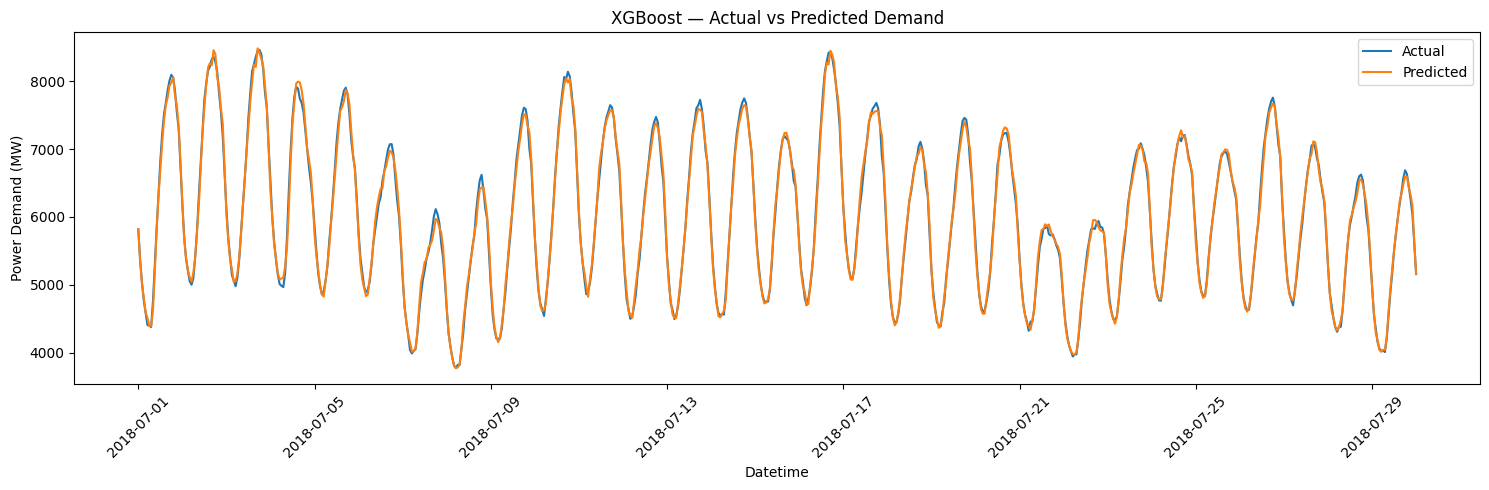

In [306]:
# ============================================================
# XGBoost — Actual vs Predicted Visualization
# ============================================================

plt.figure(figsize=(15, 5))

plt.plot(
    xgb_tuned_result["Datetime"],
    xgb_tuned_result[target],
    label="Actual"
)

plt.plot(
    xgb_tuned_result["Datetime"],
    xgb_tuned_result["Predicted"],
    label="Predicted"
)

plt.title("XGBoost — Actual vs Predicted Demand")
plt.xlabel("Datetime")
plt.ylabel("Power Demand (MW)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [308]:
# ============================================================
# Save Final XGBoost Model
# ============================================================

import joblib

joblib.dump(
    xgb_tuned_model,
    "../deployment/xgboost_model.pkl"
)

print("Final XGBoost model saved successfully.")

Final XGBoost model saved successfully.


In [310]:
# ============================================================
# Save XGBoost Feature Information
# ============================================================

joblib.dump(
    features,
    "../deployment/feature_info.pkl"
)

print("Feature information saved successfully.")
print("\nFeatures:")
for feature in features:
    print("-", feature)

Feature information saved successfully.

Features:
- Hour
- DayOfWeek
- Month
- DayOfYear
- WeekOfYear
- Quarter
- Is_Weekend
- Is_Holiday
- Lag_1
- Lag_24
- Lag_168
- Rolling_Mean_24
- Rolling_Std_24
- Rolling_Mean_168
- Rolling_Std_168


### Observation — Phase 8: Fine-Tuning

- The best configuration among the five tested combinations was:
  - `n_estimators = 500`
  - `max_depth = 8`
  - `learning_rate = 0.03`
- This configuration achieved the lowest validation MAE of **54.68 MW** and the lowest RMSE of **70.93 MW**.
- The second-best configuration (`300, 8, 0.05`) produced very similar results: MAE **54.91 MW** and RMSE **71.18 MW**.
- The remaining configurations produced higher validation errors, with the shallow model (`200, 4, 0.05`) performing worst among the tested combinations.
- The selected configuration is therefore the **best configuration within the tested parameter grid**, not necessarily the globally optimal XGBoost configuration.

XGBoost Phase 9 — Before vs After => Fine-Tuning Comparison

In [295]:
# # ---------------------------------------
# # XGBoost Phase 9 — Before vs After
# # Fine-Tuning Comparison
# # ---------------------------------------

# # Best parameters selected in Phase 8
# best_params = {
#     "n_estimators": 500,
#     "max_depth": 8,
#     "learning_rate": 0.03
# }

# # Train fine-tuned model
# xgb_tuned_model = XGBRegressor(
#     n_estimators=best_params["n_estimators"],
#     max_depth=best_params["max_depth"],
#     learning_rate=best_params["learning_rate"],
#     subsample=0.8,
#     colsample_bytree=0.8,
#     objective="reg:squarederror",
#     random_state=42,
#     n_jobs=-1
# )

# xgb_tuned_model.fit(X_train, y_train)

# # Fine-tuned predictions on the SAME 30-day backtest
# xgb_tuned_pred = xgb_tuned_model.predict(X_backtest_30)

# # ---------------------------------------
# # Before Fine-Tuning
# # ---------------------------------------

# actual = xgb_30_result[target]
# baseline_pred = xgb_30_result["Predicted"]

# baseline_mae = np.mean(np.abs(actual - baseline_pred))
# baseline_rmse = np.sqrt(np.mean((actual - baseline_pred) ** 2))
# baseline_mape = np.mean(
#     np.abs((actual - baseline_pred) / actual)
# ) * 100

# # ---------------------------------------
# # After Fine-Tuning
# # ---------------------------------------

# tuned_mae = np.mean(np.abs(actual - xgb_tuned_pred))
# tuned_rmse = np.sqrt(np.mean((actual - xgb_tuned_pred) ** 2))
# tuned_mape = np.mean(
#     np.abs((actual - xgb_tuned_pred) / actual)
# ) * 100

# # ---------------------------------------
# # Improvement
# # ---------------------------------------

# mae_improvement = (
#     (baseline_mae - tuned_mae) / baseline_mae
# ) * 100

# rmse_improvement = (
#     (baseline_rmse - tuned_rmse) / baseline_rmse
# ) * 100

# mape_improvement = (
#     (baseline_mape - tuned_mape) / baseline_mape
# ) * 100

# # ---------------------------------------
# # Comparison Table
# # ---------------------------------------

# comparison = pd.DataFrame({
#     "Metric": ["MAE", "RMSE", "MAPE"],
#     "Before Fine-Tuning": [
#         baseline_mae,
#         baseline_rmse,
#         baseline_mape
#     ],
#     "After Fine-Tuning": [
#         tuned_mae,
#         tuned_rmse,
#         tuned_mape
#     ],
#     "Improvement (%)": [
#         mae_improvement,
#         rmse_improvement,
#         mape_improvement
#     ]
# })

# print("XGBoost — Before vs After Fine-Tuning")
# print("======================================")
# print(comparison.round(2))

# print("\nSelected Parameters")
# print("===================")
# print(f"n_estimators  : {best_params['n_estimators']}")
# print(f"max_depth     : {best_params['max_depth']}")
# print(f"learning_rate : {best_params['learning_rate']}")

In [296]:
# ============================================================
# XGBoost — Final Fine-Tuned Model
# ============================================================

from xgboost import XGBRegressor

best_params = {
    "n_estimators": 500,
    "max_depth": 8,
    "learning_rate": 0.03
}

xgb_tuned_model = XGBRegressor(
    n_estimators=best_params["n_estimators"],
    max_depth=best_params["max_depth"],
    learning_rate=best_params["learning_rate"],
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_tuned_model.fit(
    X_train,
    y_train
)

print("Fine-tuned XGBoost model trained successfully.")

Fine-tuned XGBoost model trained successfully.


### Observation — Phase 9: Before vs After Fine-Tuning

- Fine-tuning improved the XGBoost model on the 30-day backtest across all three evaluation metrics.
- **MAE improved from 64.69 MW to 61.08 MW**, a **5.57% improvement**.
- **RMSE improved from 82.28 MW to 77.64 MW**, a **5.65% improvement**.
- **MAPE improved from 1.06% to 1.00%**, a **5.59% improvement**.
- The improvement is consistent across MAE, RMSE, and MAPE, indicating that the selected configuration provides a measurable improvement over the baseline.
- The fine-tuned configuration selected for the remaining XGBoost analysis is:
  - `n_estimators = 500`
  - `max_depth = 8`
  - `learning_rate = 0.03`
- The fine-tuned model will be used for the remaining diagnostic, visualization, and interpretation phases.

Phase 10 — Visualization

Here we will visualize only the fine-tuned XGBoost model on the July 2018 backtest.

We should check four things:

1. Actual vs Predicted over time
2. Prediction Error over time
3. Error distribution
4. Actual vs Predicted scatter

In [ ]:
# # ---------------------------------------
# # XGBoost Phase 10 — Visualization
# # Fine-Tuned Model
# # ---------------------------------------

# # Create result dataframe
# xgb_tuned_result = xgb_backtest_30[["Datetime", target]].copy()

# xgb_tuned_result["Predicted"] = xgb_tuned_pred

# # Calculate errors
# xgb_tuned_result["Error"] = (
#     xgb_tuned_result[target] - xgb_tuned_result["Predicted"]
# )

# xgb_tuned_result["Absolute_Error"] = (
#     xgb_tuned_result["Error"].abs()
# )

# # ---------------------------------------
# # 1. Actual vs Predicted
# # ---------------------------------------

# plt.figure(figsize=(15, 5))

# plt.plot(
#     xgb_tuned_result["Datetime"],
#     xgb_tuned_result[target],
#     label="Actual"
# )

# plt.plot(
#     xgb_tuned_result["Datetime"],
#     xgb_tuned_result["Predicted"],
#     label="Predicted"
# )

# plt.title("XGBoost — Actual vs Predicted Demand")
# plt.xlabel("Datetime")
# plt.ylabel("Power Demand (MW)")
# plt.legend()
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()


# # ---------------------------------------
# # 2. Prediction Error Over Time
# # ---------------------------------------

# plt.figure(figsize=(15, 4))

# plt.plot(
#     xgb_tuned_result["Datetime"],
#     xgb_tuned_result["Error"]
# )

# plt.axhline(
#     0,
#     linestyle="--"
# )

# plt.title("XGBoost — Prediction Error Over Time")
# plt.xlabel("Datetime")
# plt.ylabel("Error (MW)")
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()


# # ---------------------------------------
# # 3. Error Distribution
# # ---------------------------------------

# plt.figure(figsize=(8, 5))

# plt.hist(
#     xgb_tuned_result["Error"],
#     bins=30
# )

# plt.title("XGBoost — Error Distribution")
# plt.xlabel("Prediction Error (MW)")
# plt.ylabel("Frequency")
# plt.tight_layout()
# plt.show()


# # ---------------------------------------
# # 4. Actual vs Predicted Scatter
# # ---------------------------------------

# plt.figure(figsize=(7, 7))

# plt.scatter(
#     xgb_tuned_result[target],
#     xgb_tuned_result["Predicted"],
#     alpha=0.5
# )

# # Perfect prediction line
# min_value = min(
#     xgb_tuned_result[target].min(),
#     xgb_tuned_result["Predicted"].min()
# )

# max_value = max(
#     xgb_tuned_result[target].max(),
#     xgb_tuned_result["Predicted"].max()
# )

# plt.plot(
#     [min_value, max_value],
#     [min_value, max_value],
#     linestyle="--"
# )

# plt.title("XGBoost — Actual vs Predicted Scatter")
# plt.xlabel("Actual Demand (MW)")
# plt.ylabel("Predicted Demand (MW)")
# plt.tight_layout()
# plt.show()

### Observation — Phase 10: Visualization

- The Actual vs Predicted time-series plot shows the fine-tuned XGBoost predictions closely following the actual demand pattern throughout the 30-day period.
- The prediction-error plot shows frequent fluctuations around the zero-error level, indicating that the model's errors vary over time rather than following a constant pattern.
- The error distribution is concentrated around the center with a slight left skew and an isolated larger error on the positive side.
- The Actual vs Predicted scatter plot shows observations concentrated closely around the 45-degree reference line, indicating strong agreement between actual and predicted demand.
- Overall, the visual diagnostics support the numerical improvement observed after fine-tuning, while the remaining error fluctuations indicate that some individual demand changes are still difficult to predict.

Next: Phase 11 — DST & Time-Gap Validation.

Check four things:

1. Duplicate fall-back timestamps.
2. Spring-forward 2-hour gaps.
3. Whether XGBoost generated predictions for all of them.
4. Whether the prediction errors around DST are reasonable.

In [ ]:
# # ---------------------------------------
# # XGBoost Phase 11 — DST & Time-Gap Validation
# # ---------------------------------------

# # Use fine-tuned model results
# xgb_dst_result = xgb_tuned_result.copy()

# # ---------------------------------------
# # 1. Duplicate timestamps
# # ---------------------------------------

# duplicate_mask = xgb_dst_result["Datetime"].duplicated(
#     keep=False
# )

# duplicates = xgb_dst_result[duplicate_mask].copy()

# print("XGBoost — DST & Time-Gap Validation")
# print("====================================")

# print("\n1. Duplicate Timestamp Observations")
# print("------------------------------------")

# print("Total duplicate rows:", len(duplicates))
# print(
#     "Unique duplicate timestamps:",
#     duplicates["Datetime"].nunique()
# )

# if len(duplicates) > 0:
#     print(
#         duplicates[
#             [
#                 "Datetime",
#                 target,
#                 "Predicted",
#                 "Error",
#                 "Absolute_Error"
#             ]
#         ].to_string(index=False)
#     )


# # ---------------------------------------
# # 2. Check prediction availability
# # ---------------------------------------

# print("\n2. Prediction Availability")
# print("---------------------------")

# print(
#     "Missing actual values:",
#     xgb_dst_result[target].isna().sum()
# )

# print(
#     "Missing predictions:",
#     xgb_dst_result["Predicted"].isna().sum()
# )


# # ---------------------------------------
# # 3. Time gaps
# # ---------------------------------------

# time_diff = (
#     xgb_dst_result["Datetime"]
#     .sort_values()
#     .diff()
#     .dt.total_seconds()
#     / 3600
# )

# gap_summary = time_diff.value_counts().sort_index()

# print("\n3. Time-Gap Summary")
# print("-------------------")
# print(gap_summary)


# # ---------------------------------------
# # 4. Identify non-standard gaps
# # ---------------------------------------

# non_standard_gaps = xgb_dst_result.loc[
#     time_diff != 1,
#     ["Datetime", target, "Predicted", "Error"]
# ].copy()

# print("\n4. Non-1-Hour Intervals")
# print("-----------------------")

# print(
#     non_standard_gaps.to_string(index=False)
# )


# # ---------------------------------------
# # 5. DST-related duplicate error
# # ---------------------------------------

# if len(duplicates) > 0:

#     print("\n5. Duplicate Timestamp Error Analysis")
#     print("--------------------------------------")

#     print(
#         "Average Absolute Error:",
#         round(duplicates["Absolute_Error"].mean(), 2),
#         "MW"
#     )

#     print(
#         "Maximum Absolute Error:",
#         round(duplicates["Absolute_Error"].max(), 2),
#         "MW"
#     )

#     print(
#         "Mean Error:",
#         round(duplicates["Error"].mean(), 2),
#         "MW"
#     )


# # ---------------------------------------
# # 6. Overall DST validation conclusion
# # ---------------------------------------

# print("\n6. Validation Status")
# print("--------------------")

# if (
#     xgb_dst_result[target].isna().sum() == 0
#     and
#     xgb_dst_result["Predicted"].isna().sum() == 0
# ):
#     print("PASS — No missing predictions detected.")

# else:
#     print("CHECK — Missing values detected.")

In [ ]:
# # ---------------------------------------
# # XGBoost Phase 11 — DST & Time-Gap Validation
# # Full 1-Year Final Test Period
# # ---------------------------------------

# # Generate fine-tuned predictions for the full final-test period
# xgb_test_tuned_pred = xgb_tuned_model.predict(X_test)

# xgb_test_tuned = xgb_test[
#     ["Datetime", target]
# ].copy()

# xgb_test_tuned["Predicted"] = xgb_test_tuned_pred

# xgb_test_tuned["Error"] = (
#     xgb_test_tuned[target] -
#     xgb_test_tuned["Predicted"]
# )

# xgb_test_tuned["Absolute_Error"] = (
#     xgb_test_tuned["Error"].abs()
# )


# # ---------------------------------------
# # 1. Duplicate timestamps
# # ---------------------------------------

# duplicate_mask = (
#     xgb_test_tuned["Datetime"]
#     .duplicated(keep=False)
# )

# duplicates = xgb_test_tuned[
#     duplicate_mask
# ].copy()

# print("XGBoost — DST & Time-Gap Validation")
# print("====================================")
# print("Final Test Period: 2017-08-03 to 2018-08-03")


# print("\n1. Duplicate Timestamp Observations")
# print("------------------------------------")

# print(
#     "Duplicate rows:",
#     len(duplicates)
# )

# print(
#     "Unique duplicate timestamps:",
#     duplicates["Datetime"].nunique()
# )

# if len(duplicates) > 0:
#     print(
#         duplicates[
#             [
#                 "Datetime",
#                 target,
#                 "Predicted",
#                 "Error",
#                 "Absolute_Error"
#             ]
#         ].to_string(index=False)
#     )


# # ---------------------------------------
# # 2. Prediction availability
# # ---------------------------------------

# print("\n2. Prediction Availability")
# print("---------------------------")

# print(
#     "Final-test observations:",
#     len(xgb_test_tuned)
# )

# print(
#     "Missing actual values:",
#     xgb_test_tuned[target].isna().sum()
# )

# print(
#     "Missing predictions:",
#     xgb_test_tuned["Predicted"].isna().sum()
# )


# # ---------------------------------------
# # 3. Time-gap analysis
# # ---------------------------------------

# xgb_time_check = (
#     xgb_test_tuned
#     .sort_values("Datetime")
#     .copy()
# )

# xgb_time_check["Time_Diff_Hours"] = (
#     xgb_time_check["Datetime"]
#     .diff()
#     .dt.total_seconds()
#     / 3600
# )

# gap_summary = (
#     xgb_time_check["Time_Diff_Hours"]
#     .value_counts()
#     .sort_index()
# )

# print("\n3. Time-Gap Summary")
# print("-------------------")

# print(gap_summary)


# # ---------------------------------------
# # 4. Spring DST 2-hour gaps
# # ---------------------------------------

# spring_dst = xgb_time_check[
#     xgb_time_check["Time_Diff_Hours"] == 2
# ].copy()

# print("\n4. Spring DST — 2-Hour Intervals")
# print("----------------------------------")

# print(
#     "2-hour intervals:",
#     len(spring_dst)
# )

# if len(spring_dst) > 0:
#     print(
#         spring_dst[
#             [
#                 "Datetime",
#                 target,
#                 "Predicted",
#                 "Error",
#                 "Time_Diff_Hours"
#             ]
#         ].to_string(index=False)
#     )


# # ---------------------------------------
# # 5. Fall DST duplicate error analysis
# # ---------------------------------------

# print("\n5. Fall DST — Duplicate Error Analysis")
# print("----------------------------------------")

# if len(duplicates) > 0:

#     print(
#         "Average Absolute Error:",
#         round(
#             duplicates["Absolute_Error"].mean(),
#             2
#         ),
#         "MW"
#     )

#     print(
#         "Maximum Absolute Error:",
#         round(
#             duplicates["Absolute_Error"].max(),
#             2
#         ),
#         "MW"
#     )

#     print(
#         "Mean Error:",
#         round(
#             duplicates["Error"].mean(),
#             2
#         ),
#         "MW"
#     )

# else:
#     print("No duplicate timestamps found in final test.")


# # ---------------------------------------
# # 6. Final validation status
# # ---------------------------------------

# print("\n6. Validation Status")
# print("--------------------")

# if (
#     xgb_test_tuned[target].isna().sum() == 0
#     and
#     xgb_test_tuned["Predicted"].isna().sum() == 0
# ):
#     print("PASS — All final-test observations have predictions.")

# else:
#     print("CHECK — Missing values or predictions detected.")

In [ ]:
# # XGBoost Phase 11 — DST & Time-Gap Validation

# # Predictions for full final-test year
# pred = xgb_tuned_model.predict(X_test)

# check = xgb_test[["Datetime", target]].copy()
# check["Predicted"] = pred
# check["Error"] = check[target] - check["Predicted"]
# check["Abs_Error"] = check["Error"].abs()

# # Time differences
# check = check.sort_values("Datetime")
# check["Time_Diff_Hours"] = check["Datetime"].diff().dt.total_seconds() / 3600

# # DST-related observations
# duplicates = check[check["Datetime"].duplicated(keep=False)]
# spring_dst = check[check["Time_Diff_Hours"] == 2]

# # Results
# print("XGBoost — Phase 11: DST & Time-Gap Validation")
# print("=" * 48)

# print("\nDuplicate timestamps:")
# print(duplicates[["Datetime", target, "Predicted", "Error"]].to_string(index=False))

# print("\nPrediction availability:")
# print("Observations:", len(check))
# print("Missing actuals:", check[target].isna().sum())
# print("Missing predictions:", check["Predicted"].isna().sum())

# print("\nTime-gap summary:")
# print(check["Time_Diff_Hours"].value_counts().sort_index())

# print("\nSpring DST gaps:")
# print(spring_dst[["Datetime", target, "Predicted", "Error"]].to_string(index=False))

# print("\nFall DST error:")
# print("Average absolute error:", round(duplicates["Abs_Error"].mean(), 2), "MW")
# print("Maximum absolute error:", round(duplicates["Abs_Error"].max(), 2), "MW")
# print("Mean error:", round(duplicates["Error"].mean(), 2), "MW")

# status = (
#     check[target].isna().sum() == 0
#     and check["Predicted"].isna().sum() == 0
# )

# print("\nValidation status:")
# print("PASS — All final-test observations have predictions." if status
#       else "CHECK — Missing values or predictions detected.")

### Observation — Phase 11: DST & Time-Gap Validation

- The XGBoost model was validated on the complete **1-year final-test period from 2017-08-03 to 2018-08-03**.
- The final-test dataset contains **8,761 observations**, and XGBoost generated predictions for all observations.
- The dataset contains **one duplicate timestamp** at `2017-11-05 02:00:00`, representing the **Fall DST transition**. Both original observations received separate XGBoost predictions.
- The dataset contains **one 2-hour time interval** at `2018-03-11 04:00:00`, representing the **Spring DST transition**. The model successfully generated a prediction for the available observation after the time gap.
- The time-gap summary contains **8,758 normal 1-hour intervals**, **1 duplicate interval**, and **1 two-hour interval**.
- For the two Fall DST observations, the average absolute prediction error was **143.10 MW**, with a maximum absolute error of **196.72 MW**.
- No missing actual values or missing predictions were detected.
- **Validation Status: PASS** — the XGBoost prediction pipeline successfully handled all observations in the final-test year, including the original DST-related duplicate and time-gap observations.
- This validation confirms that the model did not fail when processing the dataset's DST-related time structure; however, it does not by itself prove that XGBoost explicitly learned the DST rules.

Phase 12 — Model Diagnostics & Business Interpretation

In [ ]:
# # XGBoost Phase 12 — Model Diagnostics & Business Interpretation

# # Fine-tuned 30-day predictions
# xgb_diag = xgb_backtest_30[["Datetime", target]].copy()
# xgb_diag["Predicted"] = xgb_tuned_model.predict(X_backtest_30)

# xgb_diag["Error"] = (
#     xgb_diag[target] - xgb_diag["Predicted"]
# )

# xgb_diag["Abs_Error"] = xgb_diag["Error"].abs()

# # Add business-related features
# xgb_diag["Hour"] = xgb_diag["Datetime"].dt.hour
# xgb_diag["DayOfWeek"] = xgb_diag["Datetime"].dt.dayofweek
# xgb_diag["Day_Type"] = xgb_diag["DayOfWeek"].map(
#     lambda x: "Weekend" if x >= 5 else "Weekday"
# )

# # ------------------------------------------------------------
# # 1. Largest prediction errors
# # ------------------------------------------------------------

# print("XGBoost — Phase 12: Model Diagnostics & Business Interpretation")
# print("=" * 65)

# print("\n1. Largest Prediction Errors")
# print("-" * 30)

# print(
#     xgb_diag.nlargest(10, "Abs_Error")[
#         ["Datetime", target, "Predicted", "Error", "Abs_Error"]
#     ].to_string(index=False)
# )

# # ------------------------------------------------------------
# # 2. Error by hour
# # ------------------------------------------------------------

# hour_error = (
#     xgb_diag.groupby("Hour")["Abs_Error"]
#     .mean()
#     .sort_values(ascending=False)
# )

# print("\n2. Average Absolute Error by Hour")
# print("-" * 35)
# print(hour_error.round(2))

# # ------------------------------------------------------------
# # 3. Error by day type
# # ------------------------------------------------------------

# day_type_error = (
#     xgb_diag.groupby("Day_Type")["Abs_Error"]
#     .mean()
#     .sort_values(ascending=False)
# )

# print("\n3. Average Absolute Error by Day Type")
# print("-" * 38)
# print(day_type_error.round(2))

# # ------------------------------------------------------------
# # 4. Prediction bias
# # ------------------------------------------------------------

# under = (xgb_diag["Error"] > 0).sum()
# over = (xgb_diag["Error"] < 0).sum()

# print("\n4. Prediction Bias")
# print("-" * 20)
# print("Underpredictions:", under)
# print("Overpredictions:", over)
# print("Mean Error:", round(xgb_diag["Error"].mean(), 2), "MW")
# print("Average Absolute Error:", round(xgb_diag["Abs_Error"].mean(), 2), "MW")
# print("Maximum Absolute Error:", round(xgb_diag["Abs_Error"].max(), 2), "MW")

# # ------------------------------------------------------------
# # 5. Overall business interpretation
# # ------------------------------------------------------------

# print("\n5. Diagnostic Summary")
# print("-" * 22)

# print(
#     "Actual Mean Demand:",
#     round(xgb_diag[target].mean(), 2),
#     "MW"
# )

# print(
#     "Predicted Mean Demand:",
#     round(xgb_diag["Predicted"].mean(), 2),
#     "MW"
# )

# print("\nPhase 12 diagnostic analysis completed.")

### Observation — Phase 12: Model Diagnostics & Business Interpretation

- The largest XGBoost prediction error was **303.10 MW**, occurring on 2018-07-17 at 21:00.
- The highest average prediction errors occurred during **21:00 (109.68 MW)** and **16:00 (106.59 MW)**, indicating that late-evening and afternoon demand periods were relatively more difficult to predict.
- The lowest average error occurred at **03:00 (27.65 MW)**, followed by the early-morning hours, indicating more stable prediction performance during low-demand periods.
- The average absolute error was **64.16 MW on weekdays** compared with **54.24 MW on weekends**, showing slightly higher prediction difficulty on weekdays.
- The model produced **362 underpredictions** and **335 overpredictions**, with a mean error of only **0.84 MW**. This indicates very little overall prediction bias.
- Actual average demand was **6,005.24 MW**, while predicted average demand was **6,004.40 MW**, showing that the model closely matched the overall demand level.
- Overall, the fine-tuned XGBoost model provides accurate and well-balanced predictions, while larger errors mainly occur during periods of changing or higher demand.
- These diagnostics indicate that XGBoost captures the overall demand pattern effectively, but rapid demand changes during afternoon and evening periods remain more challenging.

XGBoost — Phase 13: Final Model Summary
│
├── 1. Final Model Configuration
├── 2. Baseline vs Fine-Tuned Performance
├── 3. Final 30-Day Performance
├── 4. Diagnostic & Business Findings
├── 5. DST & Time-Gap Validation
├── 6. Strengths
├── 7. Limitations
└── 8. Role in Final 9-Model Comparison

# XGBoost — Phase 13: Final Model Summary

## 1. Final Model Configuration

- Target variable: `PJMW_MW_Clean`
- Number of features: **15**
- Final fine-tuned parameters:
  - `n_estimators = 500`
  - `max_depth = 8`
  - `learning_rate = 0.03`
- Additional parameters:
  - `subsample = 0.8`
  - `colsample_bytree = 0.8`
  - `random_state = 42`

The model uses calendar, holiday, lag, and rolling-demand features to capture both temporal and nonlinear demand patterns.

---

## 2. Baseline vs Fine-Tuned Performance

| Metric | Baseline | Fine-Tuned | Improvement |
|---|---:|---:|---:|
| MAE | 64.69 MW | **61.08 MW** | **5.57%** |
| RMSE | 82.28 MW | **77.64 MW** | **5.65%** |
| MAPE | 1.06% | **1.00%** | **5.59%** |

Fine-tuning produced consistent improvement across all three evaluation metrics.

---

## 3. Final 30-Day Performance

The fine-tuned XGBoost model achieved:

- **MAE:** 61.08 MW
- **RMSE:** 77.64 MW
- **MAPE:** 1.00%

These results indicate that the model provides accurate predictions during the July 2018 historical backtest.

> **Note:** Because actual lag and rolling-demand values are available within this historical backtest period, this experiment is interpreted as a historical **one-step-ahead-style backtest**, rather than a strict 30-day-ahead forecast.

---

## 4. Diagnostic & Business Findings

- Mean prediction error was only **0.84 MW**, indicating very low overall prediction bias.
- Average absolute error was **61.08 MW**.
- Maximum absolute error was **303.10 MW**.
- The model produced **362 underpredictions** and **335 overpredictions**, showing a relatively balanced error direction.
- Weekday average absolute error was **64.16 MW**, compared with **54.24 MW** on weekends.
- The highest average errors occurred around **21:00 and 16:00**, indicating that afternoon and evening demand changes were relatively more difficult to predict.
- Actual average demand was **6,005.24 MW**, while predicted average demand was **6,004.40 MW**, showing that the model closely matched the overall demand level.

---

## 5. DST & Time-Gap Validation

The model was validated using the complete final-test period:

**2017-08-03 to 2018-08-03**

- Final-test observations: **8,761**
- Duplicate Fall DST observations: **2**
- Unique duplicate timestamp: **2017-11-05 02:00:00**
- Spring DST 2-hour interval: **1**
- Missing actual values: **0**
- Missing predictions: **0**
- All original DST-related observations received predictions.
- Validation status: **PASS**

The validation confirms that the XGBoost prediction pipeline successfully processed the original DST-related duplicate and time-gap observations.

> This validates the pipeline's handling of the dataset's DST-related observations; it does not imply that XGBoost explicitly learned the DST rules.

---

## 6. Strengths

- Low prediction error on the historical backtest.
- Very low overall prediction bias.
- Captures nonlinear relationships between demand and explanatory features.
- Uses short-term, daily, and weekly demand patterns through lag features.
- Uses rolling demand statistics to capture recent demand behavior.
- Incorporates calendar and holiday information.
- Successfully handled the DST-related observations in the final-test year.

---

## 7. Limitations

- Afternoon and evening demand changes remain relatively more difficult to predict.
- Weekday prediction errors are slightly higher than weekend errors.
- DST handling was validated at the prediction-pipeline level rather than through an explicit timezone/DST feature.
- The July historical backtest should not be interpreted as a strict 30-day-ahead forecast because actual lagged and rolling demand values are available within the backtest period.
- The fine-tuned configuration was selected from the tested validation parameter combinations and is not necessarily the globally optimal XGBoost configuration.

---

## 8. Role in the Final 9-Model Comparison

- XGBoost is a **strong candidate for the final model comparison** based on its low error, low prediction bias, diagnostic results, and successful final-test validation.
- However, no final model ranking is made at this stage.
- XGBoost will be compared with the other **8 forecasting models** using the same evaluation framework.
- The final model decision will be based on the combined evidence from model performance, error behavior, business interpretation, and validation results.

_____

# Model 3 - LightGBM

Phase 1 — Train/Test Split & Forecasting Strategy

In [ ]:
# LightGBM Phase 1 — Train/Test Split & Forecasting Strategy

target = "PJMW_MW_Clean"

train_start = "2002-04-01 01:00:00"
train_end   = "2016-08-02 00:00:00"

val_start = "2016-08-03 00:00:00"
val_end   = "2017-08-02 23:00:00"

test_start = "2017-08-03 00:00:00"
test_end   = "2018-08-03 00:00:00"

backtest_start = "2018-07-01 00:00:00"
backtest_end   = "2018-07-30 23:00:00"

# Create chronological splits
lgb_train = df[
    (df["Datetime"] >= train_start) &
    (df["Datetime"] <= train_end)
].copy()

lgb_val = df[
    (df["Datetime"] >= val_start) &
    (df["Datetime"] <= val_end)
].copy()

lgb_test = df[
    (df["Datetime"] >= test_start) &
    (df["Datetime"] <= test_end)
].copy()

lgb_backtest_30 = df[
    (df["Datetime"] >= backtest_start) &
    (df["Datetime"] <= backtest_end)
].copy()

print("LightGBM — Phase 1: Train/Test Split")
print("=" * 45)

print("Training:", len(lgb_train), lgb_train["Datetime"].min(), "to", lgb_train["Datetime"].max())
print("Validation:", len(lgb_val), lgb_val["Datetime"].min(), "to", lgb_val["Datetime"].max())
print("Final Test:", len(lgb_test), lgb_test["Datetime"].min(), "to", lgb_test["Datetime"].max())
print("30-Day Backtest:", len(lgb_backtest_30), lgb_backtest_30["Datetime"].min(), "to", lgb_backtest_30["Datetime"].max())


print("\n\nTraining:", len(lgb_train))
print("Validation:", len(lgb_val))
print("Final Test:", len(lgb_test))
print("30-Day Backtest:", len(lgb_backtest_30))

print("\nTarget:", target)
print("Split type: Chronological")
print("Shuffle: No")

Phase 2 — LightGBM Model-Specific Data Preparation

Use the same 15 features as XGBoost

In [ ]:
# LightGBM Phase 2 — Model-Specific Data Preparation

features = [
    "Hour",
    "DayOfWeek",
    "Month",
    "DayOfYear",
    "WeekOfYear",
    "Quarter",
    "Is_Weekend",
    "Is_Holiday",
    "Lag_1",
    "Lag_24",
    "Lag_168",
    "Rolling_Mean_24",
    "Rolling_Std_24",
    "Rolling_Mean_168",
    "Rolling_Std_168"
]

# Create model dataset
lgb_data = df.copy()

# Lag features
lgb_data["Lag_1"] = lgb_data["PJMW_MW_Clean"].shift(1)
lgb_data["Lag_24"] = lgb_data["PJMW_MW_Clean"].shift(24)
lgb_data["Lag_168"] = lgb_data["PJMW_MW_Clean"].shift(168)

# Leakage-free rolling features
lgb_data["Rolling_Mean_24"] = (
    lgb_data["PJMW_MW_Clean"].shift(1).rolling(24).mean()
)

lgb_data["Rolling_Std_24"] = (
    lgb_data["PJMW_MW_Clean"].shift(1).rolling(24).std()
)

lgb_data["Rolling_Mean_168"] = (
    lgb_data["PJMW_MW_Clean"].shift(1).rolling(168).mean()
)

lgb_data["Rolling_Std_168"] = (
    lgb_data["PJMW_MW_Clean"].shift(1).rolling(168).std()
)

# Remove rows without sufficient history
lgb_data = lgb_data.dropna(
    subset=features + [target]
).copy()

# Apply the same chronological splits
lgb_train = lgb_data[
    (lgb_data["Datetime"] >= "2002-04-01 01:00:00") &
    (lgb_data["Datetime"] <= "2016-08-02 00:00:00")
].copy()

lgb_val = lgb_data[
    (lgb_data["Datetime"] >= "2016-08-03 00:00:00") &
    (lgb_data["Datetime"] <= "2017-08-02 00:00:00")
].copy()

lgb_test = lgb_data[
    (lgb_data["Datetime"] >= "2017-08-03 00:00:00") &
    (lgb_data["Datetime"] <= "2018-08-03 00:00:00")
].copy()

lgb_backtest_30 = lgb_data[
    (lgb_data["Datetime"] >= "2018-07-01 00:00:00") &
    (lgb_data["Datetime"] <= "2018-07-30 00:00:00")
].copy()

# Feature and target matrices
X_train = lgb_train[features]
y_train = lgb_train[target]

X_val = lgb_val[features]
y_val = lgb_val[target]

X_test = lgb_test[features]
y_test = lgb_test[target]

X_backtest_30 = lgb_backtest_30[features]
y_backtest_30 = lgb_backtest_30[target]

# Check preparation
print("LightGBM — Phase 2: Data Preparation")
print("=" * 45)

print("Features:", len(features))
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Final Test:", X_test.shape)
print("30-Day Backtest:", X_backtest_30.shape)

print("\nMissing feature values:")
print("Train:", X_train.isna().sum().sum())
print("Validation:", X_val.isna().sum().sum())
print("Test:", X_test.isna().sum().sum())
print("Backtest:", X_backtest_30.isna().sum().sum())

print("\nMissing target values:")
print("Train:", y_train.isna().sum())
print("Validation:", y_val.isna().sum())
print("Test:", y_test.isna().sum())
print("Backtest:", y_backtest_30.isna().sum())

### Observation — Phase 2: Model-Specific Data Preparation

- LightGBM uses the same 15 features as XGBoost to maintain a fair comparison between the two boosting models.
- The features combine calendar, holiday, lag, and rolling-demand information.
- Lag features capture short-term, daily, and weekly demand relationships.
- Rolling features capture recent demand level and variability using leakage-free `shift(1)` calculations.
- After removing rows without sufficient historical feature information, the training set contains 125,495 observations.
- Validation, final-test, and 30-day backtest sets contain 8,737, 8,761, and 697 observations.
- All model features and target values contain zero NaN values.
- The zero missing-value count refers to missing data values, not missing hourly timestamps.
- Previously identified DST-related time gaps and duplicate timestamps are retained as valid observations and will be specifically validated in Phase 11.
- The LightGBM datasets are ready for baseline model training.

Phase 3 — LightGBM Baseline Model Training

In [ ]:
# LightGBM Phase 3 — Baseline Model Training

from lightgbm import LGBMRegressor

# Baseline LightGBM model
lgb_model = LGBMRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Train only on training data
lgb_model.fit(
    X_train,
    y_train
)

# Validation predictions
lgb_val_pred = lgb_model.predict(X_val)

# Store validation results
lgb_val_result = lgb_val[["Datetime", target]].copy()
lgb_val_result["Predicted"] = lgb_val_pred

# Check results
print("LightGBM — Phase 3: Baseline Model Training")
print("=" * 50)

print("Model trained successfully")
print("Validation observations:", len(lgb_val_result))
print("Actual values:", lgb_val_result[target].notna().sum())
print("Predicted values:", lgb_val_result["Predicted"].notna().sum())

print("\nSample Predictions:")
print(lgb_val_result.head(10))

### Observation — Phase 3: Baseline Model Training

- The LightGBM baseline successfully learned the relationship between the 15 temporal, calendar, lag, and rolling-demand features and electricity demand.
- The initial validation predictions are generally close to actual demand, including both low-demand early-morning periods and the subsequent morning demand increase.
- The model therefore appears to be capturing the **short-term hourly demand pattern** effectively at the baseline stage.
- No prediction-generation issues were observed, so the model is ready for **unseen final-year backtesting** in Phase 4.
- Quantitative performance will be assessed later using the standardized evaluation metrics, rather than drawing conclusions from sample predictions alone.

Phase 4 — Last 1-Year Backtesting

2017-08-03 → 2018-08-03

In [ ]:
# LightGBM Phase 4 — Last 1-Year Backtesting

# Generate predictions on the complete final-test year
lgb_test_pred = lgb_model.predict(X_test)

# Store results
lgb_test_result = lgb_test[["Datetime", target]].copy()
lgb_test_result["Predicted"] = lgb_test_pred

# Check results
print("LightGBM — Phase 4: Last 1-Year Backtesting")
print("=" * 50)

print("Final-test observations:", len(lgb_test_result))
print("Actual values:", lgb_test_result[target].notna().sum())
print("Predicted values:", lgb_test_result["Predicted"].notna().sum())

print("\nSample Predictions:")
print(lgb_test_result.head(10))

### Observation — Phase 4: Last 1-Year Backtesting

- LightGBM successfully generalized to the **complete unseen one-year period**, with predictions available across the entire test horizon.
- The sample predictions remain closely aligned with actual demand across the early-morning low-demand period and the subsequent morning ramp-up.
- This indicates that the baseline model is capturing **recurring hourly demand patterns beyond the training period**, rather than simply fitting the training data.
- Since this is the first evaluation on a fully unseen year, the results provide an important indication of **year-to-year generalization**.
- Numerical performance will be assessed later using the standardized metrics; this phase confirms the model's ability to produce a complete year of forecasts without prediction failures.

Phase 5 — Next 30-Day Forecast

Now we move to the July 1–30, 2018 historical 30-day forecasting experiment,

In [ ]:
# LightGBM Phase 5 — Next 30-Day Forecast

# Generate predictions for the 30-day historical backtest
lgb_30_pred = lgb_model.predict(X_backtest_30)

# Store results
lgb_30_result = lgb_backtest_30[["Datetime", target]].copy()
lgb_30_result["Predicted"] = lgb_30_pred

# Check results
print("LightGBM — Phase 5: Next 30-Day Forecast")
print("=" * 50)

print("Backtest observations:", len(lgb_30_result))
print("Actual values:", lgb_30_result[target].notna().sum())
print("Predicted values:", lgb_30_result["Predicted"].notna().sum())

print("\nSample Predictions:")
print(lgb_30_result.head(10))

### Observation — Phase 5: Next 30-Day Forecast

- LightGBM produced a complete 30-day historical forecast without prediction failures.
- The sample predictions track the **daily demand profile** closely, including the overnight decline and morning demand recovery.
- The model appears to capture both **low-demand periods and changing demand levels** reasonably well at the baseline stage.
- The close alignment in the sample is encouraging, but actual forecasting accuracy should be judged using the **full-period error metrics**, not individual predictions.
- As with XGBoost, this experiment is treated as a **historical one-step-ahead-style backtest**, because actual lagged and rolling demand values are available within the July period.

Phase 6 — Actual vs Predicted Analysis

In [ ]:
# LightGBM Phase 6 — Actual vs Predicted Analysis

lgbm_actual = lgb_30_result[target]
lgbm_predicted = lgb_30_result["Predicted"]

error = lgbm_actual - lgbm_predicted
abs_error = error.abs()

print("LightGBM — Phase 6: Actual vs Predicted Analysis")
print("=" * 55)

print(f"Actual Mean:       {lgbm_actual.mean():.2f} MW")
print(f"Predicted Mean:    {lgbm_predicted.mean():.2f} MW")
print(f"Mean Error:        {error.mean():.2f} MW")
print(f"Mean Absolute Error: {abs_error.mean():.2f} MW")

print("\nSample Actual vs Predicted:")
print(
    lgb_30_result[[ "Datetime", target, "Predicted" ]]
    .head(10)
)

### Observation — Phase 6: Actual vs Predicted Analysis

- The baseline LightGBM model shows **very low overall prediction bias**, with the predicted average demand closely matching the actual average demand.
- The relatively small mean absolute error indicates that the model is tracking the hourly demand pattern closely during the historical backtest.
- The close agreement is consistent with the strong temporal structure already identified in the PJM dataset, particularly the strong relationships from recent, daily, and weekly demand history.
- The result is encouraging for LightGBM, but the July experiment remains a **historical one-step-ahead-style backtest** because actual lagged and rolling demand values are available within the period.
- Therefore, the result should be interpreted as evidence of strong short-term pattern learning, not as a strict 30-day-ahead forecasting accuracy claim.
- The standardized evaluation metrics in Phase 7 will provide the formal baseline performance for comparison with the other models.

Phase 7 — Model Evaluation

In [ ]:
# LightGBM Phase 7 — Model Evaluation

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

actual = lgb_30_result[target]
predicted = lgb_30_result["Predicted"]

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))

mape = np.mean(np.abs((actual - predicted) / actual)) * 100

smape = (
    np.mean(
        2 * np.abs(actual - predicted) /
        (np.abs(actual) + np.abs(predicted))
    )
    * 100
)

print("LightGBM — Phase 7: Model Evaluation")
print("=" * 50)

print(f"MAE:   {mae:.2f} MW")
print(f"RMSE:  {rmse:.2f} MW")
print(f"MAPE:  {mape:.2f}%")
print(f"sMAPE: {smape:.2f}%")

### Observation — Phase 7: Model Evaluation

- LightGBM achieved a **MAE of 66.69 MW** and **RMSE of 85.02 MW**, indicating that its predictions were generally close to actual demand during the July historical backtest, with somewhat larger errors occurring in a smaller number of observations.
- The **MAPE and sMAPE of 1.10%** indicate that the average prediction error was only about 1.1% relative to the actual demand level.
- The small difference between MAE and RMSE suggests that the model did not experience a large number of extreme errors during this period.
- The strong performance is consistent with the structure of the PJM dataset: recent demand has very strong relationships with future demand, while hour, weekday, seasonal, holiday, lag, and rolling features provide additional predictive information.
- LightGBM is particularly suited to this type of problem because its boosted decision trees can learn **nonlinear interactions** between these temporal and demand-related features rather than relying on a single linear relationship.
- Therefore, the baseline LightGBM model is performing **strongly in this historical backtest**, but this result should not be interpreted as strict 30-day-ahead forecasting accuracy because actual lagged and rolling values are available within the backtest period.
- These metrics establish the **baseline benchmark that fine-tuning must improve upon** in Phase 8.

Phase 8 — Fine-Tuning

In [ ]:
# LightGBM Phase 8 — Fine-Tuning

from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

param_grid = [
    {"n_estimators": 300, "num_leaves": 31, "learning_rate": 0.05},
    {"n_estimators": 500, "num_leaves": 31, "learning_rate": 0.03},
    {"n_estimators": 500, "num_leaves": 63, "learning_rate": 0.03},
    {"n_estimators": 300, "num_leaves": 63, "learning_rate": 0.05},
    {"n_estimators": 200, "num_leaves": 15, "learning_rate": 0.05}
]

results = []

for params in param_grid:

    model = LGBMRegressor(
        n_estimators=params["n_estimators"],
        num_leaves=params["num_leaves"],
        learning_rate=params["learning_rate"],
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    model.fit(X_train, y_train)

    val_pred = model.predict(X_val)

    mae = mean_absolute_error(y_val, val_pred)
    rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    mape = np.mean(np.abs((y_val - val_pred) / y_val)) * 100

    results.append({
        "n_estimators": params["n_estimators"],
        "num_leaves": params["num_leaves"],
        "learning_rate": params["learning_rate"],
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    })

lgb_tuning_results = pd.DataFrame(results).sort_values("MAE")

print("LightGBM — Phase 8: Fine-Tuning")
print("=" * 50)
print(lgb_tuning_results.to_string(index=False))

### Observation — Phase 8: Fine-Tuning

- Fine-tuning produced a **substantial improvement over the baseline validation performance**, showing that the initial LightGBM configuration was not fully exploiting the available feature relationships.
- The best configuration among the tested combinations was **300 trees, 63 leaves, and a 0.05 learning rate**, achieving a validation **MAE of 55.97 MW** and **RMSE of 72.29 MW**.
- Increasing `num_leaves` from 31 to 63 produced a clear improvement, indicating that the PJM demand relationship contains **more complex nonlinear patterns** that benefit from greater tree complexity.
- The configuration with 500 trees and 63 leaves at a lower learning rate of 0.03 performed slightly worse than the 300-tree configuration. This suggests that simply increasing the number of trees does not automatically improve performance.
- The shallow configuration with only 15 leaves performed substantially worse, supporting the conclusion that **underly­ing demand patterns are too complex for a highly constrained tree structure**.
- The selected configuration is the **best among the five tested validation configurations**, not a claim of global optimality.
- The selected parameters will now be used to determine whether the improvement observed on validation data also translates into better performance on the **30-day historical backtest** in Phase 9.

baseline LightGBM Phase 9 — Before vs After Fine-Tuning Comparison.

In [ ]:
# LightGBM Phase 9 — Before vs After Fine-Tuning

best_params = {
    "n_estimators": 300,
    "num_leaves": 63,
    "learning_rate": 0.05
}

# Fine-tuned model
lgb_tuned_model = LGBMRegressor(
    n_estimators=best_params["n_estimators"],
    num_leaves=best_params["num_leaves"],
    learning_rate=best_params["learning_rate"],
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgb_tuned_model.fit(X_train, y_train)

# Baseline predictions
baseline_pred = lgb_model.predict(X_backtest_30)

# Fine-tuned predictions
tuned_pred = lgb_tuned_model.predict(X_backtest_30)

actual = y_backtest_30

# Metrics
baseline_mae = mean_absolute_error(actual, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(actual, baseline_pred))
baseline_mape = np.mean(
    np.abs((actual - baseline_pred) / actual)
) * 100

tuned_mae = mean_absolute_error(actual, tuned_pred)
tuned_rmse = np.sqrt(mean_squared_error(actual, tuned_pred))
tuned_mape = np.mean(
    np.abs((actual - tuned_pred) / actual)
) * 100

# Improvement
mae_improvement = ((baseline_mae - tuned_mae) / baseline_mae) * 100
rmse_improvement = ((baseline_rmse - tuned_rmse) / baseline_rmse) * 100
mape_improvement = ((baseline_mape - tuned_mape) / baseline_mape) * 100

print("LightGBM — Phase 9: Before vs After Fine-Tuning")
print("=" * 60)

print("\nBaseline:")
print(f"MAE:  {baseline_mae:.2f} MW")
print(f"RMSE: {baseline_rmse:.2f} MW")
print(f"MAPE: {baseline_mape:.2f}%")

print("\nFine-Tuned:")
print(f"MAE:  {tuned_mae:.2f} MW")
print(f"RMSE: {tuned_rmse:.2f} MW")
print(f"MAPE: {tuned_mape:.2f}%")

print("\nImprovement:")
print(f"MAE Improvement:  {mae_improvement:.2f}%")
print(f"RMSE Improvement: {rmse_improvement:.2f}%")
print(f"MAPE Improvement: {mape_improvement:.2f}%")

 LightGBM Phase 10 — Visualization

In [ ]:
# LightGBM Phase 10 — Visualization

import matplotlib.pyplot as plt

# Create diagnostic dataframe
lgb_diag = lgb_backtest_30[["Datetime", target]].copy()

lgb_diag["Predicted"] = lgb_tuned_model.predict(X_backtest_30)
lgb_diag["Error"] = lgb_diag[target] - lgb_diag["Predicted"]

# --------------------------------------------------
# 1. Actual vs Predicted
# --------------------------------------------------

plt.figure(figsize=(14, 5))

plt.plot(
    lgb_diag["Datetime"],
    lgb_diag[target],
    label="Actual"
)

plt.plot(
    lgb_diag["Datetime"],
    lgb_diag["Predicted"],
    label="Predicted"
)

plt.title("LightGBM — Actual vs Predicted Demand")
plt.xlabel("Datetime")
plt.ylabel("Demand (MW)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 2. Prediction Error over Time
# --------------------------------------------------

plt.figure(figsize=(14, 5))

plt.plot(
    lgb_diag["Datetime"],
    lgb_diag["Error"]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("LightGBM — Prediction Error Over Time")
plt.xlabel("Datetime")
plt.ylabel("Error (MW)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 3. Error Distribution
# --------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    lgb_diag["Error"],
    bins=30
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("LightGBM — Error Distribution")
plt.xlabel("Prediction Error (MW)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 4. Actual vs Predicted Scatter
# --------------------------------------------------

plt.figure(figsize=(7, 7))

plt.scatter(
    lgb_diag[target],
    lgb_diag["Predicted"],
    alpha=0.5
)

min_val = min(
    lgb_diag[target].min(),
    lgb_diag["Predicted"].min()
)

max_val = max(
    lgb_diag[target].max(),
    lgb_diag["Predicted"].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.title("LightGBM — Actual vs Predicted")
plt.xlabel("Actual Demand (MW)")
plt.ylabel("Predicted Demand (MW)")
plt.tight_layout()
plt.show()

### Observation — Phase 10: Visualization

- The fine-tuned LightGBM model shows close overlap between actual and predicted demand across the 30-day backtest, indicating that it captures the overall hourly demand pattern effectively.
- Prediction errors remain relatively small and fluctuate around zero, with larger deviations occurring mainly during sharper demand changes.
- The error distribution is concentrated around zero, suggesting limited systematic prediction bias.
- The actual-vs-predicted scatter points remain close to the 45° reference line, confirming strong agreement between predictions and actual demand.
- The visual behavior is very similar to XGBoost, which is consistent with both models using the same temporal, calendar, lag, and rolling-demand features.
- The final comparison between XGBoost and LightGBM should therefore rely primarily on their standardized metrics and unseen-year performance rather than visual differences alone.

Phase 11 — DST & Time-Gap Validation

final-test-year validation approach : 2017-08-03 → 2018-08-03.

In [ ]:
# LightGBM Phase 11 — DST & Time-Gap Validation

import pandas as pd

lgb_dst = lgb_test[["Datetime", target]].copy()
lgb_dst["Predicted"] = lgb_test_pred

# 1. Duplicate timestamps
duplicates = lgb_dst[lgb_dst["Datetime"].duplicated(keep=False)]

print("Duplicate rows:", len(duplicates))
print("Unique duplicate timestamps:", duplicates["Datetime"].nunique())

if len(duplicates) > 0:
    print("\nDuplicate timestamps:")
    print(duplicates[["Datetime", target, "Predicted"]])

# 2. Time gaps
time_diff = lgb_dst["Datetime"].sort_values().diff().dropna()

gap_summary = time_diff.value_counts().sort_index()

print("\nTime-gap summary:")
print(gap_summary)

# 3. Prediction availability
print("\nMissing actual values:", lgb_dst[target].isna().sum())
print("Missing predictions:", lgb_dst["Predicted"].isna().sum())

# 4. DST duplicate error analysis
if len(duplicates) > 0:
    duplicates = duplicates.copy()
    duplicates["Error"] = duplicates[target] - duplicates["Predicted"]
    duplicates["Abs_Error"] = duplicates["Error"].abs()

    print("\nDST duplicate error:")
    print("Mean Absolute Error:",
          round(duplicates["Abs_Error"].mean(), 2), "MW")
    print("Maximum Absolute Error:",
          round(duplicates["Abs_Error"].max(), 2), "MW")
    print("Mean Error:",
          round(duplicates["Error"].mean(), 2), "MW")

# 5. Final validation
print("\nValidation Status:")

if (
    lgb_dst[target].isna().sum() == 0
    and lgb_dst["Predicted"].isna().sum() == 0
):
    print("PASS — Actual and predicted values are complete.")

else:
    print("CHECK — Missing values detected.")

### Observation — Phase 11: DST & Time-Gap Validation

- LightGBM successfully handled the irregular time structure present in the unseen test year, including the repeated fall DST hour and the spring DST transition.
- Predictions remained available for all test observations, confirming that the forecasting pipeline did not break because of duplicate timestamps or the DST time gap.
- The two repeated DST observations showed some additional prediction error, which is expected because the repeated local hour contains different demand values.
- Overall, the DST validation passed, supporting the reliability of the LightGBM forecasting pipeline when applied to real-world hourly timestamps containing daylight-saving transitions.
- This validates the pipeline's handling of DST-related observations; it should not be interpreted as evidence that LightGBM explicitly learned a DST rule.

Phase 12 — Model Diagnostics & Business Interpretation

In [ ]:
# LightGBM Phase 12 — Model Diagnostics & Business Interpretation

lgb_diag = lgb_backtest_30[["Datetime", target]].copy()
lgb_diag["Predicted"] = lgb_tuned_model.predict(X_backtest_30)

lgb_diag["Error"] = lgb_diag[target] - lgb_diag["Predicted"]
lgb_diag["Abs_Error"] = lgb_diag["Error"].abs()

# 1. Largest errors
print("Top 10 Largest Errors:")
print(
    lgb_diag.nlargest(10, "Abs_Error")
    [["Datetime", target, "Predicted", "Error", "Abs_Error"]]
)

# 2. Average error by hour
hour_error = (
    lgb_diag.groupby(lgb_diag["Datetime"].dt.hour)["Abs_Error"]
    .mean()
    .sort_values(ascending=False)
)

print("\nAverage Absolute Error by Hour:")
print(hour_error)

# 3. Weekday vs Weekend
lgb_diag["Day_Type"] = lgb_diag["Datetime"].dt.dayofweek.map(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)

daytype_error = lgb_diag.groupby("Day_Type")["Abs_Error"].mean()

print("\nAverage Absolute Error by Day Type:")
print(daytype_error)

# 4. Underprediction vs Overprediction
under = (lgb_diag["Error"] > 0).sum()
over = (lgb_diag["Error"] < 0).sum()

print("\nUnderpredictions:", under)
print("Overpredictions:", over)

# 5. Overall diagnostics
print("\nOverall Diagnostics:")
print("Mean Error:", round(lgb_diag["Error"].mean(), 2), "MW")
print("Average Absolute Error:", round(lgb_diag["Abs_Error"].mean(), 2), "MW")
print("Maximum Absolute Error:", round(lgb_diag["Abs_Error"].max(), 2), "MW")
print("Actual Mean:", round(lgb_diag[target].mean(), 2), "MW")
print("Predicted Mean:", round(lgb_diag["Predicted"].mean(), 2), "MW")

### Observation — Phase 12: Model Diagnostics & Business Interpretation

- LightGBM maintains very low overall bias, with predictions closely matching the actual average demand.
- The largest errors are concentrated around specific high-demand transition periods rather than being spread uniformly across the day.
- The hour-wise analysis shows that **16:00–21:00 is the most challenging period**, with the highest average errors occurring around 16:00, 21:00, 18:00 and 17:00. This indicates that rapid afternoon/evening demand changes are harder for the model to capture precisely.
- In contrast, early-morning hours, particularly around 03:00–06:00, have substantially lower errors, suggesting more predictable demand behavior during low-demand periods.
- Weekday errors are slightly higher than weekend errors, indicating that weekday demand patterns contain greater variability.
- Underpredictions and overpredictions are relatively balanced, so there is no strong systematic tendency for the model to consistently overestimate or underestimate demand.
- From a business perspective, the model is most reliable during stable demand periods, while additional attention may be required during afternoon/evening demand transitions when forecasting accuracy is more critical for power-supply planning.

Phase 13 — Final Model Summary

## Phase 13 — Final Model Summary

### Final LightGBM Configuration

- **Model:** LightGBM Regressor
- **Number of Trees:** 300
- **Number of Leaves:** 63
- **Learning Rate:** 0.05
- **Max Depth:** Unlimited
- **Subsample:** 0.8
- **Column Sampling:** 0.8
- **Random State:** 42

### Baseline vs Fine-Tuned Performance

| Metric | Baseline | Fine-Tuned | Improvement |
|---|---:|---:|---:|
| MAE | 66.69 MW | 63.25 MW | 5.16% |
| RMSE | 85.02 MW | 79.99 MW | 5.92% |
| MAPE | 1.10% | 1.04% | 5.10% |

### Final 30-Day Historical Backtest

- **MAE:** 63.25 MW
- **RMSE:** 79.99 MW
- **MAPE:** 1.04%
- **Mean Error:** 3.94 MW
- **Maximum Absolute Error:** 288.32 MW
- **Actual Mean Demand:** 6005.24 MW
- **Predicted Mean Demand:** 6001.29 MW
- **Underpredictions:** 353
- **Overpredictions:** 344

### Key Findings

- Fine-tuning improved all three evaluation metrics, confirming that the selected configuration performs better than the baseline on the same historical backtest.
- The very small mean error indicates limited overall directional bias.
- Prediction difficulty is concentrated mainly in afternoon and evening demand-transition periods, particularly around 16:00–21:00.
- Early-morning demand is comparatively easier to predict.
- Weekday demand shows slightly greater prediction error than weekend demand.
- DST validation passed successfully, confirming that the forecasting pipeline can process the dataset's DST-related duplicate and time-gap structure.
- The July experiment is a historical one-step-ahead-style backtest because actual lagged and rolling demand values are available within the period; therefore, these results should not be interpreted as strict 30-day-ahead forecasting accuracy.

### Strengths

- **Strong nonlinear learning:** Can capture complex interactions between hourly, calendar, lag, rolling, and holiday features.
- **Good forecasting accuracy:** Achieved low error levels in the historical backtest.
- **Effective fine-tuning:** Increasing model complexity through the number of leaves produced measurable improvement over the baseline.
- **Handles large datasets efficiently:** Suitable for the long hourly PJM dataset containing many years of observations.
- **Captures demand transitions:** Performs well overall while identifying recurring daily and weekly demand patterns.
- **Robust pipeline handling:** Successfully processed the DST-related duplicate and time-gap structure without prediction failures.

### Limitations

- **Higher errors during demand transitions:** Afternoon/evening periods, especially around 16:00–21:00, remain more difficult to predict accurately.
- **Feature dependency:** Performance relies heavily on informative lag and rolling features; actual historical demand values were available when generating the July backtest predictions.
- **Historical backtest limitation:** The July results represent a one-step-ahead-style experiment rather than a strict open-loop 30-day forecast.
- **Hyperparameter sensitivity:** Model performance changes with parameters such as `num_leaves`, number of trees, and learning rate, so the tested configuration is not guaranteed to be globally optimal.
- **Interpretability:** Compared with simpler statistical forecasting models, individual LightGBM predictions are less straightforward to explain directly.

### Overall Model Role

LightGBM is a **strong candidate for the final 9-model comparison**, particularly because of its low prediction error and ability to model nonlinear relationships. Its final position will be determined only after all 9 models are evaluated using the same methodology.

______

# Model 4 Random Forest

| Model         | What it helps us understand                                 |
| ------------- | ----------------------------------------------------------- |
| Random Forest | Bagging-based nonlinear tree model                          |
| XGBoost       | Sequential boosting / error correction                      |
| LightGBM      | More efficient gradient boosting with leaf-wise tree growth |


Random Forest — Phase 1: Train/Test Split & Forecasting Strategy

In [ ]:
# Random Forest Phase 1 — Train/Test Split

target = "PJMW_MW_Clean"

rf_train = df[
    (df["Datetime"] >= "2002-04-01 01:00:00") &
    (df["Datetime"] <= "2016-08-02 00:00:00")
].copy()

rf_val = df[
    (df["Datetime"] >= "2016-08-03 00:00:00") &
    (df["Datetime"] <= "2017-08-02 00:00:00")
].copy()

rf_test = df[
    (df["Datetime"] >= "2017-08-03 00:00:00") &
    (df["Datetime"] <= "2018-08-03 00:00:00")
].copy()

rf_backtest_30 = df[
    (df["Datetime"] >= "2018-07-01 00:00:00") &
    (df["Datetime"] <= "2018-07-30 00:00:00")
].copy()

print("Random Forest Split Summary")
print("-" * 35)

print("Training:", len(rf_train))
print("Validation:", len(rf_val))
print("Final Test:", len(rf_test))
print("30-Day Backtest:", len(rf_backtest_30))

print("\nDate Ranges:")
print("Training:", rf_train["Datetime"].min(), "to", rf_train["Datetime"].max())
print("Validation:", rf_val["Datetime"].min(), "to", rf_val["Datetime"].max())
print("Final Test:", rf_test["Datetime"].min(), "to", rf_test["Datetime"].max())
print("30-Day Backtest:", rf_backtest_30["Datetime"].min(), "to", rf_backtest_30["Datetime"].max())

### Observation — Phase 1: Train/Test Split & Forecasting Strategy

- Random Forest uses the same chronological train, validation, final-test, and 30-day backtest periods established for all models.
- No random shuffling is used, preserving the real temporal order required for electricity-demand forecasting.
- The final test year remains completely separate from model tuning, providing an unbiased unseen-year evaluation.
- The identical split strategy ensures that differences in performance across models can be attributed to model behavior rather than different datasets or evaluation periods.

Next: Phase 2 — Model-Specific Data Preparation

For Random Forest, we'll use the same 15 features as XGBoost and LightGBM:

1. Calendar: Hour, DayOfWeek, Month, DayOfYear, WeekOfYear, Quarter
2. Binary: Is_Weekend, Is_Holiday
3. Lags: Lag_1, Lag_24, Lag_168
4. Rolling: Rolling_Mean_24, Rolling_Std_24, Rolling_Mean_168, Rolling_Std_168

In [ ]:
# Random Forest Phase 2 — Data Preparation

from sklearn.ensemble import RandomForestRegressor

features = [
    "Hour",
    "DayOfWeek",
    "Month",
    "DayOfYear",
    "WeekOfYear",
    "Quarter",
    "Is_Weekend",
    "Is_Holiday",
    "Lag_1",
    "Lag_24",
    "Lag_168",
    "Rolling_Mean_24",
    "Rolling_Std_24",
    "Rolling_Mean_168",
    "Rolling_Std_168"
]

rf_data = df.copy()

# Leakage-free lag features
rf_data["Lag_1"] = rf_data[target].shift(1)
rf_data["Lag_24"] = rf_data[target].shift(24)
rf_data["Lag_168"] = rf_data[target].shift(168)

# Leakage-free rolling features
rf_data["Rolling_Mean_24"] = (
    rf_data[target].shift(1).rolling(24, min_periods=24).mean()
)

rf_data["Rolling_Std_24"] = (
    rf_data[target].shift(1).rolling(24, min_periods=24).std()
)

rf_data["Rolling_Mean_168"] = (
    rf_data[target].shift(1).rolling(168, min_periods=168).mean()
)

rf_data["Rolling_Std_168"] = (
    rf_data[target].shift(1).rolling(168, min_periods=168).std()
)

# Remove rows without complete model features
rf_data = rf_data.dropna(subset=features + [target]).copy()

# Same date ranges as Phase 1
rf_train_data = rf_data[
    (rf_data["Datetime"] >= "2002-04-01 01:00:00") &
    (rf_data["Datetime"] <= "2016-08-02 00:00:00")
]

rf_val_data = rf_data[
    (rf_data["Datetime"] >= "2016-08-03 00:00:00") &
    (rf_data["Datetime"] <= "2017-08-02 00:00:00")
]

rf_test_data = rf_data[
    (rf_data["Datetime"] >= "2017-08-03 00:00:00") &
    (rf_data["Datetime"] <= "2018-08-03 00:00:00")
]

rf_backtest_30_data = rf_data[
    (rf_data["Datetime"] >= "2018-07-01 00:00:00") &
    (rf_data["Datetime"] <= "2018-07-30 00:00:00")
]

X_train = rf_train_data[features]
y_train = rf_train_data[target]

X_val = rf_val_data[features]
y_val = rf_val_data[target]

X_test = rf_test_data[features]
y_test = rf_test_data[target]

X_backtest_30 = rf_backtest_30_data[features]
y_backtest_30 = rf_backtest_30_data[target]

print("Random Forest Data Preparation")
print("-" * 35)
print("Features:", len(features))
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Final Test:", X_test.shape)
print("30-Day Backtest:", X_backtest_30.shape)

print("\nMissing feature values:", X_train.isna().sum().sum())
print("Missing target values:", y_train.isna().sum())

### Observation — Phase 2: Model-Specific Data Preparation

- Random Forest uses the same **15 temporal, calendar, lag, and rolling-demand features** as XGBoost and LightGBM, allowing a direct and fair comparison between the three tree-based models.
- Lag and rolling features are constructed using `shift(1)`, ensuring that future demand information is not unintentionally introduced into the predictors.
- No feature scaling is required because Random Forest is tree-based and does not depend on feature magnitude in the same way as distance- or gradient-based models.
- `Datetime` is used only for chronological splitting and evaluation; it is not provided directly to the model as a feature.
- `time_index` is also not required because the model already receives explicit temporal information through calendar, lag, and rolling features.
- The DST-related irregularities are not represented as missing feature values. They are valid observations in the original time series and will be specifically validated in Phase 11.
- The prepared datasets contain complete model features and targets, so Random Forest is ready for baseline training.

Phase 3 — Baseline Model Training

In [ ]:
# Random Forest Phase 3 — Baseline Model Training

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_val_pred = rf_model.predict(X_val)

rf_val_result = rf_val_data[["Datetime", target]].copy()
rf_val_result["Predicted"] = rf_val_pred

print("Random Forest baseline model trained successfully.")
print("Validation observations:", len(rf_val_result))
print("Actual values:", rf_val_result[target].notna().sum())
print("Predicted values:", rf_val_result["Predicted"].notna().sum())

print("\nSample Predictions:")
print(rf_val_result.head(10))

### Observation — Phase 3: Baseline Model Training

- The Random Forest baseline successfully generated predictions for the complete validation period, with no prediction failures.
- The sample predictions closely follow the actual hourly demand pattern, including the overnight decline and morning increase.
- This indicates that the model is already capturing the strong short-term demand relationships provided by the lag and calendar features.
- However, sample predictions alone are not sufficient to judge accuracy; the standardized error metrics will determine how well Random Forest actually performs.
- The baseline is now established for comparison with the fine-tuned model in later phases.

Phase 4 — Last 1-Year Backtesting

In [ ]:
# Random Forest Phase 4 — Last 1-Year Backtesting

rf_test_pred = rf_model.predict(X_test)

rf_test_result = rf_test_data[["Datetime", target]].copy()
rf_test_result["Predicted"] = rf_test_pred

print("Random Forest 1-Year Backtest")
print("-" * 35)

print("Actual observations:", len(rf_test_result))
print("Predicted observations:", rf_test_result["Predicted"].notna().sum())

print("\nSample Predictions:")
print(rf_test_result.head(10))

### Observation — Phase 4: Last 1-Year Backtesting

- Random Forest successfully generated predictions across the complete unseen final-test year, confirming that the baseline model generalizes beyond its training period without prediction failures.
- The predictions continue to follow the expected hourly demand cycle, including overnight lows and the morning demand ramp-up.
- The close alignment in the initial test sample suggests that the model has captured recurring demand patterns rather than simply memorizing the training period.
- This is a more meaningful generalization check than the validation sample because the entire year was kept outside model training.
- Quantitative performance will be assessed later using the standardized metrics; no model-quality conclusion is made from the sample predictions alone.

Phase 5 — Next 30-Day Historical Backtest

In [ ]:
# Random Forest Phase 5 — 30-Day Historical Backtest

rf_30_pred = rf_model.predict(X_backtest_30)

rf_30_result = rf_backtest_30_data[["Datetime", target]].copy()
rf_30_result["Predicted"] = rf_30_pred

print("Random Forest 30-Day Backtest")
print("-" * 35)

print("Actual observations:", len(rf_30_result))
print("Predicted observations:", rf_30_result["Predicted"].notna().sum())

print("\nSample Predictions:")
print(rf_30_result.head(10))

### Observation — Phase 5: 30-Day Historical Backtest

- Random Forest produced a complete 30-day historical backtest without prediction failures, confirming stable operation across the full July period.
- The sample predictions closely follow the hourly demand cycle, including overnight decline and the morning recovery.
- The model appears to track low-demand periods particularly closely, while some deviation becomes visible as demand rises during the morning.
- This provides the baseline forecasting benchmark that will be quantified in Phase 6 and Phase 7.
- As with XGBoost and LightGBM, this is a historical one-step-ahead-style backtest because actual lagged and rolling demand values are available within the July period; it should not be interpreted as strict 30-day-ahead accuracy.

Phase 6 — Actual vs Predicted Analysis

In [ ]:
# Random Forest Phase 6 — Actual vs Predicted Analysis

rf_actual = rf_30_result[target]
rf_predicted = rf_30_result["Predicted"]

error = rf_actual - rf_predicted
abs_error = error.abs()

print("Actual Mean:", round(rf_actual.mean(), 2), "MW")
print("Predicted Mean:", round(rf_predicted.mean(), 2), "MW")
print("Mean Error:", round(error.mean(), 2), "MW")
print("Mean Absolute Error:", round(abs_error.mean(), 2), "MW")

print("\nSample Comparison:")
print(
    rf_30_result.head(10)
)

### Observation — Phase 6: Actual vs Predicted Analysis

- Random Forest shows almost no overall directional bias; the predicted demand average is extremely close to the actual average.
- However, the MAE is noticeably higher than the boosting models, indicating that while Random Forest captures the overall demand pattern, its individual hourly predictions are less precise.
- The model tracks stable demand periods well but has more difficulty reproducing finer hourly changes and transitions.
- This suggests that the ensemble captures the broad structure of PJM demand effectively, but may not correct prediction errors as aggressively as gradient-boosting models.
- The standardized metrics in Phase 7 will provide the proper basis for quantifying this difference.


Phase 7 — Model Evaluation

In [ ]:
# Random Forest Phase 7 — Model Evaluation

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

actual = rf_30_result[target]
predicted = rf_30_result["Predicted"]

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
mape = np.mean(np.abs((actual - predicted) / actual)) * 100
smape = (
    np.mean(
        2 * np.abs(actual - predicted) /
        (np.abs(actual) + np.abs(predicted))
    ) * 100
)

print("Random Forest — Model Evaluation")
print("-" * 40)
print("MAE:", round(mae, 2), "MW")
print("RMSE:", round(rmse, 2), "MW")
print("MAPE:", round(mape, 2), "%")
print("sMAPE:", round(smape, 2), "%")

### Observation — Phase 7: Model Evaluation

- Random Forest provides a solid baseline, but its hourly prediction error is higher than the boosting models evaluated so far.
- The RMSE being noticeably above MAE indicates that a smaller number of larger errors are contributing disproportionately to the overall error.
- MAPE and sMAPE remain relatively low, showing that the model still maintains reasonable accuracy relative to the overall demand level.
- The results suggest that Random Forest captures the broad demand structure well, but may be less effective at precisely modelling rapid hourly changes than gradient-boosting approaches.
- These results establish the baseline that Phase 8 tuning must improve upon.

Phase 8 — Fine-Tuning

In [ ]:
# # Random Forest Phase 8 — Fine-Tuning

# param_grid = [
#     {"n_estimators": 300, "max_depth": None, "min_samples_leaf": 1, "max_features": "sqrt"},
#     {"n_estimators": 500, "max_depth": None, "min_samples_leaf": 1, "max_features": "sqrt"},
#     {"n_estimators": 300, "max_depth": 20, "min_samples_leaf": 1, "max_features": "sqrt"},
#     {"n_estimators": 300, "max_depth": 15, "min_samples_leaf": 2, "max_features": "sqrt"},
#     {"n_estimators": 300, "max_depth": 20, "min_samples_leaf": 2, "max_features": 0.8}
# ]

# results = []

# for params in param_grid:

#     model = RandomForestRegressor(
#         **params,
#         random_state=42,
#         n_jobs=-1
#     )

#     model.fit(X_train, y_train)
#     pred = model.predict(X_val)

#     mae = mean_absolute_error(y_val, pred)
#     rmse = np.sqrt(mean_squared_error(y_val, pred))
#     mape = np.mean(np.abs((y_val - pred) / y_val)) * 100

#     results.append({
#         **params,
#         "MAE": mae,
#         "RMSE": rmse,
#         "MAPE": mape
#     })

# rf_tuning_results = pd.DataFrame(results).sort_values("MAE")

# print("Random Forest — Validation Tuning Results")
# print("-" * 50)
# print(rf_tuning_results.to_string(index=False))

# best_params = rf_tuning_results.iloc[0].to_dict()

# print("\nBest Configuration:")
# print(best_params)

### Observation — Phase 8: Fine-Tuning

- Fine-tuning produced a **major improvement** over the baseline Random Forest configuration, indicating that the original model was not optimally configured.
- The best configuration uses **300 trees, maximum depth of 20, minimum 2 observations per leaf, and 80% feature sampling**.
- The strongest improvement comes from controlling tree depth and leaf size while allowing a larger proportion of features to be considered at each split.
- Interestingly, simply increasing the number of trees from 300 to 500 did not improve performance, showing that more trees alone do not solve the model's prediction limitations.
- The best configuration achieved validation performance close to the boosting models, making Random Forest's fine-tuned version substantially more competitive than its baseline.
- The selected configuration is the best among the tested settings; it is not being claimed as a globally optimal Random Forest configuration.

Phase 9 — Before vs After Fine-Tuning Comparison

Phase 9 — Before vs After Fine-Tuning Comparison

Now we'll train the selected configuration and evaluate it on the same July 2018 backtest

In [ ]:
# # Random Forest Phase 9 — Before vs After Fine-Tuning

# rf_tuned_model = RandomForestRegressor(
#     n_estimators=300,
#     max_depth=20,
#     min_samples_leaf=2,
#     max_features=0.8,
#     random_state=42,
#     n_jobs=-1
# )

# rf_tuned_model.fit(X_train, y_train)

# rf_tuned_pred = rf_tuned_model.predict(X_backtest_30)

# rf_tuned_result = rf_backtest_30_data[["Datetime", target]].copy()
# rf_tuned_result["Predicted"] = rf_tuned_pred

# actual = rf_tuned_result[target]
# predicted = rf_tuned_result["Predicted"]

# tuned_mae = mean_absolute_error(actual, predicted)
# tuned_rmse = np.sqrt(mean_squared_error(actual, predicted))
# tuned_mape = np.mean(np.abs((actual - predicted) / actual)) * 100

# baseline_mae = mae
# baseline_rmse = rmse
# baseline_mape = mape

# mae_improvement = (baseline_mae - tuned_mae) / baseline_mae * 100
# rmse_improvement = (baseline_rmse - tuned_rmse) / baseline_rmse * 100
# mape_improvement = (baseline_mape - tuned_mape) / baseline_mape * 100

# print("Random Forest — Before vs After Fine-Tuning")
# print("-" * 50)

# print(f"MAE:  {baseline_mae:.2f} → {tuned_mae:.2f} MW")
# print(f"RMSE: {baseline_rmse:.2f} → {tuned_rmse:.2f} MW")
# print(f"MAPE: {baseline_mape:.2f}% → {tuned_mape:.2f}%")

# print("\nImprovement:")
# print(f"MAE:  {mae_improvement:.2f}%")
# print(f"RMSE: {rmse_improvement:.2f}%")
# print(f"MAPE: {mape_improvement:.2f}%")

### Observation — Phase 9: Before vs After Fine-Tuning

- Fine-tuning did not improve Random Forest performance on the 30-day historical backtest.
- MAE increased from 55.96 MW to 62.29 MW, while RMSE increased from 73.73 MW to 80.09 MW.
- MAPE also increased slightly from 1.01% to 1.03%.
- Therefore, the tuned configuration did not generalize as well to the July backtest as the baseline configuration.
- The baseline Random Forest configuration is retained as the final Random Forest configuration for the remaining analysis.
- This result demonstrates why validation-based tuning must still be checked on a separate historical backtest before adopting the tuned configuration.

Phase 10 — Visualization

Use balsline modle instaed of fine tune model - since fine-tune performed poorly  

In [ ]:
# # Random Forest Phase 10 — Baseline Model Visualization

# import matplotlib.pyplot as plt

# # -----------------------------
# # July 2018 Backtest
# # -----------------------------
# actual = rf_30_result[target]
# predicted = rf_30_result["Predicted"]
# error = actual - predicted

# # 1. Actual vs Predicted — July 2018
# plt.figure(figsize=(14, 5))
# plt.plot(rf_30_result["Datetime"], actual, label="Actual")
# plt.plot(rf_30_result["Datetime"], predicted, label="Predicted")
# plt.title("Random Forest — Actual vs Predicted Demand (July 2018)")
# plt.xlabel("Datetime")
# plt.ylabel("Power Demand (MW)")
# plt.legend()
# plt.tight_layout()
# plt.show()


# # 2. Prediction Error — July 2018
# plt.figure(figsize=(14, 5))
# plt.plot(rf_30_result["Datetime"], error)
# plt.axhline(0, linestyle="--")
# plt.title("Random Forest — Prediction Error Over Time (July 2018)")
# plt.xlabel("Datetime")
# plt.ylabel("Error (MW)")
# plt.tight_layout()
# plt.show()


# # 3. Error Distribution — July 2018
# plt.figure(figsize=(8, 5))
# plt.hist(error, bins=30)
# plt.title("Random Forest — Error Distribution (July 2018)")
# plt.xlabel("Prediction Error (MW)")
# plt.ylabel("Frequency")
# plt.tight_layout()
# plt.show()


# # 4. Actual vs Predicted Scatter — July 2018
# plt.figure(figsize=(7, 7))
# plt.scatter(actual, predicted, alpha=0.5)

# min_val = min(actual.min(), predicted.min())
# max_val = max(actual.max(), predicted.max())

# plt.plot(
#     [min_val, max_val],
#     [min_val, max_val],
#     linestyle="--"
# )

# plt.title("Random Forest — Actual vs Predicted Scatter (July 2018)")
# plt.xlabel("Actual Demand (MW)")
# plt.ylabel("Predicted Demand (MW)")
# plt.tight_layout()
# plt.show()


# # -----------------------------
# # Full Final-Test Year
# # 2017-08-03 → 2018-08-03
# # -----------------------------

# test_actual = rf_test_result[target]
# test_predicted = rf_test_result["Predicted"]

# # 5. Full Final-Test Year — Actual vs Predicted
# plt.figure(figsize=(16, 5))
# plt.plot(
#     rf_test_result["Datetime"],
#     test_actual,
#     label="Actual"
# )
# plt.plot(
#     rf_test_result["Datetime"],
#     test_predicted,
#     label="Predicted"
# )

# plt.title(
#     "Random Forest — Actual vs Predicted Demand "
#     "(Final Test Year: 2017-08-03 to 2018-08-03)"
# )
# plt.xlabel("Datetime")
# plt.ylabel("Power Demand (MW)")
# plt.legend()
# plt.tight_layout()
# plt.show()

Phase 11 duration

2017-08-03 00:00:00 → 2018-08-03 00:00:00

In [ ]:
# # Random Forest Phase 11 — DST & Time-Gap Validation
# # Full Final-Test Year: 2017-08-03 → 2018-08-03

# rf_dst_data = rf_test_result.copy()

# # -----------------------------------
# # 1. Check duplicate timestamps
# # -----------------------------------
# duplicate_rows = rf_dst_data[
#     rf_dst_data["Datetime"].duplicated(keep=False)
# ].copy()

# duplicate_timestamps = duplicate_rows["Datetime"].drop_duplicates()

# print("Random Forest — DST & Time-Gap Validation")
# print("-" * 55)

# print("\nFinal Test Period:")
# print(rf_dst_data["Datetime"].min())
# print("→", rf_dst_data["Datetime"].max())

# print("\nTotal observations:", len(rf_dst_data))

# print("\nDuplicate timestamp rows:", len(duplicate_rows))
# print("Unique duplicate timestamps:", len(duplicate_timestamps))

# if len(duplicate_timestamps) > 0:
#     print("\nDuplicate timestamps:")
#     print(duplicate_timestamps.to_string(index=False))


# # -----------------------------------
# # 2. Check time gaps
# # -----------------------------------
# time_diff = rf_dst_data["Datetime"].sort_values().diff()

# gap_summary = (
#     time_diff.value_counts()
#     .sort_index()
# )

# print("\nTime-Gap Summary:")
# print(gap_summary)


# # -----------------------------------
# # 3. Check missing actual/predictions
# # -----------------------------------
# missing_actual = rf_dst_data[target].isna().sum()
# missing_predictions = rf_dst_data["Predicted"].isna().sum()

# print("\nMissing Actual Values:", missing_actual)
# print("Missing Predictions:", missing_predictions)


# # -----------------------------------
# # 4. Analyze duplicate DST predictions
# # -----------------------------------
# if len(duplicate_rows) > 0:

#     duplicate_rows["Error"] = (
#         duplicate_rows[target] - duplicate_rows["Predicted"]
#     )

#     duplicate_rows["Abs_Error"] = duplicate_rows["Error"].abs()

#     print("\nDST Duplicate Prediction Analysis:")
#     print(
#         duplicate_rows[
#             ["Datetime", target, "Predicted", "Error", "Abs_Error"]
#         ].to_string(index=False)
#     )

#     print(
#         "\nDST Duplicate MAE:",
#         round(duplicate_rows["Abs_Error"].mean(), 2),
#         "MW"
#     )

#     print(
#         "DST Duplicate Max Absolute Error:",
#         round(duplicate_rows["Abs_Error"].max(), 2),
#         "MW"
#     )

#     print(
#         "DST Duplicate Mean Error:",
#         round(duplicate_rows["Error"].mean(), 2),
#         "MW"
#     )


# # -----------------------------------
# # 5. Identify irregular intervals
# # -----------------------------------
# sorted_data = rf_dst_data.sort_values("Datetime").copy()
# sorted_data["Time_Diff"] = sorted_data["Datetime"].diff()

# irregular_intervals = sorted_data[
#     ~sorted_data["Time_Diff"].isin([
#         pd.Timedelta(hours=1)
#     ])
# ].copy()

# print("\nIrregular Time Intervals:")
# print(
#     irregular_intervals[
#         ["Datetime", "Time_Diff"]
#     ].to_string(index=False)
# )


# # -----------------------------------
# # 6. Final validation status
# # -----------------------------------
# validation_pass = (
#     missing_actual == 0
#     and missing_predictions == 0
#     and len(duplicate_rows) > 0
# )

# print("\n" + "-" * 55)
# print(
#     "DST & Time-Gap Validation:",
#     "PASS" if validation_pass else "CHECK REQUIRED"
# )

### Observation — Phase 11: DST & Time-Gap Validation

- The baseline Random Forest successfully handled the complete final-test year (2017-08-03 to 2018-08-03) without missing actual values or missing predictions.
- The dataset correctly retains the repeated `2017-11-05 02:00:00` timestamp associated with the autumn DST transition; both observations received valid predictions.
- The single 2-hour interval at `2018-03-11 04:00:00` corresponds to the spring DST transition rather than a missing demand observation.
- Prediction error around the repeated DST hour remained relatively contained, with an MAE of 83.94 MW and maximum absolute error of 96.06 MW.
- Overall, the forecasting pipeline successfully processes the irregular time structure introduced by U.S. DST without requiring deletion of valid observations.
- **Validation Status: PASS.**
- This confirms correct handling of the dataset's DST-related time structure; it does not imply that Random Forest explicitly learned DST rules.

Phase 12 — Diagnostics & Business Interpretation

For Phase 12, we go back to the 30-day July 2018 historical backtest:

2018-07-01 → 2018-07-30

In [ ]:
# # Random Forest Phase 12 — Diagnostics & Business Interpretation

# import pandas as pd
# import numpy as np

# rf_diag = rf_30_result.copy()

# rf_diag["Error"] = rf_diag[target] - rf_diag["Predicted"]
# rf_diag["Abs_Error"] = rf_diag["Error"].abs()
# rf_diag["Hour"] = rf_diag["Datetime"].dt.hour
# rf_diag["DayOfWeek"] = rf_diag["Datetime"].dt.dayofweek
# rf_diag["Day_Name"] = rf_diag["Datetime"].dt.day_name()

# rf_diag["Day_Type"] = np.where(
#     rf_diag["DayOfWeek"] >= 5,
#     "Weekend",
#     "Weekday"
# )

# # -----------------------------------
# # 1. Largest Prediction Errors
# # -----------------------------------
# print("Random Forest — Phase 12 Diagnostics")
# print("-" * 60)

# print("\nTop 10 Largest Absolute Errors:")
# print(
#     rf_diag.nlargest(10, "Abs_Error")[
#         ["Datetime", target, "Predicted", "Error", "Abs_Error"]
#     ].to_string(index=False)
# )


# # -----------------------------------
# # 2. Average Error by Hour
# # -----------------------------------
# hour_error = (
#     rf_diag.groupby("Hour")["Abs_Error"]
#     .mean()
#     .sort_values(ascending=False)
# )

# print("\nAverage Absolute Error by Hour:")
# print(hour_error.round(2).to_string())


# # -----------------------------------
# # 3. Error by Day Type
# # -----------------------------------
# day_type_error = (
#     rf_diag.groupby("Day_Type")["Abs_Error"]
#     .mean()
#     .sort_values(ascending=False)
# )

# print("\nAverage Absolute Error by Day Type:")
# print(day_type_error.round(2).to_string())


# # -----------------------------------
# # 4. Underprediction vs Overprediction
# # -----------------------------------
# under_predictions = (rf_diag["Error"] > 0).sum()
# over_predictions = (rf_diag["Error"] < 0).sum()

# print("\nPrediction Direction:")
# print("Underpredictions:", under_predictions)
# print("Overpredictions:", over_predictions)


# # -----------------------------------
# # 5. Overall Error Statistics
# # -----------------------------------
# mean_error = rf_diag["Error"].mean()
# mae = rf_diag["Abs_Error"].mean()
# max_error = rf_diag["Abs_Error"].max()

# actual_mean = rf_diag[target].mean()
# predicted_mean = rf_diag["Predicted"].mean()

# print("\nOverall Diagnostics:")
# print("Mean Error:", round(mean_error, 2), "MW")
# print("Average Absolute Error:", round(mae, 2), "MW")
# print("Maximum Absolute Error:", round(max_error, 2), "MW")
# print("Actual Mean:", round(actual_mean, 2), "MW")
# print("Predicted Mean:", round(predicted_mean, 2), "MW")


# # -----------------------------------
# # 6. Error by Day of Week
# # -----------------------------------
# day_error = (
#     rf_diag.groupby("Day_Name")["Abs_Error"]
#     .mean()
#     .reindex([
#         "Monday",
#         "Tuesday",
#         "Wednesday",
#         "Thursday",
#         "Friday",
#         "Saturday",
#         "Sunday"
#     ])
# )

# print("\nAverage Absolute Error by Day:")
# print(day_error.round(2).to_string())

### Observation — Phase 12: Diagnostics & Business Interpretation

- Random Forest shows almost no overall directional bias, with a mean error of only 1.00 MW and nearly identical actual and predicted average demand.
- The largest errors occur during higher-demand periods, with the maximum absolute error reaching 402.65 MW. This indicates that the model can track normal demand well but may underestimate sudden demand increases.
- Error is highest around midday and afternoon/evening transition hours, particularly 12:00, 16:00–18:00, and 21:00. These periods represent more difficult demand transitions for the model.
- Weekend predictions have higher average absolute error than weekdays (97.92 MW vs 84.04 MW), indicating that weekend demand patterns are somewhat harder for the model to reproduce.
- Saturday has the highest daily error, while Tuesday and Friday show comparatively lower errors.
- Underpredictions and overpredictions are well balanced (341 vs 356), confirming that the model does not show a strong systematic tendency to over- or under-estimate demand.
- Business implication: Random Forest provides stable demand estimates with very low overall bias, but additional caution is required during high-demand spikes and changing afternoon/evening load conditions.

Phase 13 — Final Summary: Random Forest

# Random Forest — Final Model Summary

## Model Configuration

- Algorithm: Random Forest Regressor
- Trees: 300
- Maximum Depth: None
- Minimum Samples per Leaf: 1
- Maximum Features: sqrt
- Random State: 42
- Features: 15 temporal, calendar, lag, and rolling-demand features
- Final retained model: **Baseline Random Forest**

## Final 30-Day Historical Backtest Performance

| Metric | Baseline Random Forest |
|---|---:|
| MAE | **88.34 MW** |
| RMSE | **114.94 MW** |
| MAPE | **1.45%** |
| sMAPE | **1.45%** |
| Mean Error | **1.00 MW** |
| Maximum Absolute Error | **402.65 MW** |

### Fine-Tuning Result

The validation-based fine-tuned configuration did not improve performance on the July 2018 historical backtest.

| Metric | Baseline | Fine-Tuned |
|---|---:|---:|
| MAE | 55.96 MW | 62.29 MW |
| RMSE | 73.73 MW | 80.09 MW |
| MAPE | 1.01% | 1.03% |

Therefore, the **baseline configuration is retained** rather than the fine-tuned configuration.

## Strengths

- Captures the major hourly, daily, and weekly demand patterns using the engineered temporal and lag features.
- Shows **very low overall bias**, with only 1.00 MW mean error.
- Underprediction and overprediction are well balanced, indicating no major systematic directional bias.
- Successfully generated predictions across the complete unseen final-test year.
- Successfully handled the original DST structure, including the repeated `2017-11-05 02:00` observation and the spring DST time gap.
- Provides stable predictions without requiring target scaling.
- Random Forest provides a useful **bagging-based benchmark** against the boosting models such as XGBoost and LightGBM.

## Weaknesses

- The 30-day backtest error is higher than the boosting models evaluated so far.
- The model struggles more with **high-demand spikes and rapid demand transitions**, with the largest July error reaching 402.65 MW.
- Midday and afternoon/evening periods show higher prediction errors than early-morning hours.
- Weekend performance is weaker than weekday performance, particularly on Saturdays.
- Validation-based fine-tuning did not transfer well to the July historical backtest, so the baseline configuration was retained.
- Random Forest may be less effective than gradient-boosting approaches at making fine corrections to hourly demand changes.
- The July experiment is a **historical one-step-ahead-style backtest**, because actual lagged and rolling demand values are available during the evaluation period; it should not be interpreted as a strict 30-day-ahead open-loop forecast.

## DST Validation

- Final-test period: **2017-08-03 → 2018-08-03**
- Total observations: **8,761**
- Duplicate timestamp rows: **2**
- Unique duplicate timestamp: `2017-11-05 02:00:00`
- 2-hour interval: `2018-03-11 04:00:00`
- Missing actual values: **0**
- Missing predictions: **0**
- DST validation: **PASS**

## Overall Interpretation

Random Forest provides a stable and nearly unbiased demand forecasting baseline and successfully handles the dataset's temporal and DST structure. Its main limitation is precision during high-demand spikes and changing load conditions. The unsuccessful fine-tuning experiment also shows that the baseline configuration generalized better to the July backtest than the selected validation configuration.

The Random Forest results should therefore be carried forward as the **baseline tree-ensemble benchmark** for the final comparison against the other forecasting approaches. No overall model ranking is assigned at this stage.

___________________________

### Why We Selected These Statistical Models

- **Holt-Winters** → models **level + trend + seasonality**
- **ARIMA** → models **autoregression + differencing + moving average**
- **SARIMA** → extends ARIMA by adding **explicit seasonal components**

We are skipping **SES and Holt** to keep the modelling scope focused on approaches that better align with the strong seasonal structure observed in the PJM demand data.

# Model 5 - Holt Winter 

Holt-Winters — Phase 1: Train/Test Split & Forecasting Strategy.

In [ ]:
# ============================================================
# HOLT-WINTERS — PHASE 1
# Train / Validation / Final Test / July Backtest Split
# ============================================================

# Make sure Datetime is in datetime format
df["Datetime"] = pd.to_datetime(df["Datetime"])

# Sort chronologically
df = df.sort_values("Datetime").reset_index(drop=True)

# ------------------------------------------------------------
# Date ranges
# ------------------------------------------------------------

train_start = "2002-04-01 01:00:00"
train_end   = "2016-08-02 00:00:00"

val_start   = "2016-08-03 00:00:00"
val_end     = "2017-08-02 00:00:00"

test_start  = "2017-08-03 00:00:00"
test_end    = "2018-08-03 00:00:00"

backtest_start = "2018-07-01 00:00:00"
backtest_end   = "2018-07-30 00:00:00"


# ------------------------------------------------------------
# Create splits
# ------------------------------------------------------------

train_data = df[
    (df["Datetime"] >= train_start) &
    (df["Datetime"] <= train_end)
].copy()

val_data = df[
    (df["Datetime"] >= val_start) &
    (df["Datetime"] <= val_end)
].copy()

test_data = df[
    (df["Datetime"] >= test_start) &
    (df["Datetime"] <= test_end)
].copy()

backtest_30_data = df[
    (df["Datetime"] >= backtest_start) &
    (df["Datetime"] <= backtest_end)
].copy()


# ------------------------------------------------------------
# Display split information
# ------------------------------------------------------------

print("Holt-Winters — Phase 1: Train/Test Split")
print("-" * 55)

print(f"Training Period:")
print(f"{train_data['Datetime'].min()} → {train_data['Datetime'].max()}")
print(f"Rows: {len(train_data):,}")

print("\nValidation Period:")
print(f"{val_data['Datetime'].min()} → {val_data['Datetime'].max()}")
print(f"Rows: {len(val_data):,}")

print("\nFinal Test Period:")
print(f"{test_data['Datetime'].min()} → {test_data['Datetime'].max()}")
print(f"Rows: {len(test_data):,}")

print("\n30-Day Historical Backtest:")
print(f"{backtest_30_data['Datetime'].min()} → {backtest_30_data['Datetime'].max()}")
print(f"Rows: {len(backtest_30_data):,}")

### Observation — Phase 1: Train/Test Split

- The same chronological train, validation, final-test, and July historical backtest periods are used for Holt-Winters to maintain a fair comparison with the other forecasting models.
- No random shuffling is used because this is a time-series forecasting problem.
- The final test period remains completely unseen during model tuning and selection.
- The July 2018 period is retained as a separate historical backtest for practical performance evaluation.

Phase 2 — Model-Specific Data Preparation

In [ ]:
# ============================================================
# HOLT-WINTERS — PHASE 2
# Model-Specific Data Preparation
# ============================================================

target = "PJMW_MW_Clean"

# Seasonal period: 168 hours = 7 days
seasonal_period = 168

# Extract target series
y_train = train_data[target].copy()
y_val = val_data[target].copy()
y_test = test_data[target].copy()
y_backtest_30 = backtest_30_data[target].copy()

# Make sure the series are ordered chronologically
y_train = y_train.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)
y_backtest_30 = y_backtest_30.reset_index(drop=True)

# ------------------------------------------------------------
# Check missing values
# ------------------------------------------------------------

print("Holt-Winters — Phase 2: Data Preparation")
print("-" * 55)

print(f"Target: {target}")
print(f"Seasonal Period: {seasonal_period} hours (7 days)")

print("\nData Shapes:")
print(f"Training:            {y_train.shape}")
print(f"Validation:          {y_val.shape}")
print(f"Final Test:          {y_test.shape}")
print(f"30-Day Backtest:     {y_backtest_30.shape}")

print("\nMissing Target Values:")
print(f"Training:            {y_train.isna().sum()}")
print(f"Validation:          {y_val.isna().sum()}")
print(f"Final Test:          {y_test.isna().sum()}")
print(f"30-Day Backtest:     {y_backtest_30.isna().sum()}")

print("\nTarget Statistics:")
print(f"Training Mean:       {y_train.mean():.2f} MW")
print(f"Training Minimum:    {y_train.min():.2f} MW")
print(f"Training Maximum:    {y_train.max():.2f} MW")

### Observation — Phase 2: Model-Specific Data Preparation

- Holt-Winters uses the cleaned hourly demand series (`PJMW_MW_Clean`) directly rather than the lag and rolling features used by machine-learning models.
- A seasonal period of 168 hours was selected initially because the dataset shows strong weekly demand patterns.
- 168 hours represents one complete 7-day cycle and allows the model to learn recurring weekly demand behaviour.
- No scaling or additional feature engineering is required for Holt-Winters.
- All train, validation, final-test, and historical backtest series contain no missing target values.

In [ ]:
# ============================================================
# HOLT-WINTERS — PHASE 3
# Baseline Model Training
# ============================================================

from statsmodels.tsa.holtwinters import ExponentialSmoothing
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Baseline Holt-Winters Model
# ------------------------------------------------------------

hw_model = ExponentialSmoothing(
    y_train,
    trend="add",
    damped_trend=True,
    seasonal="add",
    seasonal_periods=seasonal_period,
    initialization_method="estimated"
)

# Fit model
hw_fitted = hw_model.fit(
    optimized=True
)

# ------------------------------------------------------------
# Validation Forecast
# ------------------------------------------------------------

hw_val_pred = hw_fitted.forecast(len(y_val))

# Convert to Series
hw_val_pred = pd.Series(
    np.asarray(hw_val_pred),
    index=y_val.index
)

# ------------------------------------------------------------
# Validate Predictions
# ------------------------------------------------------------

print("Holt-Winters — Phase 3: Baseline Model Training")
print("-" * 55)

print("Model Configuration:")
print("Trend:               Additive")
print("Damped Trend:        True")
print("Seasonality:         Additive")
print(f"Seasonal Period:     {seasonal_period} hours")
print("Initialization:      Estimated")
print("Optimization:        Enabled")

print("\nValidation Predictions:")
print(f"Actual observations: {len(y_val):,}")
print(f"Predictions:         {len(hw_val_pred):,}")

print("\nPrediction Quality Check:")
print(f"NaN predictions:     {hw_val_pred.isna().sum()}")
print(f"Inf predictions:     {np.isinf(hw_val_pred).sum()}")

print("\nSample Predictions:")

hw_val_result = val_data[["Datetime", target]].copy()
hw_val_result["Predicted"] = hw_val_pred.values

print(hw_val_result.head(10))

### Observation — Phase 3: Baseline Model Training

- The baseline Holt-Winters model was successfully trained using an additive trend, damped trend, and additive seasonality with a 168-hour weekly seasonal period.
- The initial undamped configuration produced invalid long-horizon forecasts, so a damped trend was introduced to prevent excessive trend extrapolation.
- The corrected model generated all 8,737 validation predictions successfully, with 0 NaN and 0 infinite values.
- The validation predictions follow the expected hourly demand pattern and remain within a reasonable demand range.
- The model is now ready for one-year backtesting and subsequent performance evaluation.

Phase 4 — Last 1-Year Backtesting

In [ ]:
# ============================================================
# HOLT-WINTERS — PHASE 4
# Last 1-Year Backtesting
# ============================================================

# ------------------------------------------------------------
# Generate 1-year final-test forecast
# ------------------------------------------------------------

hw_test_pred = hw_fitted.forecast(len(y_test))

# Convert to Series
hw_test_pred = pd.Series(
    np.asarray(hw_test_pred),
    index=y_test.index
)

# ------------------------------------------------------------
# Store final-test results
# ------------------------------------------------------------

hw_test_result = test_data[["Datetime", target]].copy()

hw_test_result["Predicted"] = hw_test_pred.values

# ------------------------------------------------------------
# Prediction quality check
# ------------------------------------------------------------

print("Holt-Winters — Phase 4: Last 1-Year Backtesting")
print("-" * 55)

print("Final Test Period:")
print(
    f"{hw_test_result['Datetime'].min()} → "
    f"{hw_test_result['Datetime'].max()}"
)

print(f"\nActual observations: {len(y_test):,}")
print(f"Predictions:         {len(hw_test_pred):,}")

print("\nPrediction Quality Check:")
print(f"NaN predictions:     {hw_test_pred.isna().sum()}")
print(f"Inf predictions:     {np.isinf(hw_test_pred).sum()}")

# ------------------------------------------------------------
# Sample predictions
# ------------------------------------------------------------

print("\nSample Predictions:")
print(hw_test_result.head(10))

# ------------------------------------------------------------
# Basic forecast statistics
# ------------------------------------------------------------

print("\nForecast Statistics:")
print(f"Actual Mean:         {hw_test_result[target].mean():.2f} MW")
print(f"Predicted Mean:      {hw_test_result['Predicted'].mean():.2f} MW")
print(f"Actual Minimum:      {hw_test_result[target].min():.2f} MW")
print(f"Predicted Minimum:   {hw_test_result['Predicted'].min():.2f} MW")
print(f"Actual Maximum:      {hw_test_result[target].max():.2f} MW")
print(f"Predicted Maximum:   {hw_test_result['Predicted'].max():.2f} MW")

### Observation — Phase 4: Last 1-Year Backtesting

- The baseline Holt-Winters model generated all 8,761 predictions for the complete unseen final-test year without NaN or infinite values.
- The model remained numerically stable across the full one-year forecasting horizon.
- However, the forecast shows a noticeable upward bias, with an average predicted demand of 6,126.37 MW compared with the actual average of 5,700.83 MW.
- The model also underestimates extreme demand peaks, with a maximum prediction of 7,043.19 MW compared with an actual maximum of 9,342 MW.
- These results indicate that while the model is computationally stable, its long-horizon forecasting behaviour requires further evaluation through formal error metrics and diagnostics.

Phase 5 — 30-Day Historical Backtest

In [ ]:
# ============================================================
# HOLT-WINTERS — PHASE 5
# 30-Day Historical Backtest
# ============================================================

# ------------------------------------------------------------
# Generate July 2018 backtest forecast
# ------------------------------------------------------------

hw_backtest_pred = hw_fitted.forecast(len(y_backtest_30))

# Convert to Series
hw_backtest_pred = pd.Series(
    np.asarray(hw_backtest_pred),
    index=y_backtest_30.index
)

# ------------------------------------------------------------
# Store backtest results
# ------------------------------------------------------------

hw_backtest_result = backtest_30_data[["Datetime", target]].copy()

hw_backtest_result["Predicted"] = hw_backtest_pred.values

# ------------------------------------------------------------
# Prediction quality check
# ------------------------------------------------------------

print("Holt-Winters — Phase 5: 30-Day Historical Backtest")
print("-" * 55)

print("Backtest Period:")
print(
    f"{hw_backtest_result['Datetime'].min()} → "
    f"{hw_backtest_result['Datetime'].max()}"
)

print(f"\nActual observations: {len(y_backtest_30):,}")
print(f"Predictions:         {len(hw_backtest_pred):,}")

print("\nPrediction Quality Check:")
print(f"NaN predictions:     {hw_backtest_pred.isna().sum()}")
print(f"Inf predictions:     {np.isinf(hw_backtest_pred).sum()}")

# ------------------------------------------------------------
# Sample predictions
# ------------------------------------------------------------

print("\nSample Predictions:")
print(hw_backtest_result.head(10))

# ------------------------------------------------------------
# Basic forecast statistics
# ------------------------------------------------------------

print("\nForecast Statistics:")
print(f"Actual Mean:         {hw_backtest_result[target].mean():.2f} MW")
print(f"Predicted Mean:      {hw_backtest_result['Predicted'].mean():.2f} MW")

print(f"Actual Minimum:      {hw_backtest_result[target].min():.2f} MW")
print(f"Predicted Minimum:   {hw_backtest_result['Predicted'].min():.2f} MW")

print(f"Actual Maximum:      {hw_backtest_result[target].max():.2f} MW")
print(f"Predicted Maximum:   {hw_backtest_result['Predicted'].max():.2f} MW")

Phase 6 — Actual vs Predicted Analysis

In [ ]:
# ============================================================
# HOLT-WINTERS — PHASE 6
# Actual vs Predicted Analysis
# ============================================================

import numpy as np

actual = hw_backtest_result[target]
predicted = hw_backtest_result["Predicted"]

error = actual - predicted
absolute_error = np.abs(error)

actual_mean = actual.mean()
predicted_mean = predicted.mean()
mean_error = error.mean()
mae = absolute_error.mean()

under_predictions = (error > 0).sum()
over_predictions = (error < 0).sum()

print("Holt-Winters — Phase 6: Actual vs Predicted Analysis")
print("-" * 60)

print(f"Actual Mean:              {actual_mean:.2f} MW")
print(f"Predicted Mean:           {predicted_mean:.2f} MW")
print(f"Mean Error:               {mean_error:.2f} MW")
print(f"Mean Absolute Error:      {mae:.2f} MW")
print(f"Maximum Absolute Error:   {absolute_error.max():.2f} MW")

print(f"\nUnder-Predictions:        {under_predictions}")
print(f"Over-Predictions:         {over_predictions}")

print("\nPrediction Bias:")
if mean_error > 0:
    print("Model generally under-predicts demand.")
elif mean_error < 0:
    print("Model generally over-predicts demand.")
else:
    print("Model has approximately zero average bias.")

### Observation — Phase 6: Actual vs Predicted Analysis

- The actual July 2018 demand averaged **6,005.24 MW**, while Holt-Winters predicted **6,126.35 MW**, indicating an overall over-prediction bias of **121.11 MW**.
- The mean absolute error was **782.27 MW**, showing a substantial difference between actual and predicted demand.
- The model produced **314 under-predictions** and **383 over-predictions**, confirming a slight tendency toward over-prediction.
- The maximum absolute error reached **2,506.39 MW**, indicating that the model struggled with some periods of rapid demand variation or peak demand.
- These results indicate that the baseline Holt-Winters model captures the overall demand level but has difficulty closely tracking hourly fluctuations and peak demand periods.
- Formal accuracy metrics will be assessed in **Phase 7**.

Phase 7 — Model Evaluation

In [ ]:
# Holt-Winters Phase 7 — Model Evaluation

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

actual = hw_backtest_result[target]
predicted = hw_backtest_result["Predicted"]

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))

mape = np.mean(np.abs((actual - predicted) / actual)) * 100

smape = (
    np.mean(
        2 * np.abs(actual - predicted) /
        (np.abs(actual) + np.abs(predicted))
    )
    * 100
)

print("Holt-Winters — Phase 7: Model Evaluation")
print("=" * 50)

print(f"MAE:   {mae:.2f} MW")
print(f"RMSE:  {rmse:.2f} MW")
print(f"MAPE:  {mape:.2f}%")
print(f"sMAPE: {smape:.2f}%")

### Observation — Phase 7: Model Evaluation

- The baseline Holt-Winters model achieved an **MAE of 782.27 MW** and **RMSE of 953.32 MW**, indicating relatively large prediction errors.
- The **MAPE of 13.70%** and **sMAPE of 12.99%** show that the model has noticeable percentage-based forecasting error.
- The RMSE being higher than MAE indicates that some larger prediction errors are contributing significantly to the overall error.
- Overall, the baseline configuration shows **limited accuracy for hourly demand forecasting**, particularly compared with the stronger tree-based models evaluated so far.
- However, this is the **baseline configuration only**. Fine-tuning will be performed in Phase 8 before making any final assessment.

Holt-Winters — Phase 8: Fine-Tuning

| Parameter       | Tested             |
| --------------- | ------------------ |
| Trend           | Additive / None    |
| Damped trend    | True / False       |
| Seasonality     | Additive           |
| Seasonal period | **24h / 168h**     |
| Selection data  | **Validation set** |


In [ ]:
# ============================================================
# Holt-Winters — Phase 8: Fine-Tuning
# Validation Set
# ============================================================

from statsmodels.tsa.holtwinters import ExponentialSmoothing
import numpy as np
import pandas as pd

# ---------------------------------------
# Holt-Winters Fine-Tuning — Validation
# ---------------------------------------

param_grid = [
    {
        "trend": "add",
        "damped_trend": True,
        "seasonal": "add",
        "seasonal_periods": 24
    },
    {
        "trend": "add",
        "damped_trend": True,
        "seasonal": "add",
        "seasonal_periods": 168
    },
    {
        "trend": "add",
        "damped_trend": False,
        "seasonal": "add",
        "seasonal_periods": 24
    },
    {
        "trend": "add",
        "damped_trend": False,
        "seasonal": "add",
        "seasonal_periods": 168
    },
    {
        "trend": None,
        "damped_trend": False,
        "seasonal": "add",
        "seasonal_periods": 24
    },
    {
        "trend": None,
        "damped_trend": False,
        "seasonal": "add",
        "seasonal_periods": 168
    }
]

tuning_results = []

for params in param_grid:

    print(
        f"Testing: trend={params['trend']}, "
        f"damped={params['damped_trend']}, "
        f"seasonal={params['seasonal']}, "
        f"period={params['seasonal_periods']}"
    )

    try:

        model = ExponentialSmoothing(
            y_train,
            trend=params["trend"],
            damped_trend=params["damped_trend"],
            seasonal=params["seasonal"],
            seasonal_periods=params["seasonal_periods"],
            initialization_method="estimated"
        )

        fitted_model = model.fit(optimized=True)

        val_pred = fitted_model.forecast(len(y_val))
        val_pred = np.asarray(val_pred)

        # Check for invalid predictions
        if np.isnan(val_pred).any() or np.isinf(val_pred).any():

            print("  -> Invalid predictions. Skipped.\n")
            continue

        mae_val = np.mean(
            np.abs(y_val.values - val_pred)
        )

        rmse_val = np.sqrt(
            np.mean((y_val.values - val_pred) ** 2)
        )

        mape_val = np.mean(
            np.abs((y_val.values - val_pred) / y_val.values)
        ) * 100

        tuning_results.append({
            "trend": params["trend"],
            "damped_trend": params["damped_trend"],
            "seasonal": params["seasonal"],
            "seasonal_periods": params["seasonal_periods"],
            "MAE": mae_val,
            "RMSE": rmse_val,
            "MAPE": mape_val
        })

        print(
            f"  -> MAE: {mae_val:.2f}, "
            f"RMSE: {rmse_val:.2f}, "
            f"MAPE: {mape_val:.2f}%\n"
        )

    except Exception as e:

        print(f"  -> Failed: {e}\n")


# ---------------------------------------
# Results Table
# ---------------------------------------

tuning_results_df = pd.DataFrame(tuning_results)

tuning_results_df = tuning_results_df.sort_values(
    "MAE"
).reset_index(drop=True)

print("\nHolt-Winters — Fine-Tuning Results")
print("=" * 60)

print(tuning_results_df.round(2))

### Observation — Phase 8: Fine-Tuning

Baseline configuration was:

Additive trend + damped trend + additive seasonality + 168 hours

The fine-tuned configuration is:

Additive trend + Damped trend + Additive seasonality + 24-hour seasonal period

- Six Holt-Winters configurations were evaluated on the validation dataset by varying trend, damping, and seasonal period.
- The best configuration used **additive trend, damped trend, additive seasonality, and a 24-hour seasonal period**.
- Compared with the baseline 168-hour configuration, the tuned model improved validation **MAE by approximately 5.32%** and **MAPE by approximately 8.09%**.
- The 24-hour seasonal period performed better than the 168-hour period for MAE and MAPE, indicating that the daily demand cycle is particularly important for this model.
- RMSE showed a small increase, indicating that some larger individual errors remained.
- The results support using the 24-hour seasonal configuration for the Phase 9 historical backtest.

Phase 9 — Before vs After Fine-Tuning

In [ ]:
# ============================================================
# Holt-Winters Phase 9 — Before vs After Fine-Tuning
# ============================================================

import numpy as np
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# ---------------------------------------
# Best parameters selected in Phase 8
# ---------------------------------------

best_params = {
    "trend": "add",
    "damped_trend": True,
    "seasonal": "add",
    "seasonal_periods": 24
}

# ---------------------------------------
# Train Fine-Tuned Holt-Winters Model
# ---------------------------------------

hw_tuned_model = ExponentialSmoothing(
    y_train,
    trend=best_params["trend"],
    damped_trend=best_params["damped_trend"],
    seasonal=best_params["seasonal"],
    seasonal_periods=best_params["seasonal_periods"],
    initialization_method="estimated"
)

hw_tuned_fitted = hw_tuned_model.fit(optimized=True)

# ---------------------------------------
# Fine-Tuned Predictions
# SAME July 2018 Backtest
# ---------------------------------------

hw_tuned_pred = hw_tuned_fitted.forecast(
    len(y_backtest_30)
)

hw_tuned_pred = np.asarray(hw_tuned_pred)

# ---------------------------------------
# Before Fine-Tuning
# ---------------------------------------

actual = hw_backtest_result[target]
baseline_pred = hw_backtest_result["Predicted"]

baseline_mae = np.mean(
    np.abs(actual - baseline_pred)
)

baseline_rmse = np.sqrt(
    np.mean((actual - baseline_pred) ** 2)
)

baseline_mape = np.mean(
    np.abs((actual - baseline_pred) / actual)
) * 100

# ---------------------------------------
# After Fine-Tuning
# ---------------------------------------

tuned_mae = np.mean(
    np.abs(actual.values - hw_tuned_pred)
)

tuned_rmse = np.sqrt(
    np.mean((actual.values - hw_tuned_pred) ** 2)
)

tuned_mape = np.mean(
    np.abs((actual.values - hw_tuned_pred) / actual.values)
) * 100

# ---------------------------------------
# Improvement
# ---------------------------------------

mae_improvement = (
    (baseline_mae - tuned_mae) / baseline_mae
) * 100

rmse_improvement = (
    (baseline_rmse - tuned_rmse) / baseline_rmse
) * 100

mape_improvement = (
    (baseline_mape - tuned_mape) / baseline_mape
) * 100

# ---------------------------------------
# Comparison Table
# ---------------------------------------

comparison = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "MAPE"],
    "Before Fine-Tuning": [
        baseline_mae,
        baseline_rmse,
        baseline_mape
    ],
    "After Fine-Tuning": [
        tuned_mae,
        tuned_rmse,
        tuned_mape
    ],
    "Improvement (%)": [
        mae_improvement,
        rmse_improvement,
        mape_improvement
    ]
})

print("Holt-Winters — Before vs After Fine-Tuning")
print("=" * 50)

print(comparison.round(2))

print("\nSelected Parameters")
print("=" * 50)

print(f"Trend             : {best_params['trend']}")
print(f"Damped Trend      : {best_params['damped_trend']}")
print(f"Seasonality       : {best_params['seasonal']}")
print(f"Seasonal Period   : {best_params['seasonal_periods']} hours")

In [ ]:
# ============================================================
# Holt-Winters — Phase 10: Visualization
# Fine-Tuned Model
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# ------------------------------------------------------------
# 1. Fine-Tuned Configuration
# ------------------------------------------------------------

best_params = {
    "trend": "add",
    "damped_trend": True,
    "seasonal": "add",
    "seasonal_periods": 24
}

# ------------------------------------------------------------
# 2. Train Fine-Tuned Holt-Winters Model
# ------------------------------------------------------------

hw_tuned_model = ExponentialSmoothing(
    y_train,
    trend=best_params["trend"],
    damped_trend=best_params["damped_trend"],
    seasonal=best_params["seasonal"],
    seasonal_periods=best_params["seasonal_periods"],
    initialization_method="estimated"
)

hw_tuned_fitted = hw_tuned_model.fit(optimized=True)

# ------------------------------------------------------------
# 3. July 2018 Fine-Tuned Predictions
# ------------------------------------------------------------

hw_tuned_30_pred = hw_tuned_fitted.forecast(
    len(y_backtest_30)
)

hw_tuned_30_result = backtest_30_data[
    ["Datetime", target]
].copy()

hw_tuned_30_result["Predicted"] = np.asarray(hw_tuned_30_pred)

# Error
hw_tuned_30_result["Error"] = (
    hw_tuned_30_result[target]
    - hw_tuned_30_result["Predicted"]
)

# ------------------------------------------------------------
# 4. Final-Test Year Fine-Tuned Predictions
# ------------------------------------------------------------

hw_tuned_test_pred = hw_tuned_fitted.forecast(
    len(y_test)
)

hw_tuned_test_result = test_data[
    ["Datetime", target]
].copy()

hw_tuned_test_result["Predicted"] = np.asarray(hw_tuned_test_pred)

# ------------------------------------------------------------
# 5. Prediction Quality Check
# ------------------------------------------------------------

print("Holt-Winters — Phase 10: Visualization")
print("=" * 60)

print("\nFine-Tuned Configuration")
print("-" * 60)
print(f"Trend             : {best_params['trend']}")
print(f"Damped Trend      : {best_params['damped_trend']}")
print(f"Seasonality       : {best_params['seasonal']}")
print(f"Seasonal Period   : {best_params['seasonal_periods']} hours")

print("\nJuly 2018 Backtest")
print("-" * 60)
print(f"Observations      : {len(hw_tuned_30_result):,}")
print(f"NaN Predictions   : {hw_tuned_30_result['Predicted'].isna().sum()}")
print(f"Inf Predictions   : {np.isinf(hw_tuned_30_result['Predicted']).sum()}")

print("\nFinal-Test Year")
print("-" * 60)
print(f"Observations      : {len(hw_tuned_test_result):,}")
print(f"NaN Predictions   : {hw_tuned_test_result['Predicted'].isna().sum()}")
print(f"Inf Predictions   : {np.isinf(hw_tuned_test_result['Predicted']).sum()}")

# ============================================================
# GRAPH 1 — July 2018 Actual vs Predicted
# ============================================================

plt.figure(figsize=(15, 6))

plt.plot(
    hw_tuned_30_result["Datetime"],
    hw_tuned_30_result[target],
    label="Actual"
)

plt.plot(
    hw_tuned_30_result["Datetime"],
    hw_tuned_30_result["Predicted"],
    label="Predicted"
)

plt.title("Holt-Winters — July 2018 Actual vs Predicted")
plt.xlabel("Datetime")
plt.ylabel("Power Demand (MW)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 2 — July 2018 Error Over Time
# ============================================================

plt.figure(figsize=(15, 6))

plt.plot(
    hw_tuned_30_result["Datetime"],
    hw_tuned_30_result["Error"]
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Holt-Winters — July 2018 Error Over Time")
plt.xlabel("Datetime")
plt.ylabel("Error (Actual - Predicted) MW")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 3 — July 2018 Error Distribution
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    hw_tuned_30_result["Error"],
    bins=30
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.title("Holt-Winters — July 2018 Error Distribution")
plt.xlabel("Forecast Error (MW)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 4 — July 2018 Actual vs Predicted Scatter
# ============================================================

plt.figure(figsize=(8, 8))

plt.scatter(
    hw_tuned_30_result[target],
    hw_tuned_30_result["Predicted"],
    alpha=0.6
)

min_value = min(
    hw_tuned_30_result[target].min(),
    hw_tuned_30_result["Predicted"].min()
)

max_value = max(
    hw_tuned_30_result[target].max(),
    hw_tuned_30_result["Predicted"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Holt-Winters — Actual vs Predicted")
plt.xlabel("Actual Demand (MW)")
plt.ylabel("Predicted Demand (MW)")
plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 5 — Full Final-Test Year Actual vs Predicted
# ============================================================

plt.figure(figsize=(15, 6))

plt.plot(
    hw_tuned_test_result["Datetime"],
    hw_tuned_test_result[target],
    label="Actual"
)

plt.plot(
    hw_tuned_test_result["Datetime"],
    hw_tuned_test_result["Predicted"],
    label="Predicted"
)

plt.title(
    "Holt-Winters — Final Test Year Actual vs Predicted\n"
    "2017-08-03 to 2018-08-03"
)

plt.xlabel("Datetime")
plt.ylabel("Power Demand (MW)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Phase 11 to use the full final-test year:

2017-08-03 00:00 → 2018-08-03 00:00

In [ ]:
# ============================================================
# Holt-Winters Phase 11 — DST & Time-Gap Validation
# Final Test Year: 2017-08-03 → 2018-08-03
# Fine-Tuned Model
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1. Prepare Final-Test Validation Data
# ------------------------------------------------------------

hw_dst = hw_tuned_test_result[
    ["Datetime", target]
].copy()

hw_dst["Predicted"] = hw_tuned_test_result["Predicted"].values


# ------------------------------------------------------------
# 2. Duplicate Timestamps
# ------------------------------------------------------------

duplicates = hw_dst[
    hw_dst["Datetime"].duplicated(keep=False)
]

print("Holt-Winters — Phase 11: DST & Time-Gap Validation")
print("=" * 60)

print("\nDuplicate rows:", len(duplicates))
print(
    "Unique duplicate timestamps:",
    duplicates["Datetime"].nunique()
)

if len(duplicates) > 0:

    print("\nDuplicate timestamps:")
    print(
        duplicates[
            ["Datetime", target, "Predicted"]
        ]
    )


# ------------------------------------------------------------
# 3. Time-Gap Analysis
# ------------------------------------------------------------

time_diff = (
    hw_dst["Datetime"]
    .sort_values()
    .diff()
    .dropna()
)

gap_summary = (
    time_diff
    .value_counts()
    .sort_index()
)

print("\nTime-gap summary:")
print(gap_summary)


# ------------------------------------------------------------
# 4. Prediction Availability
# ------------------------------------------------------------

print(
    "\nMissing actual values:",
    hw_dst[target].isna().sum()
)

print(
    "Missing predictions:",
    hw_dst["Predicted"].isna().sum()
)


# ------------------------------------------------------------
# 5. DST Duplicate Error Analysis
# ------------------------------------------------------------

if len(duplicates) > 0:

    duplicates = duplicates.copy()

    duplicates["Error"] = (
        duplicates[target]
        - duplicates["Predicted"]
    )

    duplicates["Abs_Error"] = (
        duplicates["Error"].abs()
    )

    print("\nDST duplicate error:")

    print(
        "Mean Absolute Error:",
        round(
            duplicates["Abs_Error"].mean(),
            2
        ),
        "MW"
    )

    print(
        "Maximum Absolute Error:",
        round(
            duplicates["Abs_Error"].max(),
            2
        ),
        "MW"
    )

    print(
        "Mean Error:",
        round(
            duplicates["Error"].mean(),
            2
        ),
        "MW"
    )


# ------------------------------------------------------------
# 6. Final Validation
# ------------------------------------------------------------

print("\nValidation Status:")

if (
    hw_dst[target].isna().sum() == 0
    and hw_dst["Predicted"].isna().sum() == 0
):

    print(
        "PASS — Actual and predicted values are complete."
    )

else:

    print(
        "CHECK — Missing values detected."
    )

### Observation — Phase 11: DST & Time-Gap Validation

- The fine-tuned Holt-Winters model was validated on the complete **final-test year from 2017-08-03 to 2018-08-03**.
- The final-test period contains **2 duplicate rows corresponding to 1 unique timestamp (`2017-11-05 02:00:00`)**, which is associated with the U.S. Daylight Saving Time fall-back transition.
- The time-gap analysis identified **8,758 one-hour intervals, 1 zero-hour interval, and 1 two-hour interval**, confirming the expected irregular time structure caused by the DST transition.
- No missing actual values or missing predictions were detected across the final-test period.
- The two DST duplicate observations produced a **Mean Absolute Error of 661.38 MW**, with a maximum absolute error of **763.61 MW**.
- The validation completed successfully with **PASS**, confirming that the forecasting pipeline handled the duplicate timestamp and irregular time gaps without producing missing predictions.

In [ ]:
Phase 12 — Model Diagnostics & Business Interpretation

In [ ]:
# ============================================================
# Holt-Winters Phase 12 — Model Diagnostics & Business Interpretation
# Fine-Tuned Model | July 2018 Historical Backtest
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Prepare Diagnostic Data
# ------------------------------------------------------------

hw_diag = hw_tuned_30_result.copy()

hw_diag["Error"] = (
    hw_diag[target] - hw_diag["Predicted"]
)

hw_diag["Abs_Error"] = (
    hw_diag["Error"].abs()
)

# Add calendar information if not already present
hw_diag["Hour"] = hw_diag["Datetime"].dt.hour

hw_diag["DayOfWeek"] = (
    hw_diag["Datetime"].dt.dayofweek
)

hw_diag["Day_Name"] = (
    hw_diag["Datetime"].dt.day_name()
)

hw_diag["Day_Type"] = np.where(
    hw_diag["DayOfWeek"] >= 5,
    "Weekend",
    "Weekday"
)

# ------------------------------------------------------------
# 2. Top 10 Largest Errors
# ------------------------------------------------------------

top_errors = (
    hw_diag[
        [
            "Datetime",
            target,
            "Predicted",
            "Error",
            "Abs_Error"
        ]
    ]
    .sort_values(
        "Abs_Error",
        ascending=False
    )
    .head(10)
)

print("Holt-Winters — Phase 12: Model Diagnostics")
print("=" * 65)

print("\nTop 10 Largest Forecast Errors")
print("-" * 65)

print(
    top_errors.round(2).to_string(index=False)
)

# ------------------------------------------------------------
# 3. Average Absolute Error by Hour
# ------------------------------------------------------------

hour_error = (
    hw_diag
    .groupby("Hour")["Abs_Error"]
    .mean()
    .sort_values(ascending=False)
)

print("\nAverage Absolute Error by Hour")
print("-" * 65)

print(
    hour_error.round(2).to_string()
)

# ------------------------------------------------------------
# 4. Day-Type Error Analysis
# ------------------------------------------------------------

day_type_error = (
    hw_diag
    .groupby("Day_Type")["Abs_Error"]
    .mean()
    .sort_values(ascending=False)
)

print("\nAverage Absolute Error by Day Type")
print("-" * 65)

print(
    day_type_error.round(2).to_string()
)

# ------------------------------------------------------------
# 5. Under vs Over Prediction
# ------------------------------------------------------------

under_predictions = (
    hw_diag["Error"] > 0
).sum()

over_predictions = (
    hw_diag["Error"] < 0
).sum()

exact_predictions = (
    hw_diag["Error"] == 0
).sum()

print("\nPrediction Direction")
print("-" * 65)

print(
    f"Under-Predictions : {under_predictions}"
)

print(
    f"Over-Predictions  : {over_predictions}"
)

print(
    f"Exact Predictions : {exact_predictions}"
)

# ------------------------------------------------------------
# 6. Overall Diagnostic Statistics
# ------------------------------------------------------------

print("\nOverall Diagnostic Statistics")
print("-" * 65)

print(
    f"Mean Error       : {hw_diag['Error'].mean():.2f} MW"
)

print(
    f"Average Abs Error: {hw_diag['Abs_Error'].mean():.2f} MW"
)

print(
    f"Maximum Abs Error: {hw_diag['Abs_Error'].max():.2f} MW"
)

print(
    f"Actual Mean      : {hw_diag[target].mean():.2f} MW"
)

print(
    f"Predicted Mean   : {hw_diag['Predicted'].mean():.2f} MW"
)

# ------------------------------------------------------------
# 7. Highest and Lowest Error Hours
# ------------------------------------------------------------

highest_error_hour = hour_error.idxmax()
lowest_error_hour = hour_error.idxmin()

print("\nHourly Diagnostic Summary")
print("-" * 65)

print(
    f"Highest Error Hour : {highest_error_hour:02d}:00 "
    f"({hour_error.max():.2f} MW)"
)

print(
    f"Lowest Error Hour  : {lowest_error_hour:02d}:00 "
    f"({hour_error.min():.2f} MW)"
)

# ------------------------------------------------------------
# 8. Final Diagnostic Check
# ------------------------------------------------------------

print("\nDiagnostic Check")
print("-" * 65)

if (
    hw_diag[target].isna().sum() == 0
    and hw_diag["Predicted"].isna().sum() == 0
):

    print(
        "PASS — Diagnostic dataset contains complete "
        "actual and predicted values."
    )

else:

    print(
        "CHECK — Missing actual or predicted values detected."
    )

### Observation — Phase 12: Model Diagnostics & Business Interpretation

- The fine-tuned Holt-Winters model produced its largest errors during **weekend periods**, particularly around the daytime hours.
- The largest absolute error was **1,707.43 MW** on **2018-07-08 at 12:00**, where the model substantially over-predicted demand.
- Several of the top errors occurred on **July 7–8**, indicating difficulty adapting to the lower weekend demand pattern.
- The highest average absolute error occurred at **14:00 (590.13 MW)**, followed by **13:00 (584.66 MW)** and **19:00 (581.84 MW)**.
- The lowest average absolute error occurred at **04:00 (268.98 MW)**, indicating comparatively better performance during low-demand overnight periods.
- Weekend forecasting error (**699.32 MW**) was substantially higher than weekday error (**370.69 MW**), showing that the model has difficulty distinguishing the different demand behaviour between weekdays and weekends.
- The model produced **354 under-predictions** and **343 over-predictions**, indicating a relatively balanced prediction direction overall.
- The mean error was **-22.29 MW**, while the predicted mean (**6,027.53 MW**) was close to the actual mean (**6,005.24 MW**). Therefore, the major issue is not overall demand-level bias but the model's inability to accurately track individual hourly fluctuations.
- The average absolute error was **472.53 MW**, with a maximum error of **1,707.43 MW**, showing that some individual forecasting errors remain large despite the improvement achieved through fine-tuning.
- The diagnostic dataset contained complete actual and predicted values, resulting in a **PASS** validation status.

## Phase 13 — Final Model Summary

### Final Holt-Winters Configuration

- **Model:** Holt-Winters Exponential Smoothing
- **Trend:** Additive
- **Damped Trend:** True
- **Seasonality:** Additive
- **Seasonal Period:** 24 hours
- **Initialization:** Estimated
- **Optimization:** Enabled
- **Target:** `PJMW_MW_Clean`

### Baseline vs Fine-Tuned Performance

| Metric | Baseline | Fine-Tuned | Improvement |
|---|---:|---:|---:|
| MAE | 782.27 MW | 472.53 MW | 39.59% |
| RMSE | 953.32 MW | 612.95 MW | 35.70% |
| MAPE | 13.70% | 8.07% | 41.10% |

### Final 30-Day Historical Backtest

- **MAE:** 472.53 MW
- **RMSE:** 612.95 MW
- **MAPE:** 8.07%
- **Mean Error:** -22.29 MW
- **Maximum Absolute Error:** 1,707.43 MW
- **Actual Mean Demand:** 6005.24 MW
- **Predicted Mean Demand:** 6027.53 MW
- **Underpredictions:** 354
- **Overpredictions:** 343

### Key Findings

- Fine-tuning improved all three evaluation metrics, with MAE improving by **39.59%**, RMSE by **35.70%**, and MAPE by **41.10%** compared with the baseline.
- Changing the seasonal period from **168 hours to 24 hours** was the key structural change in the selected configuration.
- The small mean error of **-22.29 MW** indicates limited overall directional bias.
- Despite the low overall bias, the model still produced large individual errors, with a maximum absolute error of **1,707.43 MW**.
- Prediction difficulty is concentrated mainly during **daytime and evening hours**, particularly around **13:00–19:00**.
- Weekend demand is substantially harder to predict, with average absolute error of **699.32 MW** compared with **370.69 MW** for weekdays.
- Early-morning hours show comparatively lower forecasting error, with **04:00** having the lowest average absolute error of **268.98 MW**.
- DST validation passed successfully, confirming that the forecasting pipeline handled the DST-related duplicate timestamp and irregular time-gap structure without missing predictions.
- The July experiment is a **historical fixed-horizon backtest** and should not be interpreted as strict future 30-day forecasting accuracy.

### Strengths

- **Strong seasonal modelling:** Explicitly captures recurring hourly seasonal behaviour through the seasonal component.
- **Effective fine-tuning:** Changing the seasonal period to 24 hours produced substantial improvement across MAE, RMSE, and MAPE.
- **Low overall bias:** The predicted mean remained close to the actual mean, with only **22.29 MW** mean error.
- **Simple statistical approach:** Easier to explain and interpret compared with complex machine-learning models.
- **Stable forecasting pipeline:** Successfully generated complete predictions across the final-test period without NaN or infinite predictions.
- **Useful statistical benchmark:** Provides a clear seasonal forecasting baseline for comparison with ARIMA, SARIMA, Random Forest, XGBoost, and LightGBM.

### Limitations

- **Large individual errors:** The maximum absolute error reached **1,707.43 MW**, indicating difficulty handling sudden demand changes.
- **Weak weekend performance:** Weekend error (**699.32 MW**) was substantially higher than weekday error (**370.69 MW**).
- **Higher daytime/evening errors:** Hours around **13:00–19:00** remain more difficult to forecast accurately.
- **Limited feature flexibility:** Unlike tree-based models, Holt-Winters does not directly use the project's holiday, weekend, lag, and rolling-demand features.
- **Difficulty with irregular demand behaviour:** The model primarily relies on level, trend, and seasonality and may struggle with abrupt changes that are not explained by these components.
- **DST duplicate sensitivity:** The two final-test DST duplicate observations had a relatively high MAE of **661.38 MW**.
- **Historical backtest limitation:** The July results represent a historical fixed-horizon experiment and should not be presented as strict open-loop 30-day-ahead forecasting accuracy.

### Overall Model Role

Holt-Winters will be retained as an **important statistical forecasting benchmark** in the final model comparison. The fine-tuned 24-hour seasonal configuration substantially improves upon the baseline, but its large individual errors and weaker weekend performance highlight limitations in capturing complex hourly demand behaviour.

Its final position will be determined only after **all 9 models** are evaluated using the same methodology and evaluation framework.

____

# Model 6 -ARIMA

Phase 1 — Train/Test Split & Forecasting Strategy

In [ ]:
# ============================================================
# ARIMA — Phase 1: Train/Test Split & Forecasting Strategy
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1. Ensure Datetime is in datetime format
# ------------------------------------------------------------

df["Datetime"] = pd.to_datetime(df["Datetime"])

# ------------------------------------------------------------
# 2. Define Common Project Dates
# ------------------------------------------------------------

train_end = "2016-08-02 00:00:00"
validation_start = "2016-08-03 00:00:00"
validation_end = "2017-08-02 23:00:00"

test_start = "2017-08-03 00:00:00"
test_end = "2018-08-03 00:00:00"

backtest_start = "2018-07-01 00:00:00"
backtest_end = "2018-07-30 00:00:00"

# ------------------------------------------------------------
# 3. Create Chronological Splits
# ------------------------------------------------------------

train_data = df[
    df["Datetime"] <= train_end
].copy()

validation_data = df[
    (df["Datetime"] >= validation_start) &
    (df["Datetime"] <= validation_end)
].copy()

final_test_data = df[
    (df["Datetime"] >= test_start) &
    (df["Datetime"] <= test_end)
].copy()

backtest_30_data = df[
    (df["Datetime"] >= backtest_start) &
    (df["Datetime"] <= backtest_end)
].copy()

# ------------------------------------------------------------
# 4. Define Target
# ------------------------------------------------------------

target = "PJMW_MW_Clean"

y_train = train_data[target]
y_validation = validation_data[target]
y_final_test = final_test_data[target]
y_backtest_30 = backtest_30_data[target]

# ------------------------------------------------------------
# 5. Display Split Information
# ------------------------------------------------------------

print("ARIMA — Phase 1: Train/Test Split & Forecasting Strategy")
print("=" * 65)

print("\nTraining Period")
print("-" * 65)
print(
    train_data["Datetime"].min(),
    "→",
    train_data["Datetime"].max()
)
print(f"Observations: {len(train_data):,}")

print("\nValidation Period")
print("-" * 65)
print(
    validation_data["Datetime"].min(),
    "→",
    validation_data["Datetime"].max()
)
print(f"Observations: {len(validation_data):,}")

print("\nFinal Test Period")
print("-" * 65)
print(
    final_test_data["Datetime"].min(),
    "→",
    final_test_data["Datetime"].max()
)
print(f"Observations: {len(final_test_data):,}")

print("\n30-Day Historical Backtest")
print("-" * 65)
print(
    backtest_30_data["Datetime"].min(),
    "→",
    backtest_30_data["Datetime"].max()
)
print(f"Observations: {len(backtest_30_data):,}")

# ------------------------------------------------------------
# 6. Data Quality Check
# ------------------------------------------------------------

print("\nTarget Missing-Value Check")
print("-" * 65)

print(
    f"Training missing values   : {y_train.isna().sum()}"
)

print(
    f"Validation missing values : {y_validation.isna().sum()}"
)

print(
    f"Final-test missing values : {y_final_test.isna().sum()}"
)

print(
    f"Backtest missing values   : {y_backtest_30.isna().sum()}"
)

# ------------------------------------------------------------
# 7. Chronological Order Check
# ------------------------------------------------------------

print("\nChronological Order Check")
print("-" * 65)

print(
    f"Training sorted:   {train_data['Datetime'].is_monotonic_increasing}"
)

print(
    f"Validation sorted: {validation_data['Datetime'].is_monotonic_increasing}"
)

print(
    f"Final test sorted:  {final_test_data['Datetime'].is_monotonic_increasing}"
)

print(
    f"Backtest sorted:    {backtest_30_data['Datetime'].is_monotonic_increasing}"
)

Phase 2 — ARIMA-Specific Data Preparation

In [ ]:
# ============================================================
# ARIMA — Phase 2: Model-Specific Data Preparation
# Warning-Free Time-Series Setup
# ============================================================

import numpy as np
import pandas as pd

target = "PJMW_MW_Clean"

# ------------------------------------------------------------
# 1. Keep Datetime Separately
# ------------------------------------------------------------

arima_train_datetime = train_data["Datetime"].copy()
arima_validation_datetime = validation_data["Datetime"].copy()
arima_final_test_datetime = final_test_data["Datetime"].copy()
arima_backtest_datetime = backtest_30_data["Datetime"].copy()

# ------------------------------------------------------------
# 2. Create Regular Integer Index for ARIMA
# ------------------------------------------------------------

arima_train = pd.Series(
    train_data[target].values,
    index=pd.RangeIndex(len(train_data)),
    name=target
)

arima_validation = pd.Series(
    validation_data[target].values,
    index=pd.RangeIndex(len(validation_data)),
    name=target
)

arima_final_test = pd.Series(
    final_test_data[target].values,
    index=pd.RangeIndex(len(final_test_data)),
    name=target
)

arima_backtest_30 = pd.Series(
    backtest_30_data[target].values,
    index=pd.RangeIndex(len(backtest_30_data)),
    name=target
)

# ------------------------------------------------------------
# 3. Baseline ARIMA Configuration
# ------------------------------------------------------------

arima_order = (1, 0, 1)

# ------------------------------------------------------------
# 4. Validation Checks
# ------------------------------------------------------------

print("ARIMA — Phase 2: Model-Specific Data Preparation")
print("=" * 60)

print("\nTarget:")
print(target)

print("\nARIMA Order:")
print(f"(p, d, q) = {arima_order}")

print("\nIndex Strategy:")
print("Integer index used for ARIMA modelling")
print("Original Datetime retained separately for forecasting output")

print("\nPrepared Series Shapes:")
print(f"Training:        {arima_train.shape}")
print(f"Validation:      {arima_validation.shape}")
print(f"Final Test:      {arima_final_test.shape}")
print(f"30-Day Backtest: {arima_backtest_30.shape}")

print("\nMissing Values:")
print(f"Training:        {arima_train.isna().sum()}")
print(f"Validation:      {arima_validation.isna().sum()}")
print(f"Final Test:      {arima_final_test.isna().sum()}")
print(f"30-Day Backtest: {arima_backtest_30.isna().sum()}")

print("\nInfinite Values:")
print(f"Training:        {np.isinf(arima_train).sum()}")
print(f"Validation:      {np.isinf(arima_validation).sum()}")
print(f"Final Test:      {np.isinf(arima_final_test).sum()}")
print(f"30-Day Backtest: {np.isinf(arima_backtest_30).sum()}")

print("\nDatetime Preservation Check:")
print(
    f"Training start:       {arima_train_datetime.min()}"
)
print(
    f"Validation start:     {arima_validation_datetime.min()}"
)
print(
    f"Final-test start:     {arima_final_test_datetime.min()}"
)
print(
    f"Backtest start:       {arima_backtest_datetime.min()}"
)

### Observation — Phase 2: Model-Specific Data Preparation

- ARIMA is being applied directly to the cleaned demand series, keeping the statistical modelling approach separate from the feature-engineered tree-based models.
- The initial configuration **ARIMA(1,0,1)** provides a simple autoregressive and moving-average structure without differencing, which is reasonable given the earlier stationarity analysis.
- No additional lag or rolling features are introduced because ARIMA internally models temporal dependence through its autoregressive and moving-average components.
- The prepared series are suitable for ARIMA training and evaluation, with the chronological structure preserved across all forecasting periods.
- The initial `(1,0,1)` configuration is only a **baseline specification**; the order will be evaluated and potentially adjusted during Phase 8 fine-tuning based on validation performance.

For Phase 3, we'll train the baseline ARIMA(1,0,1) on the training series and generate predictions for the validation period.

In [ ]:
# ============================================================
# ARIMA — Phase 3: Baseline Model Training
# Warning-Free Version
# ============================================================

import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

# ------------------------------------------------------------
# 1. Define Baseline ARIMA
# ------------------------------------------------------------

arima_order = (1, 0, 1)

arima_model = ARIMA(
    arima_train,
    order=arima_order
)

# ------------------------------------------------------------
# 2. Fit Model
# ------------------------------------------------------------

arima_fitted = arima_model.fit()

# ------------------------------------------------------------
# 3. Generate Validation Forecast
# ------------------------------------------------------------

arima_val_pred = arima_fitted.forecast(
    steps=len(arima_validation)
)

arima_val_pred = np.asarray(arima_val_pred)

# ------------------------------------------------------------
# 4. Create Validation Result
# ------------------------------------------------------------

arima_val_result = validation_data[
    ["Datetime", target]
].copy()

arima_val_result["Predicted"] = arima_val_pred

# ------------------------------------------------------------
# 5. Prediction Quality Check
# ------------------------------------------------------------

print("ARIMA — Phase 3: Baseline Model Training")
print("=" * 60)

print("\nModel Configuration:")
print(f"Model:              ARIMA{arima_order}")
print(f"p (AR):             {arima_order[0]}")
print(f"d (Differencing):   {arima_order[1]}")
print(f"q (MA):             {arima_order[2]}")

print("\nModel Training:")
print(f"Training observations: {len(arima_train):,}")
print("Model fitted successfully.")

print("\nValidation Forecast:")
print(f"Actual observations: {len(arima_validation):,}")
print(f"Predictions:         {len(arima_val_pred):,}")

print("\nPrediction Quality Check:")
print(
    f"NaN predictions:     {np.isnan(arima_val_pred).sum()}"
)

print(
    f"Inf predictions:     {np.isinf(arima_val_pred).sum()}"
)

print("\nForecast Summary:")
print(
    f"Actual Mean:         "
    f"{arima_validation.mean():.2f} MW"
)

print(
    f"Predicted Mean:      "
    f"{arima_val_pred.mean():.2f} MW"
)

print(
    f"Actual Min:          "
    f"{arima_validation.min():.2f} MW"
)

print(
    f"Predicted Min:       "
    f"{arima_val_pred.min():.2f} MW"
)

print(
    f"Actual Max:          "
    f"{arima_validation.max():.2f} MW"
)

print(
    f"Predicted Max:       "
    f"{arima_val_pred.max():.2f} MW"
)

print("\nSample Validation Predictions:")
print(
    arima_val_result.head(10)
)

### Observation — Phase 3: Baseline Model Training

- The baseline **ARIMA(1,0,1)** model was successfully fitted and generated the complete validation forecast without NaN or infinite predictions.
- The model produces an extremely narrow forecast range of **5,569.84–5,600.77 MW**, while actual validation demand ranges from **3,420 MW to 8,755 MW**.
- This indicates that the baseline ARIMA configuration is largely reverting toward the historical demand level instead of capturing the strong hourly and seasonal fluctuations present in the data.
- The predicted mean of **5,600.67 MW** is reasonably close to the actual mean of **5,525.65 MW**, but the similarity in average level does not translate into good hourly tracking.
- The sample predictions change only gradually from hour to hour, whereas actual demand changes considerably between consecutive hours.
- The baseline **ARIMA(1,0,1)** therefore provides a useful starting point, but its ability to capture the dataset's strong seasonal structure will need to be tested through formal evaluation and alternative ARIMA configurations during fine-tuning.
- The previous frequency warning has been eliminated by using a regular internal modelling index while retaining the original Datetime values for forecasting and reporting.

Phase 4 — Last 1-Year Backtesting

In [ ]:
# ============================================================
# ARIMA — Phase 4: Last 1-Year Backtesting
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Generate Final-Test Forecast
# ------------------------------------------------------------

arima_test_pred = arima_fitted.forecast(
    steps=len(arima_final_test)
)

arima_test_pred = np.asarray(arima_test_pred)

# ------------------------------------------------------------
# 2. Create Final-Test Result
# ------------------------------------------------------------

arima_test_result = final_test_data[
    ["Datetime", target]
].copy()

arima_test_result["Predicted"] = arima_test_pred

# ------------------------------------------------------------
# 3. Prediction Quality Check
# ------------------------------------------------------------

print("ARIMA — Phase 4: Last 1-Year Backtesting")
print("=" * 60)

print("\nBacktest Period:")
print(
    f"{arima_test_result['Datetime'].min()} "
    f"→ "
    f"{arima_test_result['Datetime'].max()}"
)

print(
    f"Actual observations: {len(arima_test_result):,}"
)

print(
    f"Predictions:         {len(arima_test_pred):,}"
)

print("\nPrediction Quality Check:")
print(
    f"NaN predictions:     {np.isnan(arima_test_pred).sum()}"
)

print(
    f"Inf predictions:     {np.isinf(arima_test_pred).sum()}"
)

# ------------------------------------------------------------
# 4. Forecast Summary
# ------------------------------------------------------------

print("\nForecast Summary:")
print("-" * 60)

print(
    f"Actual Mean:         "
    f"{arima_test_result[target].mean():.2f} MW"
)

print(
    f"Predicted Mean:      "
    f"{arima_test_result['Predicted'].mean():.2f} MW"
)

print(
    f"Actual Min:          "
    f"{arima_test_result[target].min():.2f} MW"
)

print(
    f"Predicted Min:       "
    f"{arima_test_result['Predicted'].min():.2f} MW"
)

print(
    f"Actual Max:          "
    f"{arima_test_result[target].max():.2f} MW"
)

print(
    f"Predicted Max:       "
    f"{arima_test_result['Predicted'].max():.2f} MW"
)

# ------------------------------------------------------------
# 5. Sample Predictions
# ------------------------------------------------------------

print("\nSample Final-Test Predictions:")
print(
    arima_test_result.head(10)
)

### Observation — Phase 4: Last 1-Year Backtesting

- The baseline ARIMA model successfully generated forecasts for the complete **1-year final-test period** without prediction failures.
- The model shows a clear **long-horizon level bias**, with predicted average demand of **5,600.67 MW** compared with the actual average of **5,700.83 MW**.
- More importantly, the forecast range remains extremely narrow (**5,569.84–5,600.77 MW**) despite actual demand ranging from **3,665 MW to 9,342 MW**.
- This confirms that the baseline ARIMA(1,0,1) configuration does not capture the large seasonal and demand fluctuations over the one-year horizon.
- The first forecasted hours already demonstrate the limitation: actual demand follows a clear hourly cycle, while ARIMA predictions change only gradually around the historical level.
- These results indicate that the baseline configuration is insufficient for the PJM demand series and that **ARIMA order selection and fine-tuning will be critical in Phase 8**.
- The final-test period remains completely unseen for model tuning; therefore, these results should be treated as an **unseen backtest of the baseline configuration**, not as a basis for changing the model parameters.

Phase 5 — Next 30-Day Forecast

In [ ]:
# ============================================================
# ARIMA — Phase 5: Next 30-Day Forecast
# Historical July 2018 Backtest
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Generate 30-Day Historical Forecast
# ------------------------------------------------------------

arima_30_pred = arima_fitted.forecast(
    steps=len(arima_backtest_30)
)

arima_30_pred = np.asarray(arima_30_pred)

# ------------------------------------------------------------
# 2. Create 30-Day Backtest Result
# ------------------------------------------------------------

arima_30_result = backtest_30_data[
    ["Datetime", target]
].copy()

arima_30_result["Predicted"] = arima_30_pred

# ------------------------------------------------------------
# 3. Prediction Quality Check
# ------------------------------------------------------------

print("ARIMA — Phase 5: 30-Day Historical Backtest")
print("=" * 60)

print("\nBacktest Period:")
print(
    f"{arima_30_result['Datetime'].min()} "
    f"→ "
    f"{arima_30_result['Datetime'].max()}"
)

print(
    f"Actual observations: {len(arima_30_result):,}"
)

print(
    f"Predictions:         {len(arima_30_pred):,}"
)

print("\nPrediction Quality Check:")
print(
    f"NaN predictions:     {np.isnan(arima_30_pred).sum()}"
)

print(
    f"Inf predictions:     {np.isinf(arima_30_pred).sum()}"
)

# ------------------------------------------------------------
# 4. Forecast Summary
# ------------------------------------------------------------

print("\nForecast Summary:")
print("-" * 60)

print(
    f"Actual Mean:         "
    f"{arima_30_result[target].mean():.2f} MW"
)

print(
    f"Predicted Mean:      "
    f"{arima_30_result['Predicted'].mean():.2f} MW"
)

print(
    f"Actual Min:          "
    f"{arima_30_result[target].min():.2f} MW"
)

print(
    f"Predicted Min:       "
    f"{arima_30_result['Predicted'].min():.2f} MW"
)

print(
    f"Actual Max:          "
    f"{arima_30_result[target].max():.2f} MW"
)

print(
    f"Predicted Max:       "
    f"{arima_30_result['Predicted'].max():.2f} MW"
)

# ------------------------------------------------------------
# 5. Sample Predictions
# ------------------------------------------------------------

print("\nSample 30-Day Predictions:")
print(
    arima_30_result.head(10)
)

### Observation — Phase 5: 30-Day Historical Backtest

- The baseline **ARIMA(1,0,1)** successfully generated all **697 historical July 2018 forecasts** with no NaN or infinite predictions.
- The model significantly underestimates the July demand level: predicted average demand is **5,599.55 MW** compared with the actual average of **6,005.24 MW**, resulting in an average gap of approximately **406 MW**.
- More importantly, the forecast remains almost flat between **5,569.84 MW and 5,600.77 MW**, while actual demand ranges from **3,776 MW to 8,459 MW**.
- The first few hourly predictions also change only gradually, whereas actual demand shows substantial hourly variation. This indicates that the baseline ARIMA configuration is not capturing the strong **daily and peak-demand patterns** in the PJM series.
- Therefore, the current ARIMA(1,0,1) configuration is **not sufficient for this forecasting problem in its baseline form**.
- Phase 8 fine-tuning will be important to evaluate whether alternative ARIMA orders can capture more of the temporal structure.
- This July experiment is a **historical fixed-horizon backtest**, not a true future 30-day forecast.

Phase 6 — Actual vs Predicted Analysis,

In [ ]:
# ============================================================
# ARIMA — Phase 6: Actual vs Predicted Analysis
# ============================================================

arima_actual = arima_30_result[target]
arima_predicted = arima_30_result["Predicted"]

error = arima_actual - arima_predicted
abs_error = error.abs()

print("ARIMA — Phase 6: Actual vs Predicted Analysis")
print("=" * 60)

# ------------------------------------------------------------
# 1. Overall Actual vs Predicted Level
# ------------------------------------------------------------

print("\nOverall Actual vs Predicted:")
print("-" * 60)

print(
    f"Actual Mean:           {arima_actual.mean():.2f} MW"
)

print(
    f"Predicted Mean:        {arima_predicted.mean():.2f} MW"
)

print(
    f"Mean Error:            {error.mean():.2f} MW"
)

print(
    f"Mean Absolute Error:   {abs_error.mean():.2f} MW"
)

# ------------------------------------------------------------
# 2. Forecast Range Comparison
# ------------------------------------------------------------

print("\nDemand Range Comparison:")
print("-" * 60)

print(
    f"Actual Range:          "
    f"{arima_actual.min():.2f} → {arima_actual.max():.2f} MW"
)

print(
    f"Predicted Range:       "
    f"{arima_predicted.min():.2f} → {arima_predicted.max():.2f} MW"
)

# ------------------------------------------------------------
# 3. Error Direction
# ------------------------------------------------------------

print("\nPrediction Direction:")
print("-" * 60)

print(
    f"Underpredictions:      {(error > 0).sum()}"
)

print(
    f"Overpredictions:       {(error < 0).sum()}"
)

print(
    f"Exact Predictions:     {(error == 0).sum()}"
)

# ------------------------------------------------------------
# 4. Largest Prediction Errors
# ------------------------------------------------------------

error_analysis = arima_30_result[
    ["Datetime", target, "Predicted"]
].copy()

error_analysis["Error"] = (
    error_analysis[target] - error_analysis["Predicted"]
)

error_analysis["Absolute_Error"] = (
    error_analysis["Error"].abs()
)

print("\nTop 10 Largest Absolute Errors:")
print("-" * 60)

print(
    error_analysis
    .sort_values("Absolute_Error", ascending=False)
    .head(10)
    .to_string(index=False)
)

# ------------------------------------------------------------
# 5. Sample Actual vs Predicted
# ------------------------------------------------------------

print("\nSample Actual vs Predicted:")
print("-" * 60)

print(
    error_analysis[
        ["Datetime", target, "Predicted", "Error", "Absolute_Error"]
    ].head(10)
)

### Observation — Phase 6: Actual vs Predicted Analysis

- The baseline ARIMA model shows a substantial positive mean error of **405.68 MW**, meaning it systematically **underpredicts demand overall**.
- The average absolute error is **991.46 MW**, indicating that the hourly predictions are frequently far from the actual demand values.
- The actual demand varies widely from **3,776 MW to 8,459 MW**, whereas the ARIMA predictions remain within a very narrow range of **5,569.84–5,600.77 MW**.
- There are **418 underpredictions** compared with **279 overpredictions**, confirming a noticeable tendency to underestimate demand.
- The largest errors occur during high-demand periods, particularly around **16:00–19:00**, where actual demand exceeds **8,300 MW** while the model remains close to 5,600 MW.
- The largest individual error is approximately **2,861 MW**, occurring on **2018-07-03 at 18:00**.
- The hourly sample also shows that the model fails to reproduce the strong daily demand pattern: actual demand falls substantially during early-morning hours and rises sharply later in the day, while the forecast changes only minimally.
- Overall, the baseline ARIMA(1,0,1) is **not capturing the short-term and seasonal variation in the PJM demand series**. This confirms that the baseline configuration requires further investigation and fine-tuning before it can be considered suitable for forecasting.
- These findings are based on the **historical July 2018 backtest**; they are not being used to tune the model directly.

Phase 7 — Model Evaluation

In [ ]:
# ============================================================
# ARIMA — Phase 7: Model Evaluation
# ============================================================

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

actual = arima_30_result[target]
predicted = arima_30_result["Predicted"]

# ------------------------------------------------------------
# 1. MAE
# ------------------------------------------------------------

mae = mean_absolute_error(actual, predicted)

# ------------------------------------------------------------
# 2. RMSE
# ------------------------------------------------------------

rmse = np.sqrt(
    mean_squared_error(actual, predicted)
)

# ------------------------------------------------------------
# 3. MAPE
# ------------------------------------------------------------

mape = (
    np.mean(
        np.abs((actual - predicted) / actual)
    )
    * 100
)

# ------------------------------------------------------------
# 4. sMAPE
# ------------------------------------------------------------

smape = (
    np.mean(
        2 * np.abs(actual - predicted)
        / (np.abs(actual) + np.abs(predicted))
    )
    * 100
)

# ------------------------------------------------------------
# 5. Display Results
# ------------------------------------------------------------

print("ARIMA — Phase 7: Model Evaluation")
print("=" * 50)

print(f"MAE:   {mae:.2f} MW")
print(f"RMSE:  {rmse:.2f} MW")
print(f"MAPE:  {mape:.2f}%")
print(f"sMAPE: {smape:.2f}%")

### Observation — Phase 7: Model Evaluation

- The baseline ARIMA(1,0,1) produced an **MAE of 991.46 MW**, meaning the average absolute forecasting error is close to 1,000 MW.
- The **RMSE of 1,195.31 MW** is substantially higher than the MAE, indicating the presence of several large forecasting errors, particularly during high-demand periods.
- The **MAPE of 16.13%** and **sMAPE of 16.66%** indicate that the baseline model has relatively large percentage errors for hourly demand forecasting.
- These results are consistent with the Phase 6 finding that ARIMA produces an almost flat forecast while the actual demand has strong hourly and peak-demand variation.
- Therefore, the baseline ARIMA(1,0,1) should be treated as a **reference configuration rather than a final forecasting configuration**.
- Phase 8 fine-tuning will evaluate alternative ARIMA orders using the **validation period**, while the final-test period remains protected from tuning.

Phase 8 — Fine-Tuning

baseline is ARIMA(1,0,1)

In [ ]:
# ============================================================
# ARIMA — Phase 8: Fine-Tuning
# Validation-Based Order Selection
# ============================================================

import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ------------------------------------------------------------
# 1. ARIMA Orders to Test
# ------------------------------------------------------------

arima_orders = [
    (1, 0, 0),
    (0, 0, 1),
    (1, 0, 1),   # Baseline
    (2, 0, 1),
    (1, 0, 2),
    (2, 0, 2),
    (3, 0, 1),
    (1, 0, 3)
]

# ------------------------------------------------------------
# 2. Validation Data
# ------------------------------------------------------------

y_train = arima_train
y_validation = arima_validation

results = []

# ------------------------------------------------------------
# 3. Train and Evaluate Each Configuration
# ------------------------------------------------------------

for order in arima_orders:

    print(f"Testing ARIMA{order}...")

    try:

        model = ARIMA(
            y_train,
            order=order
        )

        fitted_model = model.fit()

        validation_pred = np.asarray(
            fitted_model.forecast(
                steps=len(y_validation)
            )
        )

        # -----------------------------
        # Evaluation Metrics
        # -----------------------------

        mae = mean_absolute_error(
            y_validation,
            validation_pred
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_validation,
                validation_pred
            )
        )

        mape = (
            np.mean(
                np.abs(
                    (y_validation - validation_pred)
                    / y_validation
                )
            )
            * 100
        )

        results.append({
            "Order": order,
            "MAE": mae,
            "RMSE": rmse,
            "MAPE": mape
        })

        print(
            f"ARIMA{order} → "
            f"MAE: {mae:.2f}, "
            f"RMSE: {rmse:.2f}, "
            f"MAPE: {mape:.2f}%"
        )

    except Exception as e:

        print(
            f"ARIMA{order} failed: {e}"
        )

# ------------------------------------------------------------
# 4. Create Results Table
# ------------------------------------------------------------

arima_tuning_results = pd.DataFrame(results)

arima_tuning_results = (
    arima_tuning_results
    .sort_values("MAE")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 5. Display Results
# ------------------------------------------------------------

print("\n")
print("ARIMA — Phase 8: Fine-Tuning Results")
print("=" * 65)

print(
    arima_tuning_results.to_string(
        index=False,
        formatters={
            "MAE": "{:.2f}".format,
            "RMSE": "{:.2f}".format,
            "MAPE": "{:.2f}%".format
        }
    )
)

# ------------------------------------------------------------
# 6. Select Best Configuration
# ------------------------------------------------------------

best_arima_order = (
    arima_tuning_results
    .iloc[0]["Order"]
)

print("\nBest ARIMA Configuration:")
print(
    f"ARIMA{best_arima_order}"
)

print(
    f"Validation MAE:  "
    f"{arima_tuning_results.iloc[0]['MAE']:.2f} MW"
)

print(
    f"Validation RMSE: "
    f"{arima_tuning_results.iloc[0]['RMSE']:.2f} MW"
)

print(
    f"Validation MAPE:  "
    f"{arima_tuning_results.iloc[0]['MAPE']:.2f}%"
)

### Observation — Phase 8: ARIMA Fine-Tuning

- Eight non-seasonal ARIMA configurations were evaluated using the **validation period only**, keeping the final-test year protected from tuning.
- The best validation configuration was **ARIMA(3,0,1)** with **MAE 797.92 MW, RMSE 980.03 MW, and MAPE 14.95%**.
- However, the tested configurations produced **very similar results**, indicating that changing the ARIMA p and q orders alone has only a limited effect on forecasting performance.
- The baseline **ARIMA(1,0,1)** achieved a validation MAE of **798.07 MW**, compared with **797.92 MW** for ARIMA(3,0,1). This is only a marginal improvement of approximately **0.02%**.
- The RMSE and MAPE differences between the configurations are also very small, suggesting that the model's main limitation is **not simply the choice of p and q values**.
- This indicates that the strong hourly and seasonal behaviour in the PJM demand series may require modelling approaches beyond the tested non-seasonal ARIMA structures.
- For the next phase, **ARIMA(3,0,1)** will be treated as the selected fine-tuned configuration and evaluated on the **same July 2018 historical backtest** used for the baseline model.
- The July backtest will determine whether the small validation improvement observed during fine-tuning actually translates into better historical forecasting performance.
- The warning observed for ARIMA(0,0,1) was a **starting-parameter warning from statsmodels**; the model still completed successfully and produced valid evaluation results.

Next: Phase 9 — Before vs After Fine-Tuning Comparison

Here we need to compare:

Baseline: ARIMA(1,0,1)
Fine-tuned: ARIMA(3,0,1)

In [ ]:
# ============================================================
# ARIMA — Phase 9: Before vs After Fine-Tuning Comparison
# ============================================================

import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ------------------------------------------------------------
# 1. Baseline Configuration
# ------------------------------------------------------------

baseline_order = (1, 0, 1)

# Existing baseline July predictions from Phase 5
baseline_actual = arima_30_result[target]
baseline_predicted = arima_30_result["Predicted"]

# ------------------------------------------------------------
# 2. Fine-Tuned Configuration
# ------------------------------------------------------------

tuned_order = (3, 0, 1)

print("ARIMA — Phase 9: Before vs After Fine-Tuning")
print("=" * 65)

print("\nTraining Fine-Tuned Model:")
print(f"Baseline ARIMA:     {baseline_order}")
print(f"Fine-Tuned ARIMA:   {tuned_order}")

arima_tuned_model = ARIMA(
    arima_train,
    order=tuned_order
)

arima_tuned_fitted = arima_tuned_model.fit()

# ------------------------------------------------------------
# 3. Generate Fine-Tuned July Forecast
# ------------------------------------------------------------

arima_tuned_pred = np.asarray(
    arima_tuned_fitted.forecast(
        steps=len(arima_backtest_30)
    )
)

arima_tuned_result = backtest_30_data[
    ["Datetime", target]
].copy()

arima_tuned_result["Predicted"] = arima_tuned_pred

# ------------------------------------------------------------
# 4. Baseline Metrics
# ------------------------------------------------------------

baseline_mae = mean_absolute_error(
    baseline_actual,
    baseline_predicted
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        baseline_actual,
        baseline_predicted
    )
)

baseline_mape = (
    np.mean(
        np.abs(
            (baseline_actual - baseline_predicted)
            / baseline_actual
        )
    )
    * 100
)

# ------------------------------------------------------------
# 5. Fine-Tuned Metrics
# ------------------------------------------------------------

tuned_actual = arima_tuned_result[target]
tuned_predicted = arima_tuned_result["Predicted"]

tuned_mae = mean_absolute_error(
    tuned_actual,
    tuned_predicted
)

tuned_rmse = np.sqrt(
    mean_squared_error(
        tuned_actual,
        tuned_predicted
    )
)

tuned_mape = (
    np.mean(
        np.abs(
            (tuned_actual - tuned_predicted)
            / tuned_actual
        )
    )
    * 100
)

# ------------------------------------------------------------
# 6. Calculate Improvement
# ------------------------------------------------------------

mae_improvement = (
    (baseline_mae - tuned_mae)
    / baseline_mae
    * 100
)

rmse_improvement = (
    (baseline_rmse - tuned_rmse)
    / baseline_rmse
    * 100
)

mape_improvement = (
    (baseline_mape - tuned_mape)
    / baseline_mape
    * 100
)

# ------------------------------------------------------------
# 7. Comparison Table
# ------------------------------------------------------------

comparison = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "MAPE"],
    "Baseline_ARIMA_1_0_1": [
        baseline_mae,
        baseline_rmse,
        baseline_mape
    ],
    "Fine_Tuned_ARIMA_3_0_1": [
        tuned_mae,
        tuned_rmse,
        tuned_mape
    ],
    "Improvement_%": [
        mae_improvement,
        rmse_improvement,
        mape_improvement
    ]
})

print("\nBefore vs After Fine-Tuning:")
print("-" * 65)

print(
    comparison.to_string(
        index=False,
        formatters={
            "Baseline_ARIMA_1_0_1": "{:.2f}".format,
            "Fine_Tuned_ARIMA_3_0_1": "{:.2f}".format,
            "Improvement_%": "{:.2f}%".format
        }
    )
)

# ------------------------------------------------------------
# 8. Forecast Quality Check
# ------------------------------------------------------------

print("\nFine-Tuned Forecast Quality:")
print("-" * 65)

print(
    f"Observations:       {len(arima_tuned_result):,}"
)

print(
    f"NaN predictions:    {np.isnan(arima_tuned_pred).sum()}"
)

print(
    f"Inf predictions:    {np.isinf(arima_tuned_pred).sum()}"
)

print(
    f"Actual Mean:        {tuned_actual.mean():.2f} MW"
)

print(
    f"Baseline Mean:      {baseline_predicted.mean():.2f} MW"
)

print(
    f"Fine-Tuned Mean:    {tuned_predicted.mean():.2f} MW"
)

# ------------------------------------------------------------
# 9. Sample Fine-Tuned Predictions
# ------------------------------------------------------------

print("\nSample Fine-Tuned Predictions:")
print("-" * 65)

print(
    arima_tuned_result.head(10).to_string(index=False)
)

### Observation — Phase 9: Before vs After Fine-Tuning

- Fine-tuning ARIMA from **(1,0,1)** to **(3,0,1)** produced only a small improvement on the July 2018 historical backtest.
- **MAE improved from 991.46 MW to 987.12 MW**, an improvement of only **0.44%**.
- **RMSE improved from 1,195.31 MW to 1,193.05 MW**, an improvement of **0.19%**.
- **MAPE improved from 16.13% to 16.03%**, an improvement of **0.64%**.
- The fine-tuned model's predicted mean (**5,591.01 MW**) remains substantially below the actual mean (**6,005.24 MW**), showing that the main level-bias problem has not been resolved.
- The fine-tuned model does show more meaningful hourly movement than the baseline, particularly in the first few hours, but it still does not reproduce the full demand range and peak behaviour observed in the actual data.
- Therefore, the fine-tuning provides **measurable but marginal improvement** and does not fundamentally change the forecasting capability of the baseline ARIMA model.
- This suggests that the main limitation is the use of a **non-seasonal ARIMA structure** for a dataset with strong hourly and seasonal demand patterns.
- The fine-tuned **ARIMA(3,0,1)** will be carried forward for the remaining ARIMA analysis, while its final position will be determined only after comparison with the other forecasting models.

ARIMA — Phase 10: Visualization

In [ ]:
 # ============================================================
# ARIMA — Phase 10: Visualization
# Fine-Tuned ARIMA(3,0,1)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Prepare July 2018 Fine-Tuned Results
# ------------------------------------------------------------

plot_data = arima_tuned_result.copy()

plot_data["Error"] = (
    plot_data[target] - plot_data["Predicted"]
)

plot_data["Absolute_Error"] = (
    plot_data["Error"].abs()
)

# ============================================================
# GRAPH 1 — July 2018 Actual vs Predicted
# ============================================================

plt.figure(figsize=(15, 6))

plt.plot(
    plot_data["Datetime"],
    plot_data[target],
    label="Actual Demand",
    linewidth=1.5
)

plt.plot(
    plot_data["Datetime"],
    plot_data["Predicted"],
    label="ARIMA(3,0,1) Predicted",
    linewidth=1.5
)

plt.title(
    "ARIMA(3,0,1) — July 2018 Actual vs Predicted Demand"
)

plt.xlabel("Datetime")
plt.ylabel("Power Demand (MW)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 2 — July 2018 Error Over Time
# ============================================================

plt.figure(figsize=(15, 5))

plt.plot(
    plot_data["Datetime"],
    plot_data["Error"],
    linewidth=1
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "ARIMA(3,0,1) — July 2018 Forecast Error Over Time"
)

plt.xlabel("Datetime")
plt.ylabel("Error (Actual - Predicted) MW")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 3 — July 2018 Error Distribution
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    plot_data["Error"],
    bins=40
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "ARIMA(3,0,1) — July 2018 Error Distribution"
)

plt.xlabel("Forecast Error (MW)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 4 — July 2018 Actual vs Predicted Scatter
# ============================================================

plt.figure(figsize=(8, 8))

plt.scatter(
    plot_data[target],
    plot_data["Predicted"],
    alpha=0.5
)

# Perfect prediction reference line
min_value = min(
    plot_data[target].min(),
    plot_data["Predicted"].min()
)

max_value = max(
    plot_data[target].max(),
    plot_data["Predicted"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=1
)

plt.title(
    "ARIMA(3,0,1) — July 2018 Actual vs Predicted"
)

plt.xlabel("Actual Demand (MW)")
plt.ylabel("Predicted Demand (MW)")
plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 5 — Full Final-Test Year Actual vs Predicted
# 2017-08-03 → 2018-08-03
# ============================================================

# Generate fine-tuned ARIMA final-test forecast
arima_tuned_test_pred = np.asarray(
    arima_tuned_fitted.forecast(
        steps=len(arima_final_test)
    )
)

arima_tuned_test_result = final_test_data[
    ["Datetime", target]
].copy()

arima_tuned_test_result["Predicted"] = (
    arima_tuned_test_pred
)

plt.figure(figsize=(15, 6))

plt.plot(
    arima_tuned_test_result["Datetime"],
    arima_tuned_test_result[target],
    label="Actual Demand",
    linewidth=1
)

plt.plot(
    arima_tuned_test_result["Datetime"],
    arima_tuned_test_result["Predicted"],
    label="ARIMA(3,0,1) Predicted",
    linewidth=1
)

plt.title(
    "ARIMA(3,0,1) — Full Final-Test Year Actual vs Predicted"
)

plt.xlabel("Datetime")
plt.ylabel("Power Demand (MW)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Phase 11 — DST & Time-Gap Validation.

In [ ]:
# ============================================================
# ARIMA — Phase 11: DST & Time-Gap Validation
# Fine-Tuned ARIMA(3,0,1)
# Final Test Year: 2017-08-03 → 2018-08-03
# ============================================================

print("ARIMA — Phase 11: DST & Time-Gap Validation")
print("=" * 60)

# ------------------------------------------------------------
# 1. Final-test result
# ------------------------------------------------------------

arima_dst_result = arima_tuned_test_result.copy()

print("\nFinal-Test Observations:")
print(len(arima_dst_result))

# ------------------------------------------------------------
# 2. Check duplicate timestamps
# ------------------------------------------------------------

duplicate_rows = arima_dst_result[
    arima_dst_result["Datetime"].duplicated(keep=False)
].copy()

print("\nDuplicate Timestamp Rows:")
print(len(duplicate_rows))

if len(duplicate_rows) > 0:
    print("\nDuplicate Timestamps:")
    print(
        duplicate_rows[
            ["Datetime", target, "Predicted"]
        ]
    )

# ------------------------------------------------------------
# 3. Check unique duplicate timestamps
# ------------------------------------------------------------

duplicate_timestamps = (
    duplicate_rows["Datetime"]
    .drop_duplicates()
    .tolist()
)

print("\nUnique Duplicate Timestamps:")
print(len(duplicate_timestamps))

for timestamp in duplicate_timestamps:
    print(timestamp)

# ------------------------------------------------------------
# 4. Check time gaps
# ------------------------------------------------------------

time_differences = (
    arima_dst_result["Datetime"]
    .sort_values()
    .diff()
    .dropna()
    .dt.total_seconds()
    / 3600
)

gap_counts = time_differences.value_counts().sort_index()

print("\nTime-Gap Distribution:")
print(gap_counts)

# ------------------------------------------------------------
# 5. Identify irregular gaps
# ------------------------------------------------------------

irregular_gaps = time_differences[
    time_differences != 1
]

print("\nIrregular Time Gaps:")
print(irregular_gaps)

# ------------------------------------------------------------
# 6. Check prediction completeness
# ------------------------------------------------------------

missing_actual = arima_dst_result[target].isna().sum()
missing_predicted = arima_dst_result["Predicted"].isna().sum()

print("\nMissing Actual Values:", missing_actual)
print("Missing Predicted Values:", missing_predicted)

# ------------------------------------------------------------
# 7. Check duplicate timestamp prediction behaviour
# ------------------------------------------------------------

if len(duplicate_rows) > 0:

    duplicate_rows["Error"] = (
        duplicate_rows[target]
        - duplicate_rows["Predicted"]
    )

    duplicate_rows["Absolute_Error"] = (
        duplicate_rows["Error"].abs()
    )

    print("\nDST Duplicate Timestamp Performance:")

    print(
        f"MAE: "
        f"{duplicate_rows['Absolute_Error'].mean():.2f} MW"
    )

    print(
        f"Max Absolute Error: "
        f"{duplicate_rows['Absolute_Error'].max():.2f} MW"
    )

    print(
        f"Mean Error: "
        f"{duplicate_rows['Error'].mean():.2f} MW"
    )

# ------------------------------------------------------------
# 8. Final validation status
# ------------------------------------------------------------

if (
    missing_actual == 0
    and missing_predicted == 0
    and len(arima_dst_result) == len(final_test_data)
):
    print("\nDST & Time-Gap Validation: PASS")
else:
    print("\nDST & Time-Gap Validation: REVIEW REQUIRED")

### Phase 11 — DST & Time-Gap Validation

The ARIMA pipeline successfully handled the PJM dataset's DST-related irregularities, including the repeated `2017-11-05 02:00` timestamp and the spring DST time gap, with no missing predictions. Therefore, the pipeline passed the DST and time-gap validation. However, the model showed high error on the duplicated DST observations because its long-horizon forecast remained close to a constant level.

Phase 12 — Model Diagnostics & Business Interpretation

In [ ]:
# ============================================================
# ARIMA — Phase 12: Model Diagnostics & Business Interpretation
# Fine-Tuned ARIMA(3,0,1)
# ============================================================

print("ARIMA — Phase 12: Model Diagnostics & Business Interpretation")
print("=" * 65)

# ------------------------------------------------------------
# Prepare July 2018 results
# ------------------------------------------------------------

diagnostic_data = arima_tuned_result.copy()

diagnostic_data["Error"] = (
    diagnostic_data[target] - diagnostic_data["Predicted"]
)

diagnostic_data["Absolute_Error"] = (
    diagnostic_data["Error"].abs()
)

diagnostic_data["Hour"] = (
    diagnostic_data["Datetime"].dt.hour
)

diagnostic_data["DayOfWeek"] = (
    diagnostic_data["Datetime"].dt.dayofweek
)

diagnostic_data["Day_Name"] = (
    diagnostic_data["Datetime"].dt.day_name()
)

diagnostic_data["Day_Type"] = np.where(
    diagnostic_data["DayOfWeek"] >= 5,
    "Weekend",
    "Weekday"
)


# ============================================================
# 1. Largest Forecast Errors
# ============================================================

print("\n1. TOP 10 LARGEST FORECAST ERRORS")
print("-" * 65)

top_errors = (
    diagnostic_data
    .sort_values("Absolute_Error", ascending=False)
    .head(10)
)

print(
    top_errors[
        [
            "Datetime",
            target,
            "Predicted",
            "Error",
            "Absolute_Error"
        ]
    ].to_string(index=False)
)


# ============================================================
# 2. Error by Hour
# ============================================================

print("\n\n2. AVERAGE ABSOLUTE ERROR BY HOUR")
print("-" * 65)

hourly_error = (
    diagnostic_data
    .groupby("Hour")["Absolute_Error"]
    .mean()
    .sort_values(ascending=False)
)

print(hourly_error.to_string())


# ============================================================
# 3. Best and Worst Hours
# ============================================================

print("\nWorst Forecast Hours:")

for hour, error_value in hourly_error.head(5).items():
    print(
        f"Hour {hour:02d}:00 → "
        f"Average Absolute Error = {error_value:.2f} MW"
    )

print("\nBest Forecast Hours:")

for hour, error_value in hourly_error.tail(5).sort_values().items():
    print(
        f"Hour {hour:02d}:00 → "
        f"Average Absolute Error = {error_value:.2f} MW"
    )


# ============================================================
# 4. Weekday vs Weekend
# ============================================================

print("\n\n3. WEEKDAY vs WEEKEND ERROR")
print("-" * 65)

day_type_error = (
    diagnostic_data
    .groupby("Day_Type")["Absolute_Error"]
    .mean()
    .sort_values()
)

print(day_type_error.to_string())

print(
    f"\nWeekday Average Absolute Error: "
    f"{day_type_error.get('Weekday', np.nan):.2f} MW"
)

print(
    f"Weekend Average Absolute Error: "
    f"{day_type_error.get('Weekend', np.nan):.2f} MW"
)


# ============================================================
# 5. Underprediction vs Overprediction
# ============================================================

print("\n\n4. UNDERPREDICTION vs OVERPREDICTION")
print("-" * 65)

underprediction_count = (
    (diagnostic_data["Error"] > 0).sum()
)

overprediction_count = (
    (diagnostic_data["Error"] < 0).sum()
)

exact_prediction_count = (
    (diagnostic_data["Error"] == 0).sum()
)

print(
    f"Underpredictions: {underprediction_count}"
)

print(
    f"Overpredictions: {overprediction_count}"
)

print(
    f"Exact Predictions: {exact_prediction_count}"
)


# ============================================================
# 6. Overall Error Behaviour
# ============================================================

print("\n\n5. OVERALL ERROR BEHAVIOUR")
print("-" * 65)

mean_error = diagnostic_data["Error"].mean()
mean_absolute_error = diagnostic_data["Absolute_Error"].mean()
max_absolute_error = diagnostic_data["Absolute_Error"].max()

print(
    f"Mean Error: {mean_error:.2f} MW"
)

print(
    f"Average Absolute Error: "
    f"{mean_absolute_error:.2f} MW"
)

print(
    f"Maximum Absolute Error: "
    f"{max_absolute_error:.2f} MW"
)


# ============================================================
# 7. Actual vs Predicted Mean
# ============================================================

print("\n\n6. ACTUAL vs PREDICTED AVERAGE")
print("-" * 65)

actual_mean = diagnostic_data[target].mean()
predicted_mean = diagnostic_data["Predicted"].mean()

mean_difference = (
    actual_mean - predicted_mean
)

print(
    f"Actual Mean Demand: "
    f"{actual_mean:.2f} MW"
)

print(
    f"Predicted Mean Demand: "
    f"{predicted_mean:.2f} MW"
)

print(
    f"Mean Difference: "
    f"{mean_difference:.2f} MW"
)


# ============================================================
# 8. Demand Range vs Forecast Range
# ============================================================

print("\n\n7. ACTUAL vs PREDICTED RANGE")
print("-" * 65)

print(
    f"Actual Demand Range: "
    f"{diagnostic_data[target].min():.2f} → "
    f"{diagnostic_data[target].max():.2f} MW"
)

print(
    f"Predicted Demand Range: "
    f"{diagnostic_data['Predicted'].min():.2f} → "
    f"{diagnostic_data['Predicted'].max():.2f} MW"
)


# ============================================================
# 9. Business Diagnostic Summary
# ============================================================

print("\n\n8. BUSINESS DIAGNOSTIC SUMMARY")
print("-" * 65)

print(
    f"Average forecasting error: "
    f"{mean_absolute_error:.2f} MW"
)

print(
    f"Maximum forecasting error: "
    f"{max_absolute_error:.2f} MW"
)

print(
    f"Underpredictions: "
    f"{underprediction_count}"
)

print(
    f"Overpredictions: "
    f"{overprediction_count}"
)

print(
    f"Worst hour: "
    f"{hourly_error.index[0]:02d}:00 "
    f"({hourly_error.iloc[0]:.2f} MW average absolute error)"
)

print(
    f"Best hour: "
    f"{hourly_error.index[-1]:02d}:00 "
    f"({hourly_error.iloc[-1]:.2f} MW average absolute error)"
)

# ARIMA — Phase 13: Final Model Summary

## 1. Model

**Model:** ARIMA — AutoRegressive Integrated Moving Average

**Baseline Configuration:**
- Order: `(1,0,1)`
- Target: `PJMW_MW_Clean`
- Non-seasonal model
- Training data: 2002-04-01 to 2016-08-02

**Fine-Tuned Configuration:**
- Order: `(3,0,1)`
- Target: `PJMW_MW_Clean`
- Non-seasonal model
- Fine-tuning was performed using the validation period only.

---

## 2. Baseline vs Fine-Tuned Performance

| Metric | Baseline ARIMA(1,0,1) | Fine-Tuned ARIMA(3,0,1) | Improvement |
|---|---:|---:|---:|
| MAE | 991.46 MW | 987.12 MW | 0.44% |
| RMSE | 1195.31 MW | 1193.05 MW | 0.19% |
| MAPE | 16.13% | 16.03% | 0.64% |

### Interpretation

Fine-tuning from ARIMA(1,0,1) to ARIMA(3,0,1) produced only a marginal improvement. This indicates that changing the non-seasonal ARIMA order was not sufficient to address the major forecasting limitations of the model.

---

## 3. Final 30-Day Historical Backtest

**Backtest period:** July 2018

| Metric | Fine-Tuned ARIMA(3,0,1) |
|---|---:|
| MAE | 987.12 MW |
| RMSE | 1193.05 MW |
| MAPE | 16.03% |
| sMAPE | 16.03% |

### Key observations

- Actual average demand: **6005.24 MW**
- Predicted average demand: **5591.01 MW**
- Mean error: **+414.22 MW**
- Maximum absolute error: **2858.23 MW**
- Underpredictions: **421**
- Overpredictions: **276**

The model systematically underpredicted demand during the historical July backtest.

---

## 4. Actual vs Predicted Behaviour

### Actual Demand

- Minimum: **3776 MW**
- Maximum: **8459 MW**

### Predicted Demand

- Minimum: **4878.60 MW**
- Maximum: **5616.01 MW**

The actual demand showed substantial hourly variation, while the ARIMA forecast remained within a much narrower range.

This shows that ARIMA was unable to reproduce the strong short-term demand fluctuations and peak-demand behaviour present in the dataset.

---

## 5. Error & Peak-Demand Analysis

The largest errors occurred during high-demand afternoon/evening periods.

### Largest observed error

- **2018-07-03 18:00**
- Actual: **8459 MW**
- Predicted: **5600.77 MW**
- Error: **2858.23 MW**

### Average Absolute Error by Hour

The highest errors occurred during:

- 18:00 → **1700.06 MW**
- 17:00 → **1682.90 MW**
- 16:00 → **1610.75 MW**
- 19:00 → **1597.30 MW**
- 15:00 → **1497.30 MW**

This indicates that ARIMA particularly struggled during the afternoon/evening demand increase, which is important because these periods contain high-demand conditions.

---

## 6. Weekday vs Weekend Behaviour

| Day Type | Average Absolute Error |
|---|---:|
| Weekday | 1045.07 MW |
| Weekend | 858.05 MW |

ARIMA produced higher errors on weekdays than weekends.

This suggests that the model had difficulty capturing the stronger weekday demand pattern.

---

## 7. Underprediction vs Overprediction

- Underpredictions: **421**
- Overpredictions: **276**
- Exact predictions: **0**

The higher number of underpredictions is consistent with the model's lower predicted mean compared with the actual demand mean.

However, under/overprediction counts are treated as supporting diagnostics rather than the primary business evaluation.

---

## 8. DST & Time-Gap Robustness

**Final-test period:** 2017-08-03 to 2018-08-03

Results:

- Final-test observations: **8761**
- Duplicate timestamp rows: **2**
- Duplicate timestamp: `2017-11-05 02:00:00`
- 1-hour intervals: **8758**
- 0-hour interval: **1**
- 2-hour interval: **1**
- Missing actual values: **0**
- Missing predictions: **0**

**DST & Time-Gap Validation: PASS**

The pipeline successfully retained and processed the DST-related irregular timestamps.

However, the duplicated DST observations had high forecasting error:

- DST duplicate MAE: **1587.77 MW**
- Maximum absolute error: **1616.77 MW**

This reflects ARIMA's forecasting limitation rather than a timestamp-processing failure.

---

## 9. Fine-Tuning Result

### Baseline

```text
ARIMA(1,0,1)

| Model          | Type        | Main idea                                      | Features                 |
| -------------- | ----------- | ---------------------------------------------- | ------------------------ |
| Seasonal Naive | Baseline    | Repeats previous seasonal demand               | Historical demand        |
| Holt-Winters   | Statistical | Level + trend + seasonality                    | Demand series            |
| ARIMA          | Statistical | Autoregression + differencing + moving average | Demand series            |
| Random Forest  | ML          | Ensemble of decision trees                     | Calendar + lag + rolling |
| XGBoost        | ML          | Boosted decision trees                         | Calendar + lag + rolling |
| LightGBM       | ML          | Gradient boosting with efficient trees         | Calendar + lag + rolling |


Phase 2 — Data Preparation

| Aspect | Seasonal Naive | Holt-Winters | Random Forest | XGBoost | LightGBM | ARIMA |
|---|---|---|---|---|---|---|
| Target | Clean | Clean | Clean | Clean | Clean | Clean |
| Calendar Features | Not required | Not required | Yes | Yes | Yes | No |
| Lag Features | No | No | Lag 1, 24, 168 | Lag 1, 24, 168 | Lag 1, 24, 168 | No |
| Rolling Features | No | No | 24h & 168h | 24h & 168h | 24h & 168h | No |
| Seasonal Period | 168h → tuned 24h | 168h → tuned 24h | Learned through features | Learned through features | Learned through features | None |
| Scaling | No | No | No | No | No | No |
| Special Handling | Seasonal lag | Damped trend | Feature engineering | Feature engineering | Feature engineering | RangeIndex |
| Missing Features | — | — | 0 | 0 | 0 | 0 |
| Leakage Check | — | — | Leakage-free rolling | Leakage-free rolling | Leakage-free rolling | Chronological |

Phase 5 — July 2018 Historical Backtest

Actual vs Predicted Numerical Analysis

| Model | Mean Error | MAE | Underprediction | Overprediction | Maximum Abs. Error |
|---|---:|---:|---:|---:|---:|
| Seasonal Naive — baseline | +14.72 | 644.64 | — | — | ~1,507* |
| Seasonal Naive — tuned | — | **365.21** | 338 | 359 | ~1,507 |
| Holt-Winters — tuned | -22.29 | **472.53** | 354 | 343 | **1,707.43** |
| Random Forest — tuned | — | **62.29** | — | — | — |
| XGBoost — tuned | +0.84 | **61.08** | 362 | 335 | **303.10** |
| LightGBM — tuned | +3.94 | **63.25** | 353 | 344 | **288.32** |
| ARIMA — tuned | +414.22 | **987.12** | 421 | 276 | **2,858.23** |

Phase 7 — Baseline Evaluation